<span style="font-size:30px;">
Análise Exploratória
</span>

Para este projeto, foram disponibilizadas diversas bases, abrangendo os anos de 2022, 2023 e 2024, contendo informações sobre a associação.

Como uma forma de auxiliar numa primeira tratativa de dados, a FIAP disponibilizou um notebook que tratava um Excel compilado dos três anos com as principais informações.

<span style="font-size:30px;">
Links
</span>

1. Dicionário dos Dados: https://drive.google.com/file/d/1Z8Rs6SLicxMJUu_zwrYD399mPvs-djVb/view?usp=drive_link

2. Fonte dos dados (BASE DE DADOS PEDE 2024 - DATATHON
): https://docs.google.com/spreadsheets/d/1td91KoeSgXrUrCVOUkLmONG9Go3LVcXpcNEw_XrL2R0/edit?usp=drive_link

In [1]:
#Encontrei algumas inconsistências de nomenclatura em relação ao dataset e o PDF de dicionário
#Reparei também que temos colunas que não aparecem todos os anos ou mudaram de nome.

#Colunas que mudaram de nome

#Ano nasc → Data de Nasc
#Matem → Mat
#Portug → Por
#Inglês → Ing
#Fase ideal → Fase Ideal
#Defas → Defasagem

#Colunas que aparecem só depois (não existiam em 2022)

#Surgem em 2023:
 #Pedra 23
 #INDE 23
 #IPP
 #Avaliador5
 #Avaliador6

#Surgem em 2024:
 #Escola
 #Ativo/ Inativo


In [2]:
#Importanto as bibliotecas que serão utilizadas para a tratativa dos dados e construção de gráficos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.api as sm
import re

In [3]:
#carregamento dos dados
caminho_entrada = r"C:\Users\camil\OneDrive\Área de Trabalho\Pessoal\Pós Graduação\Fase 5\Datathon\Base_de_Dados_Passos_Magicos.xlsx"
df_entrada = pd.read_excel(caminho_entrada)

In [4]:
# Lê cada aba individualmente
df_2022 = pd.read_excel(caminho_entrada, sheet_name='PEDE2022')
df_2023 = pd.read_excel(caminho_entrada, sheet_name='PEDE2023')
df_2024 = pd.read_excel(caminho_entrada, sheet_name='PEDE2024')

<span style="font-size:30px;">
DF 2022
</span>

In [5]:
df_2022.shape

(860, 42)

In [6]:
#Quantos alunos ingressaram nesse ano 
df_2022_ingressantes = df_2022.loc[df_2022['Ano ingresso'] == 2022]
df_2022_ingressantes.shape

(399, 42)

In [7]:
df_2022['Gênero'].value_counts()

Gênero
Menina    457
Menino    403
Name: count, dtype: int64

In [8]:
df_2022['Instituição de ensino'].value_counts()

Instituição de ensino
Escola Pública    752
Rede Decisão      106
Escola JP II        2
Name: count, dtype: int64

In [9]:
df_2022['Fase'].unique()

array([7, 6, 5, 4, 3, 2, 1, 0], dtype=int64)

In [10]:
#alunos por fase
df_2022['Fase'].value_counts()

Fase
1    192
0    190
2    155
3    148
4     76
5     60
7     21
6     18
Name: count, dtype: int64

In [11]:
#Contagem dos valores de defasagem
mapa = {
    2.5: 'Severa',
    5: 'Moderada',
    10: 'Em fase'
   
}

df_2022['Defasagem_Nome'] = (
    df_2022['IAN'].replace(mapa)
)

df_2022['Defasagem_Nome'].value_counts()

Defasagem_Nome
Moderada    573
Em fase     259
Severa       28
Name: count, dtype: int64

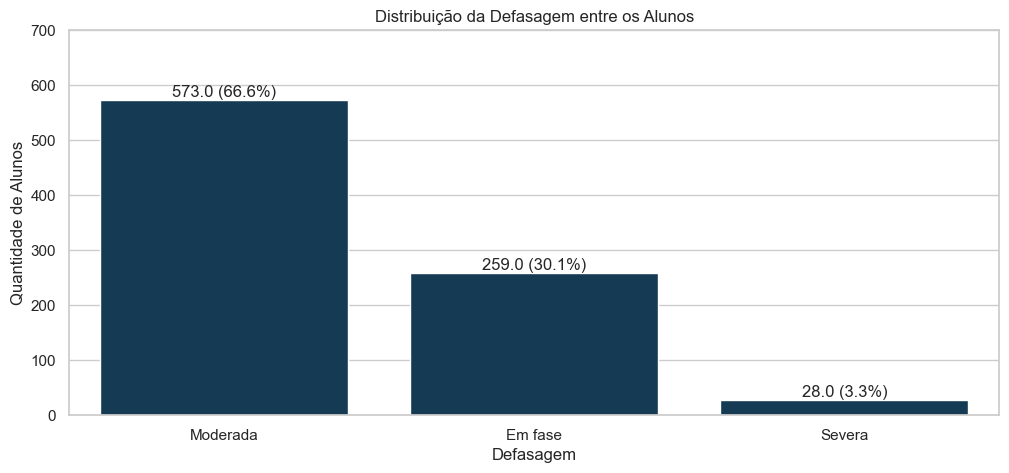

In [12]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(12,5)) 

ax = sns.countplot(x='Defasagem_Nome', data=df_2022) 

plt.title("Distribuição da Defasagem entre os Alunos") 
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)

ax.set_ylim(0,700)
total = len(df_2022) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()

In [13]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    object 
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    object 
 3   Nome Anonimizado       860 non-null    object 
 4   Ano nasc               860 non-null    int64  
 5   Idade                  860 non-null    int64  
 6   Gênero                 860 non-null    object 
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    object 
 9   Pedra 20               323 non-null    object 
 10  Pedra 21               462 non-null    object 
 11  Pedra 22               860 non-null    object 
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct    

In [14]:
df_2022.describe()

,Fase,Ano nasc,Idade,Ano ingresso,INDE 22,Cg,Cf,Ct,Nº Av,IAA,IEG,IPS,IDA,Mat,Por,Ing,IPV,IAN,Defasagem
count,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,860.000000,858.000000,858.000000,283.000000,860.000000,860.000000,860.000000
mean,2.098837,2009.861628,12.138372,2020.496512,7.036176,430.516279,75.519767,6.598837,3.054651,8.274419,7.891163,6.905000,6.092907,5.806876,6.320979,5.881272,7.253642,6.424419,-0.943023
std,1.788789,2.771998,2.771998,1.790217,1.017773,248.432761,52.312670,3.975858,0.775371,2.064935,1.638340,1.070707,2.046209,2.414215,2.080364,2.957315,1.093383,2.389609,0.845593
min,0.000000,2001.000000,7.000000,2016.000000,3.032000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,-5.000000
25%,1.000000,2008.000000,10.000000,2019.000000,6.485500,215.750000,30.000000,3.000000,2.000000,7.900000,7.000000,6.300000,4.800000,4.300000,5.200000,3.500000,6.722000,5.000000,-1.000000
50%,2.000000,2010.000000,12.000000,2021.000000,7.197000,430.500000,67.000000,6.000000,3.000000,8.800000,8.300000,7.500000,6.300000,6.000000,6.700000,6.300000,7.333000,5.000000,-1.000000
75%,3.000000,2012.000000,14.000000,2022.000000,7.751250,645.250000,118.000000,9.000000,4.000000,9.500000,9.100000,7.500000,7.600000,7.800000,7.800000,8.500000,7.917000,10.000000,0.000000
max,7.000000,2015.000000,21.000000,2022.000000,9.442000,862.000000,192.000000,18.000000,4.000000,10.000000,10.000000,10.000000,9.900000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000


In [15]:
#Média do IDA 2022
df_2022['IDA'].mean().round(2)

6.09

In [16]:
#Média do IDA por fase
media_por_fase = df_2022.groupby('Fase')['IDA'].mean().round(2)
print(media_por_fase)

Fase
0    7.14
1    6.46
2    5.41
3    5.14
4    6.05
5    5.87
6    6.69
7    5.25
Name: IDA, dtype: float64


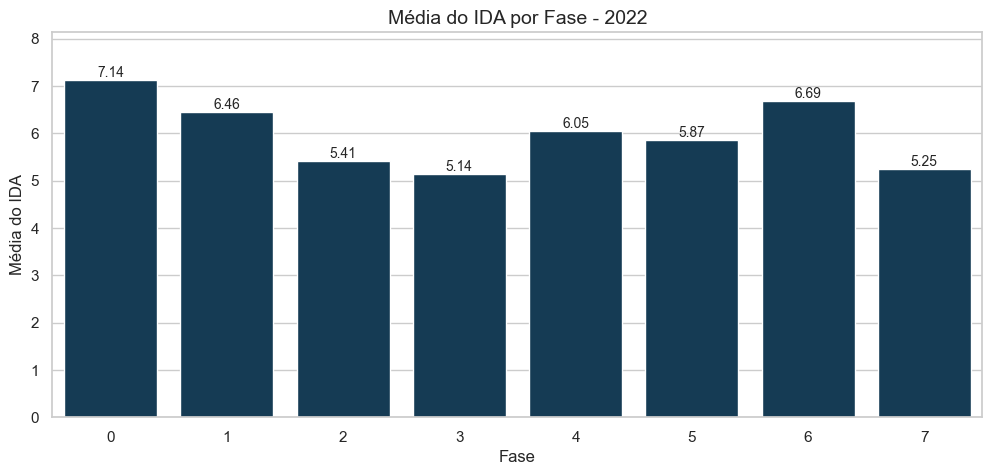

In [17]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IDA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IDA por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [18]:
#Média do IEG 2022
df_2022['IEG'].mean().round(2)

7.89

In [19]:
#Média do IGE por fase
media_por_fase = df_2022.groupby('Fase')['IEG'].mean().round(2)
print(media_por_fase)

Fase
0    8.09
1    8.52
2    8.17
3    7.07
4    7.66
5    7.34
6    7.03
7    7.24
Name: IEG, dtype: float64


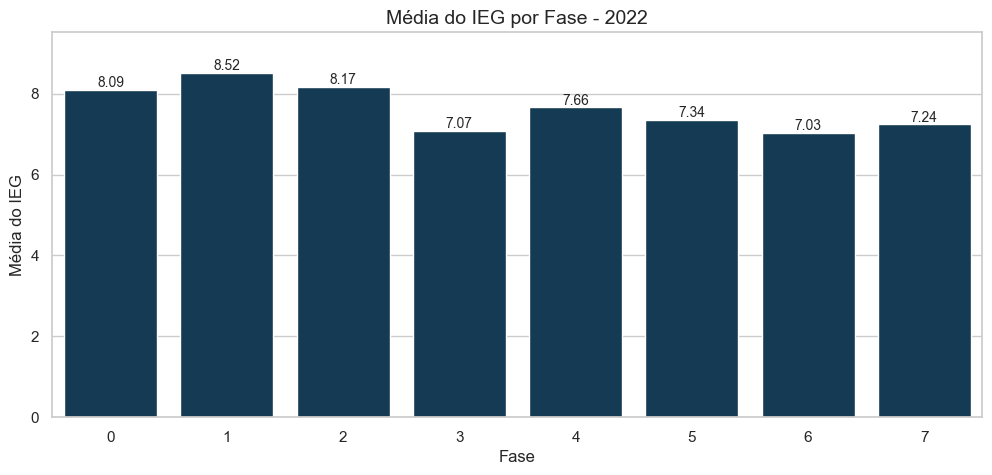

In [20]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IEG'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IEG por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IEG', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [21]:
#Média do IPV 2022
df_2022['IPV'].mean().round(2)

7.25

In [22]:
#Média do IPV por fase
media_por_fase = df_2022.groupby('Fase')['IPV'].mean().round(2)
print(media_por_fase)

Fase
0    7.56
1    7.36
2    7.34
3    6.55
4    7.21
5    7.26
6    8.22
7    7.18
Name: IPV, dtype: float64


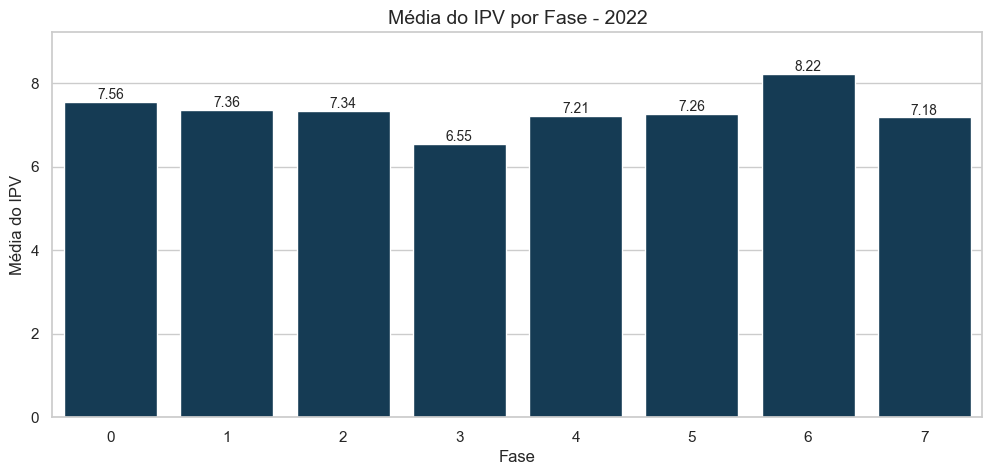

In [23]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IPV'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPV por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPV', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

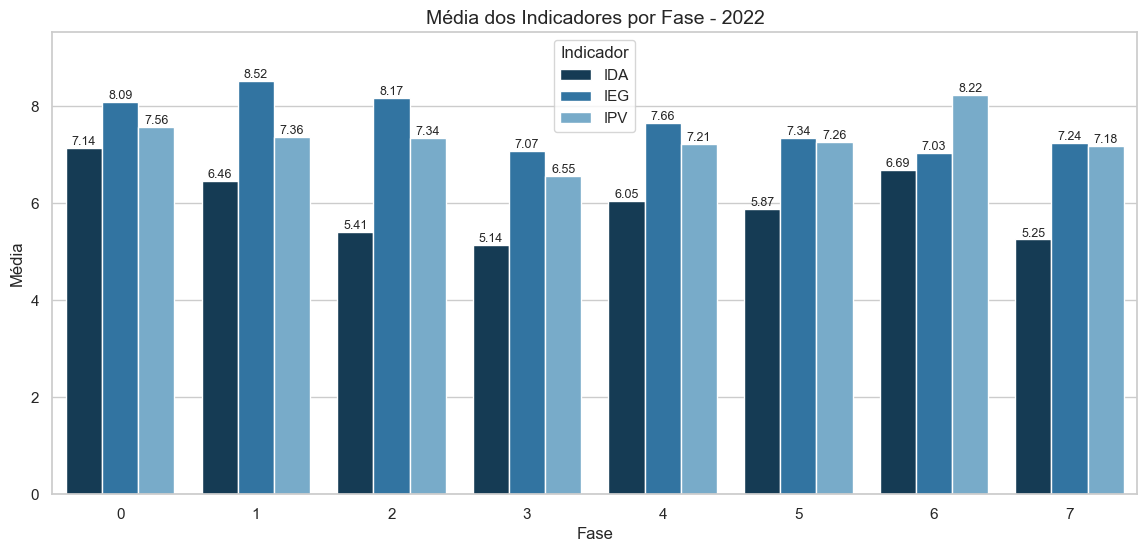

In [24]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2022
    .groupby('Fase')[['IDA', 'IEG', 'IPV']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IEG', 'IPV'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

In [25]:
df_2022[['IEG', 'IDA', 'IPV']].describe()

,IEG,IDA,IPV
count,860.000000,860.000000,860.000000
mean,7.891163,6.092907,7.253642
std,1.638340,2.046209,1.093383
min,0.000000,0.000000,2.500000
25%,7.000000,4.800000,6.722000
50%,8.300000,6.300000,7.333000
75%,9.100000,7.600000,7.917000
max,10.000000,9.900000,10.000000


In [26]:
#Correlação 
df_2022[['IEG', 'IDA', 'IPV']].corr()

,IEG,IDA,IPV
IEG,1.000000,0.564137,0.589178
IDA,0.564137,1.000000,0.616620
IPV,0.589178,0.616620,1.000000


In [27]:
#Correlação de Pearson

r_ida, p_ida = pearsonr(df_2022['IEG'], df_2022['IDA'])
r_ipv, p_ipv = pearsonr(df_2022['IEG'], df_2022['IPV'])

print("IEG x IDA -> r:", r_ida, "p:", p_ida)
print("IEG x IPV -> r:", r_ipv, "p:", p_ipv)

IEG x IDA -> r: 0.5641373269334604 p: 2.0302306080960436e-73
IEG x IPV -> r: 0.5891779240401492 p: 1.676331340253731e-81


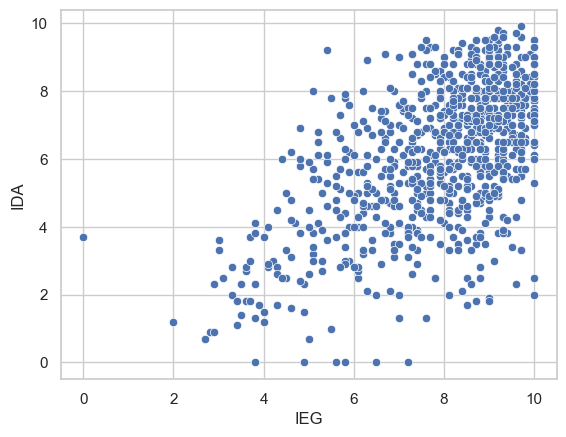

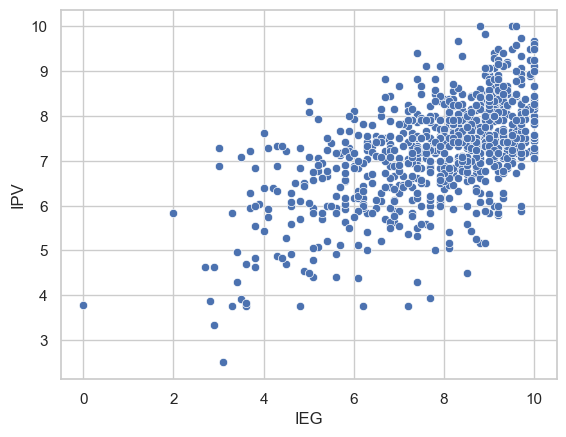

In [28]:
#Gráfico de dispersão

sns.scatterplot(x='IEG', y='IDA', data=df_2022)
plt.show()

sns.scatterplot(x='IEG', y='IPV', data=df_2022)
plt.show()

In [29]:
#Média do IAA 2022
df_2022['IAA'].mean().round(2)

8.27

In [30]:
#Média do IAA por fase
media_por_fase = df_2022.groupby('Fase')['IAA'].mean().round(2)
print(media_por_fase)


Fase
0    8.98
1    8.64
2    8.41
3    7.49
4    7.71
5    8.11
6    6.51
7    7.01
Name: IAA, dtype: float64


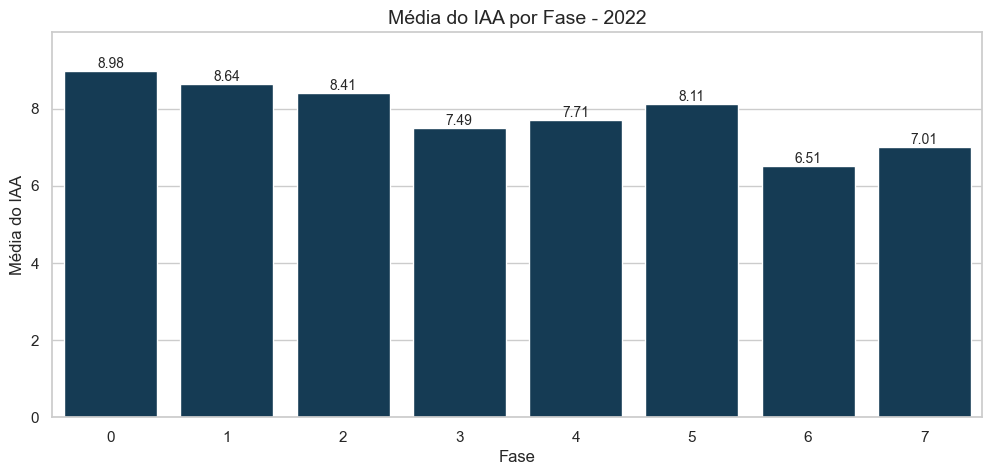

In [31]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IAA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IAA por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IAA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()



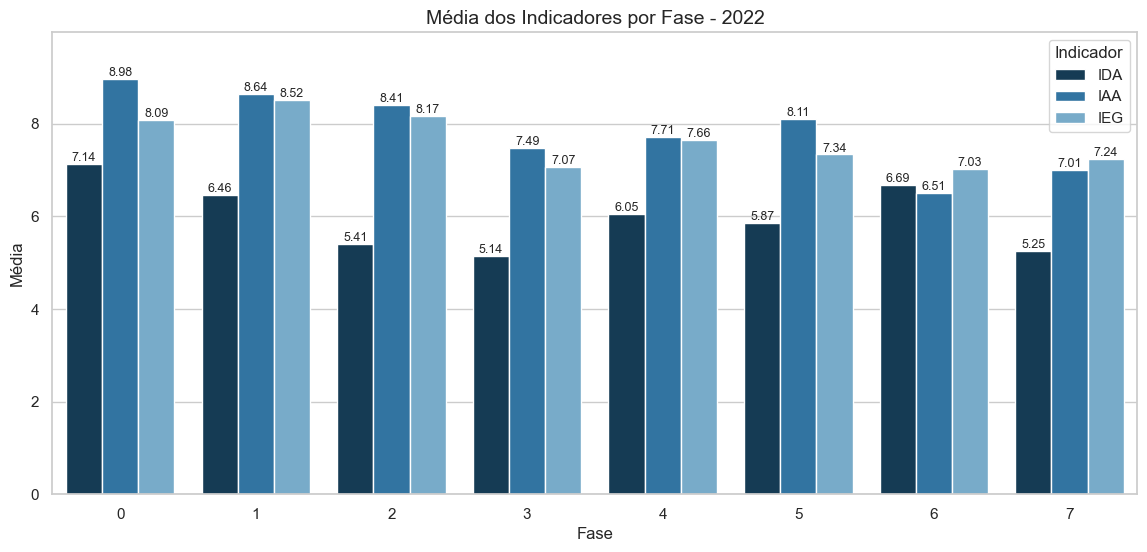

In [32]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2022
    .groupby('Fase')[['IDA', 'IAA', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IAA', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [33]:
df_2022[['IAA', 'IDA', 'IEG']].describe()

,IAA,IDA,IEG
count,860.000000,860.000000,860.000000
mean,8.274419,6.092907,7.891163
std,2.064935,2.046209,1.638340
min,0.000000,0.000000,0.000000
25%,7.900000,4.800000,7.000000
50%,8.800000,6.300000,8.300000
75%,9.500000,7.600000,9.100000
max,10.000000,9.900000,10.000000


In [34]:
#Correlação 
df_2022[['IAA', 'IDA', 'IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,0.208855,0.323420
IDA,0.208855,1.000000,0.564137
IEG,0.323420,0.564137,1.000000


In [35]:
#Correlação de Pearson

r_ida, p_ida = pearsonr(df_2022['IAA'], df_2022['IDA'])
r_ieg, p_ieg = pearsonr(df_2022['IAA'], df_2022['IEG'])

print("IAA x IDA -> r:", r_ida, "p:", p_ida)
print("IAA x IEG -> r:", r_ieg, "p:", p_ieg)


IAA x IDA -> r: 0.20885507431673483 p: 6.239843270233082e-10
IAA x IEG -> r: 0.32341991681052734 p: 2.169312813185315e-22


In [36]:
corr = df_2022[['IEG', 'IDA', 'IAA']].corr()

r_iaa_ida = corr.loc['IAA', 'IDA']
r_iaa_ieg = corr.loc['IAA', 'IEG']

print("IAA x IDA - R²:", r_iaa_ida**2 *100)
print("IAA x IEG - R²:", r_iaa_ieg**2 *100)

IAA x IDA - R²: 4.362044206784896
IAA x IEG - R²: 10.460044258972918


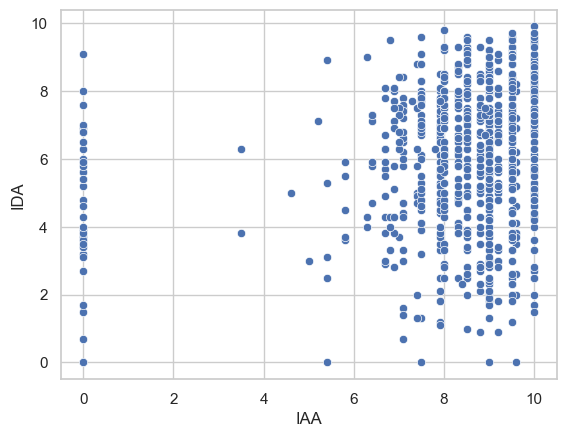

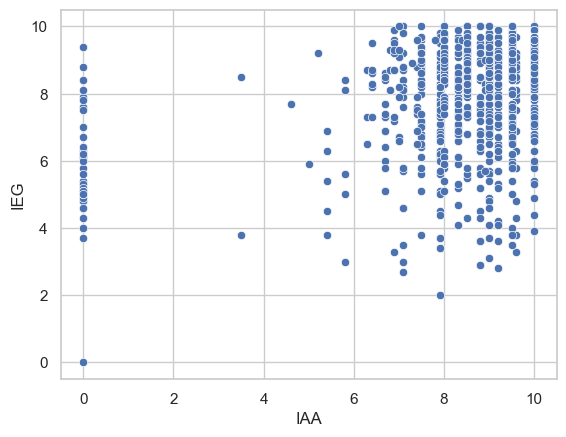

In [37]:
#Gráfico de dispersão

sns.scatterplot(x='IAA', y='IDA', data=df_2022)
plt.show()

sns.scatterplot(x='IAA', y='IEG', data=df_2022)
plt.show()


In [38]:
#Média do IPS 2022
df_2022['IPS'].mean().round(2)

6.9

In [39]:
#Média do IPS por fase
media_por_fase = df_2022.groupby('Fase')['IPS'].mean().round(2)
print(media_por_fase)


Fase
0    7.01
1    7.08
2    6.82
3    6.72
4    6.61
5    6.86
6    7.96
7    6.52
Name: IPS, dtype: float64


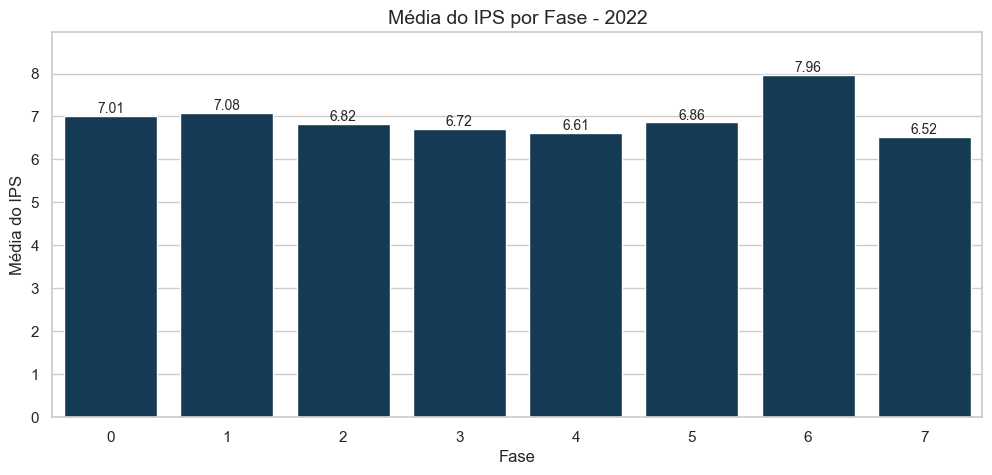

In [40]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IPS'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPS por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPS', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()


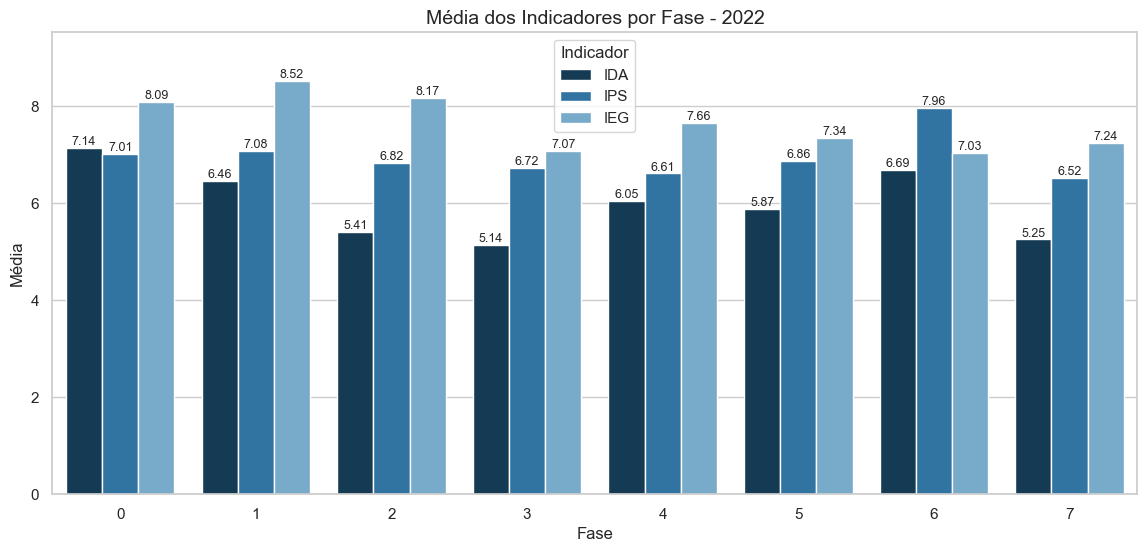

In [41]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2022
    .groupby('Fase')[['IDA', 'IPS', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IPS', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()




In [42]:
df_2022[['IAA', 'IPS', 'IEG']].describe()


,IAA,IPS,IEG
count,860.000000,860.000000,860.000000
mean,8.274419,6.905000,7.891163
std,2.064935,1.070707,1.638340
min,0.000000,2.500000,0.000000
25%,7.900000,6.300000,7.000000
50%,8.800000,7.500000,8.300000
75%,9.500000,7.500000,9.100000
max,10.000000,10.000000,10.000000


In [43]:
#Correlação 
df_2022[['IAA', 'IPS', 'IEG']].corr()
#Correlação de Pearson


,IAA,IPS,IEG
IAA,1.000000,0.111015,0.32342
IPS,0.111015,1.000000,0.09322
IEG,0.323420,0.093220,1.00000


In [44]:
r_ida, p_ida = pearsonr(df_2022['IPS'], df_2022['IDA'])
r_ieg, p_ieg = pearsonr(df_2022['IPS'], df_2022['IEG'])

print("IPS x IDA -> r:", r_ida, "p:", p_ida)
print("IPS x IEG -> r:", r_ieg, "p:", p_ieg)


IPS x IDA -> r: 0.13192559474281645 p: 0.00010438694521095429
IPS x IEG -> r: 0.09322010753671967 p: 0.006224147953884271


In [45]:
corr = df_2022[['IEG', 'IDA', 'IPS']].corr()

r_ips_ida = corr.loc['IPS', 'IDA']
r_ips_ieg = corr.loc['IPS', 'IEG']

print("IPS x IDA - R²:", r_ips_ida**2 *100)
print("IPS x IEG - R²:", r_ips_ieg**2 *100)


IPS x IDA - R²: 1.7404362548245813
IPS x IEG - R²: 0.86899884491576


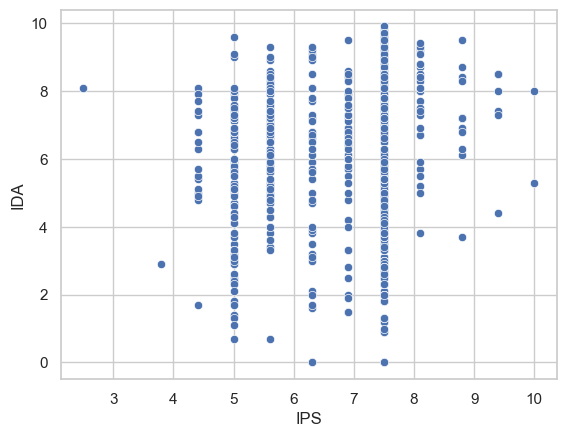

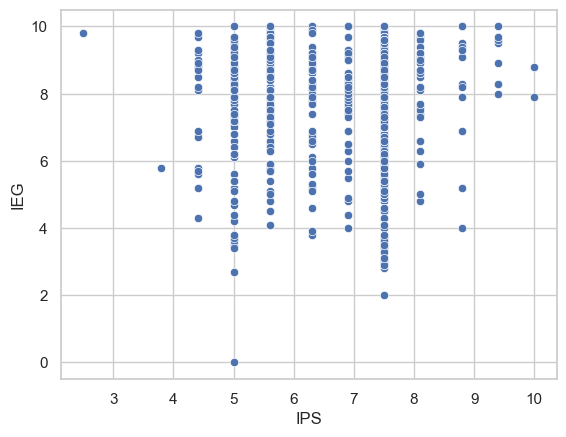

In [46]:
#Gráfico de dispersão

sns.scatterplot(x='IPS', y='IDA', data=df_2022)
plt.show()

sns.scatterplot(x='IPS', y='IEG', data=df_2022)
plt.show()


In [47]:
df_2022['grupo_ips_bin'] = np.where(df_2022['IPS'] < 7.5, 1, 0)
# 1 = grupo de atenção
# 0 = grupo regular

In [48]:
import statsmodels.api as sm

X = sm.add_constant(df_2022['grupo_ips_bin'])
y = df_2022['IDA']

modelo_ida = sm.OLS(y, X).fit()

print(modelo_ida.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7.356
Date:                Fri, 06 Mar 2026   Prob (F-statistic):            0.00682
Time:                        21:31:31   Log-Likelihood:                -1831.9
No. Observations:                 860   AIC:                             3668.
Df Residuals:                     858   BIC:                             3677.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.2330      0.087     71.962

In [49]:
X = sm.add_constant(df_2022['grupo_ips_bin'])
y = df_2022['IEG']

modelo_ieg = sm.OLS(y, X).fit()

print(modelo_ieg.summary())

                            OLS Regression Results                            
Dep. Variable:                    IEG   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     4.118
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0427
Time:                        21:31:31   Log-Likelihood:                -1642.3
No. Observations:                 860   AIC:                             3289.
Df Residuals:                     858   BIC:                             3298.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9753      0.069    114.784

In [50]:
#Criar a coluna IPP, pois em 2022 não tem essa coluna
# Cálculo do IPP a partir da fórmula do INDE
#
# O INDE (Índice de Desempenho) é definido como uma média ponderada
# dos seguintes indicadores:
#
# INDE = 0.1*IAN + 0.2*IDA + 0.2*IEG + 0.1*IAA +
#        0.1*IPS + 0.1*IPP + 0.2*IPV
#
# Considerando que o peso associado ao IPP é 0,1,
# é possível isolar algebricamente esse termo para estimar
# seu valor quando ele não está disponível na base de dados.
#
# Reorganizando a equação:
#
# 0.1*IPP = INDE − (0.1*IAN + 0.2*IDA + 0.2*IEG +
#                   0.1*IAA + 0.1*IPS + 0.2*IPV)
#
# Dividindo ambos os lados por 0,1:
#
# IPP = (INDE − (0.1*IAN + 0.2*IDA + 0.2*IEG +
#                0.1*IAA + 0.1*IPS + 0.2*IPV)) / 0.1
#
# Forma algébrica equivalente simplificada:
#
# IPP = 10*INDE − (IAN + 2*IDA + 2*IEG + IAA + IPS + 2*IPV)
#
# O valor estimado do IPP é posteriormente validado
# por meio do recálculo do INDE, garantindo consistência matemática
# com a fórmula original.

df_2022["IPP"] = (
    df_2022["INDE 22"]
    - (
        0.1 * df_2022["IAN"]
        + 0.2 * df_2022["IDA"]
        + 0.2 * df_2022["IEG"]
        + 0.1 * df_2022["IAA"]
        + 0.1 * df_2022["IPS"]
        + 0.2 * df_2022["IPV"]
    )
) / 0.1

In [51]:
#Média do IPP 2022
df_2022['IPP'].mean().round(2)

6.28

In [52]:
#Média do IPP por fase
media_por_fase = df_2022.groupby('Fase')['IPP'].mean().round(2)
print(media_por_fase)


Fase
0    5.29
1    5.84
2    6.13
3    7.27
4    7.40
5    6.57
6    7.83
7    7.27
Name: IPP, dtype: float64


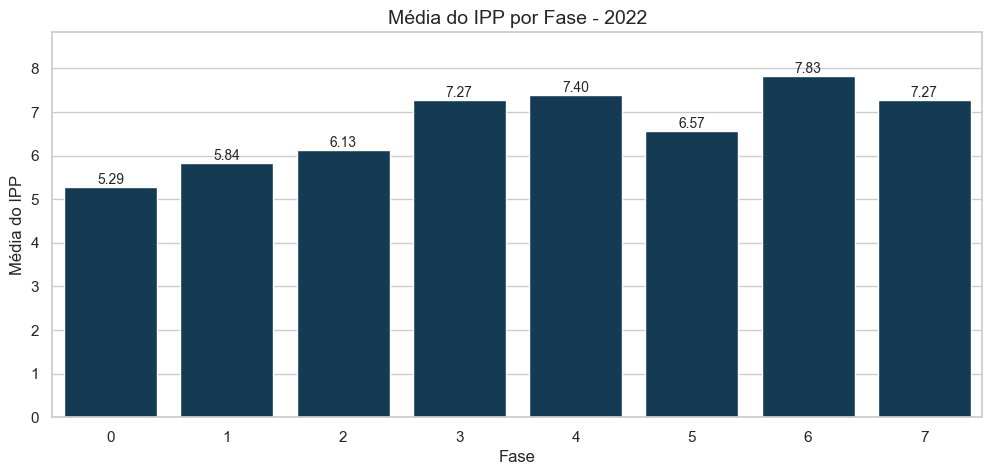

In [53]:

# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()


C:\Users\camil\AppData\Local\Temp\ipykernel_7852\1952687384.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(


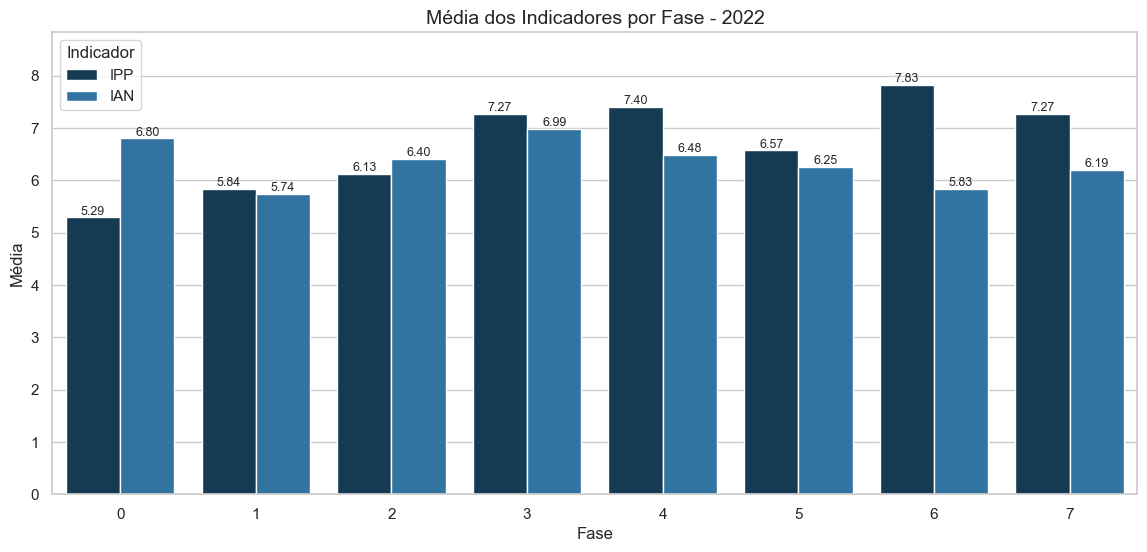

In [54]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2022
    .groupby('Fase')[['IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()




In [55]:
df_2022[['IPP', 'IAN']].describe()

,IPP,IAN
count,860.000000,860.000000
mean,6.282495,6.424419
std,1.133289,2.389609
min,-0.074000,2.500000
25%,5.605500,5.000000
50%,6.144000,5.000000
75%,7.030500,10.000000
max,9.120000,10.000000


In [56]:
#Correlação 
df_2022[['IPP', 'IAN']].corr()


#Correlação de Pearson
r_ian2, p_ian2 = pearsonr(df_2022['IPP'], df_2022['IAN'])

print("IPP x IAN -> r:", r_ian2, "p:", p_ian2)


IPP x IAN -> r: 0.11549517196109452 p: 0.0006902601166618665


In [57]:
corr = df_2022[['IPP', 'IAN']].corr()

r_ipp_ian = corr.loc['IPP', 'IAN']

print("IAA x IDA - R²:", r_ipp_ian**2 *100)


IAA x IDA - R²: 1.3339134746322705


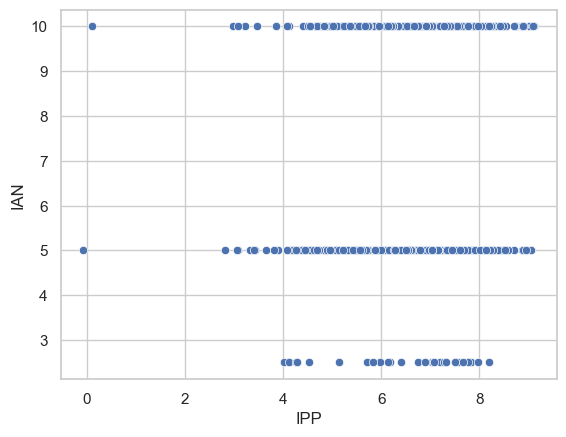

In [58]:
#Gráfico de dispersão

sns.scatterplot(x='IPP', y='IAN', data=df_2022)
plt.show()



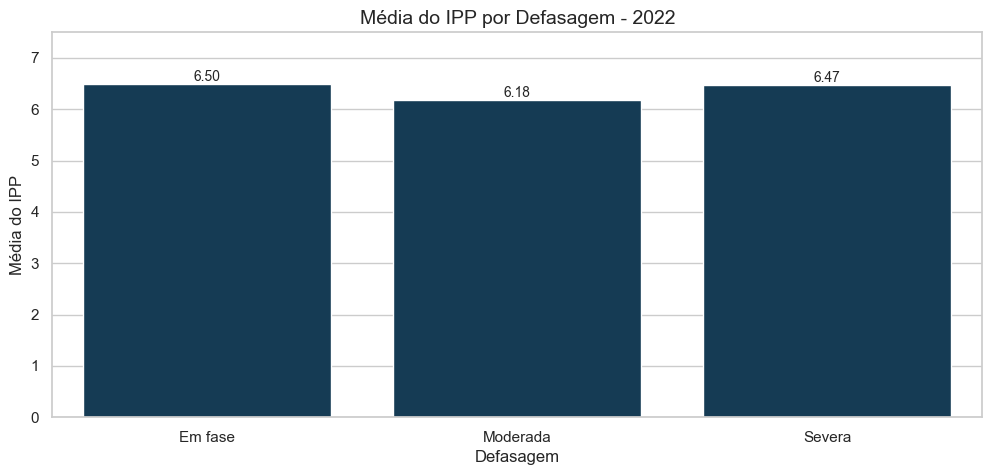

In [59]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Defasagem_Nome')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Defasagem - 2022", fontsize=14)
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [60]:
#Correlação
df_2022[['IDA', 'IEG', 'IAA', 'IPV']].corr()

,IDA,IEG,IAA,IPV
IDA,1.000000,0.564137,0.208855,0.616620
IEG,0.564137,1.000000,0.323420,0.589178
IAA,0.208855,0.323420,1.000000,0.255590
IPV,0.616620,0.589178,0.255590,1.000000


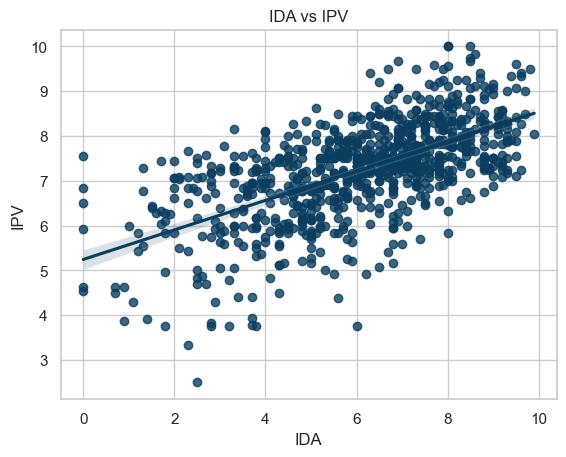

In [61]:
plt.figure()
sns.regplot(x='IDA', y='IPV', data=df_2022)
plt.title("IDA vs IPV")
plt.show()

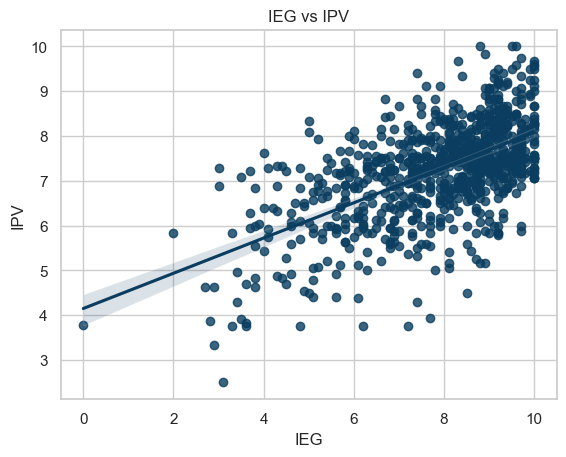

In [62]:
plt.figure()
sns.regplot(x='IEG', y='IPV', data=df_2022)
plt.title("IEG vs IPV")
plt.show()

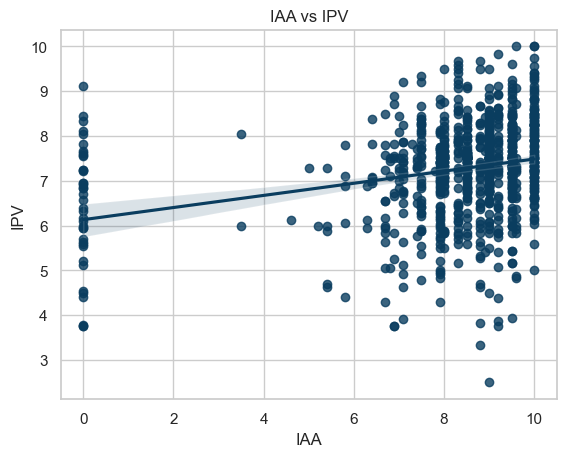

In [63]:
plt.figure()
sns.regplot(x='IAA', y='IPV', data=df_2022)
plt.title("IAA vs IPV")
plt.show()

In [64]:
import statsmodels.api as sm

X = df_2022[['IDA', 'IEG', 'IAA']]
y = df_2022['IPV']

X = sm.add_constant(X)  # adiciona intercepto

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IPV   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     251.9
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          3.79e-117
Time:                        21:31:34   Log-Likelihood:                -1024.5
No. Observations:                 860   AIC:                             2057.
Df Residuals:                     856   BIC:                             2076.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8710      0.152     25.549      0.0

In [65]:
# supondo que df já tem as colunas
df_2022["contrib_IDA"] = 0.2 * df_2022["IDA"]
df_2022["contrib_IEG"] = 0.2 * df_2022["IEG"]
df_2022["contrib_IPS"] = 0.1 * df_2022["IPS"]
df_2022["contrib_IPP"] = 0.1 * df_2022["IPP"]

# soma da combinação analisada
df_2022["contrib_combinacao"] = (
    df_2022["contrib_IDA"] +
    df_2022["contrib_IEG"] +
    df_2022["contrib_IPS"] +
    df_2022["contrib_IPP"]

)


In [66]:
df_2022[["contrib_combinacao", "INDE 22"]].corr()

,contrib_combinacao,INDE 22
contrib_combinacao,1.000000,0.940258
INDE 22,0.940258,1.000000


In [67]:
#Isso mostra o quanto essa combinação explica o INDE.

#Conceitualmente:

#IDA e IEG têm peso 0.2 → maior impacto estrutural

#IPS e IPP têm peso 0.1 → impacto moderado

#Então combinações com IDA e IEG altos naturalmente elevam mais o INDE.

In [68]:
df_2022["IDA_IEG"] = df_2022["IDA"] * df_2022["IEG"]
df_2022["IDA_IPS"] = df_2022["IDA"] * df_2022["IPS"]

X = df_2022[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]]
X = sm.add_constant(X)

modelo = sm.OLS(df_2022["INDE 22"], X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                INDE 22   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     1102.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:31:34   Log-Likelihood:                -302.18
No. Observations:                 860   AIC:                             618.4
Df Residuals:                     853   BIC:                             651.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0668      0.267      3.997      0.0

In [69]:
#Média do INDE 2022
df_2022['INDE 22'].mean().round(2)

7.04

In [70]:
#Média do INDE por fase
media_por_fase = df_2022.groupby('Fase')['INDE 22'].mean().round(2)
print(media_por_fase)

Fase
0    7.37
1    7.20
2    6.96
3    6.60
4    7.01
5    6.88
6    7.20
7    6.64
Name: INDE 22, dtype: float64


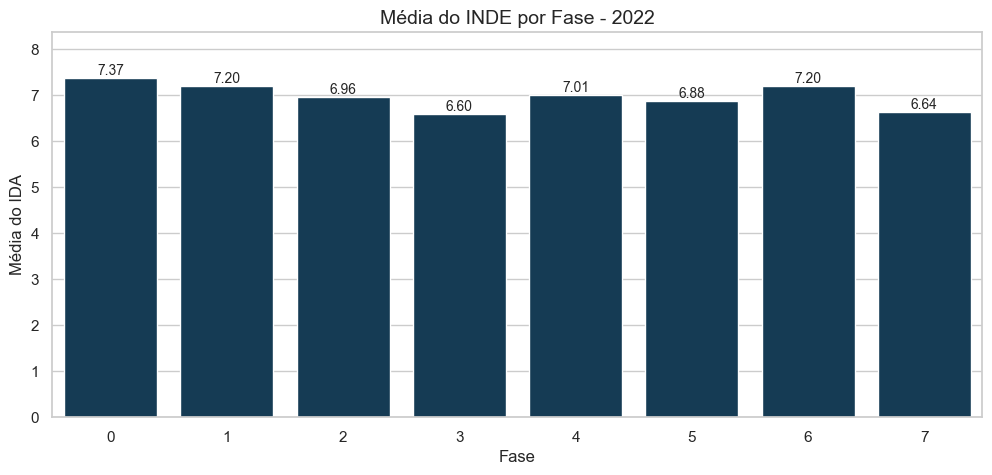

In [71]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2022.groupby('Fase')['INDE 22'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do INDE por Fase - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\1024962144.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores


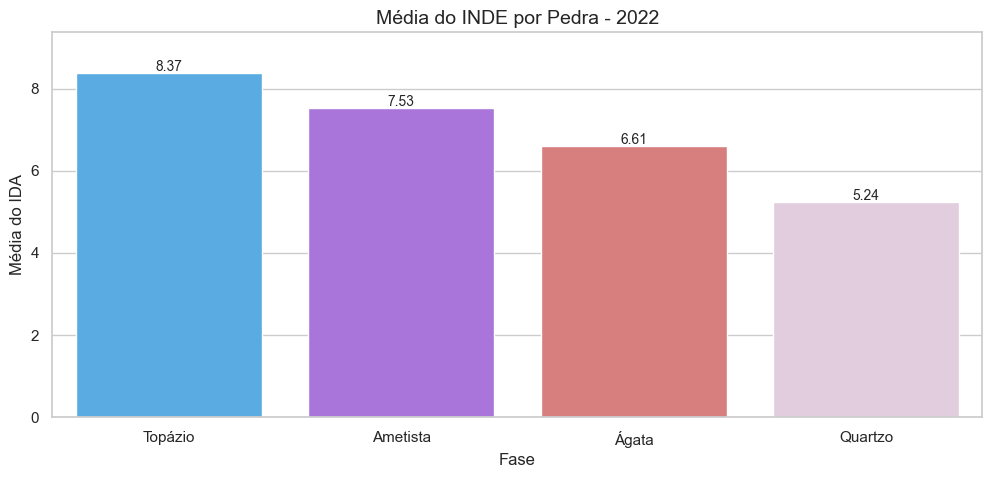

In [72]:
# Configurações de estilo
sns.set(style="whitegrid")

# Calcula a média por fase
media_por_fase = df_2022.groupby('Pedra 22')['INDE 22'].mean().round(2).sort_values(ascending=False)

cores_pedras = {
    "Ametista": "#AA64EC",   # roxo pastel
    "Quartzo": "#E4CAE0",    # rosa pastel
    "Topázio": "#43B0F8",    # azul pastel
    "Ágata": "#E66F6F"       # vermelho pastel
}   

cores = [cores_pedras[pedra] for pedra in media_por_fase.index]

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores
)

# Título e labels
plt.title("Média do INDE por Pedra - 2022", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v + 0.05, f'{v:.2f}', 
            ha='center', fontsize=10)

plt.show()

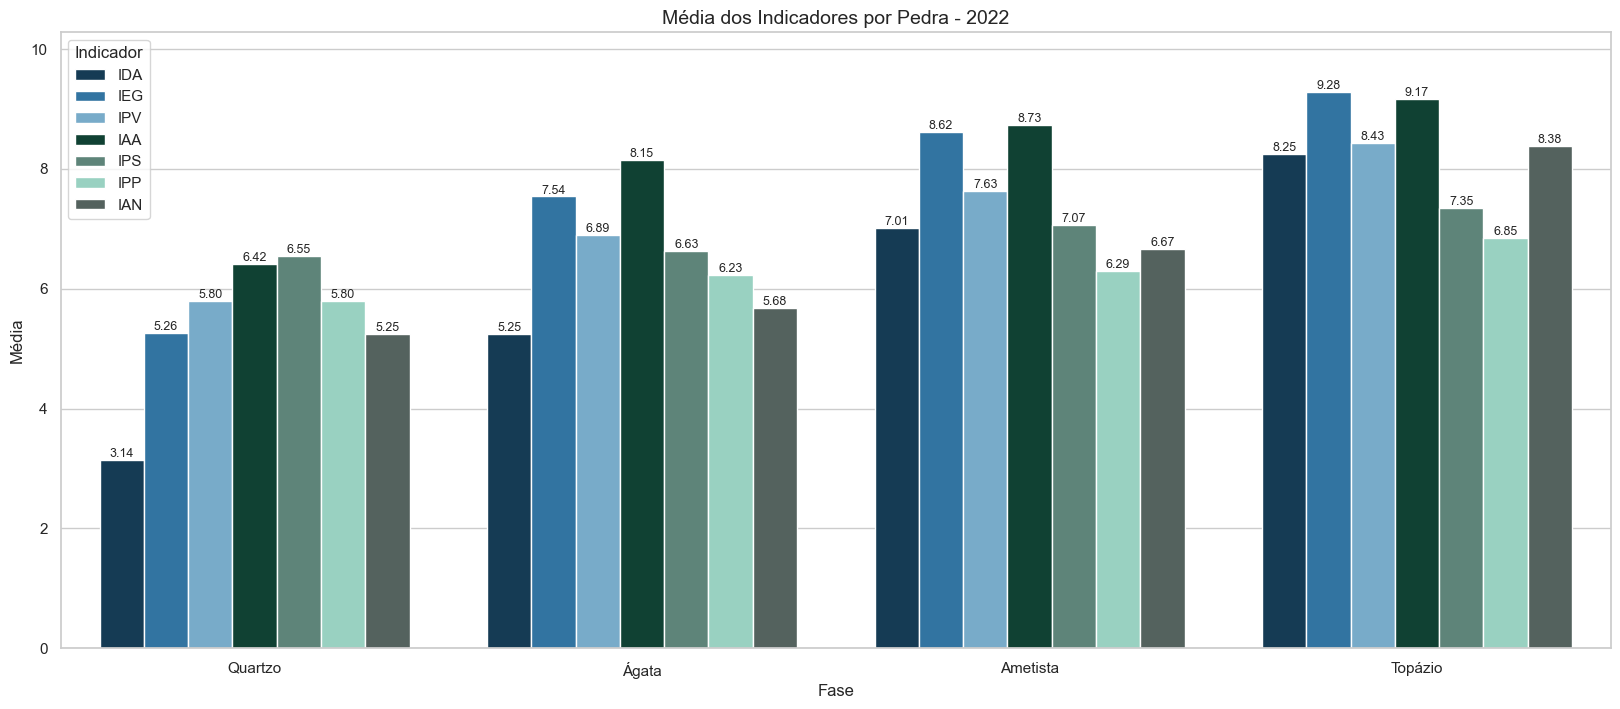

In [73]:
# Configuração de estilo


#ordem personalizada das pedras
ordem_pedras = ["Quartzo", "Ágata", "Ametista", "Topázio"]

# Calcula média por pedra
media_por_fase = (
    df_2022
    .groupby('Pedra 22')[['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

#Transforma em categórica com ordem definida
media_por_fase['Pedra 22'] = pd.Categorical(
    media_por_fase['Pedra 22'],
    categories=ordem_pedras,
    ordered=True
)

#Ordena pela ordem que você definiu
media_por_fase = media_por_fase.sort_values('Pedra 22')

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Pedra 22',
    value_vars=['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(20,8))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6", "#084936", "#578B7C", "#90DAC5", "#52645F"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Pedra 22',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Pedra - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

DF 2023


In [74]:
df_2023.shape

(1014, 48)

In [75]:
#Quantos alunos ingressaram nesse ano 
df_2023_ingressantes = df_2023.loc[df_2023['Ano ingresso'] == 2023]
df_2023_ingressantes.shape

(369, 48)

In [76]:
df_2023['Gênero'].value_counts()

Gênero
Feminino     546
Masculino    468
Name: count, dtype: int64

In [77]:
df_2023['Instituição de ensino'].value_counts()

Instituição de ensino
Pública                                      809
Privada - Programa de Apadrinhamento          99
Privada *Parcerias com Bolsa 100%             60
Privada                                       28
Privada - Pagamento por *Empresa Parceira      8
Concluiu o 3º EM                               7
Nenhuma das opções acima                       2
Privada - Programa de apadrinhamento           1
Name: count, dtype: int64

In [78]:
df_2023['Fase'].unique()

array(['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6',
       'FASE 7', 'FASE 8'], dtype=object)

In [79]:
#alunos por fase
df_2023['Fase'].value_counts()

Fase
ALFA      231
FASE 2    200
FASE 1    173
FASE 3    132
FASE 4     94
FASE 5     65
FASE 8     63
FASE 6     33
FASE 7     23
Name: count, dtype: int64

In [80]:
#Contagem dos valores de defasagem
mapa = {
    2.5: 'Severa',
    5: 'Moderada',
    10: 'Em fase'
   
}

df_2023['Defasagem_Nome'] = (
    df_2023['IAN'].replace(mapa)
)

df_2023['Defasagem_Nome'].value_counts()

Defasagem_Nome
Moderada    538
Em fase     462
Severa       14
Name: count, dtype: int64

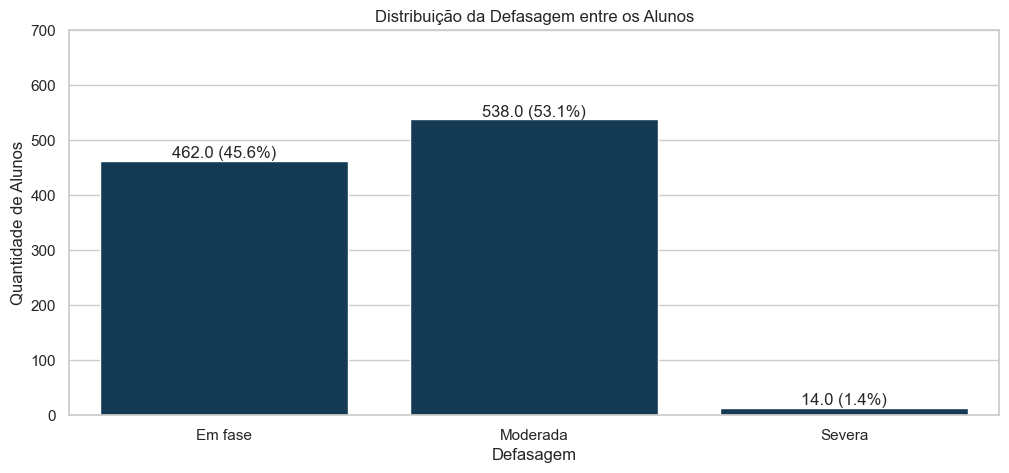

In [81]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(12,5)) 

ax = sns.countplot(x='Defasagem_Nome', data=df_2023) 

plt.title("Distribuição da Defasagem entre os Alunos") 
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)

ax.set_ylim(0,700)
total = len(df_2023) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()

In [82]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     1014 non-null   object 
 1   Fase                   1014 non-null   object 
 2   INDE 2023              931 non-null    float64
 3   Pedra 2023             931 non-null    object 
 4   Turma                  1014 non-null   object 
 5   Nome Anonimizado       1014 non-null   object 
 6   Data de Nasc           1014 non-null   object 
 7   Idade                  1014 non-null   object 
 8   Gênero                 1014 non-null   object 
 9   Ano ingresso           1014 non-null   int64  
 10  Instituição de ensino  1014 non-null   object 
 11  Pedra 20               240 non-null    object 
 12  Pedra 21               335 non-null    object 
 13  Pedra 22               600 non-null    object 
 14  Pedra 23               0 non-null      float64
 15  INDE

In [83]:
df_2023.describe()

,INDE 2023,Ano ingresso,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Rec Av1,...,Ing,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
count,931.000000,1014.000000,0.0,600.000000,0.0,0.0,0.0,0.0,938.000000,0.0,...,334.000000,0.0,0.0,938.000000,1014.000000,1014.000000,0.0,0.0,0.0,0.0
mean,7.342309,2021.378698,NaN,7.262788,NaN,NaN,NaN,NaN,3.109808,NaN,...,6.200299,NaN,NaN,8.027897,7.243590,-0.654832,NaN,NaN,NaN,NaN
std,0.901757,1.873750,NaN,0.895774,NaN,NaN,NaN,NaN,0.768712,NaN,...,2.236545,NaN,NaN,0.945427,2.539585,0.821233,NaN,NaN,NaN,NaN
min,3.745542,2016.000000,NaN,3.700000,NaN,NaN,NaN,NaN,2.000000,NaN,...,0.000000,NaN,NaN,3.320000,2.500000,-4.000000,NaN,NaN,NaN,NaN
25%,6.724150,2021.000000,NaN,6.740250,NaN,NaN,NaN,NaN,3.000000,NaN,...,4.725000,NaN,NaN,7.462500,5.000000,-1.000000,NaN,NaN,NaN,NaN
50%,7.408033,2022.000000,NaN,7.402500,NaN,NaN,NaN,NaN,3.000000,NaN,...,6.400000,NaN,NaN,8.045000,5.000000,-1.000000,NaN,NaN,NaN,NaN
75%,7.996083,2023.000000,NaN,7.903500,NaN,NaN,NaN,NaN,4.000000,NaN,...,7.800000,NaN,NaN,8.668750,10.000000,0.000000,NaN,NaN,NaN,NaN
max,9.371200,2023.000000,NaN,9.442000,NaN,NaN,NaN,NaN,4.000000,NaN,...,10.000000,NaN,NaN,10.010000,10.000000,2.000000,NaN,NaN,NaN,NaN


In [84]:
#Para tirar a fase 8 que está em branco
df_2023 = df_2023[df_2023['Fase'] != 'FASE 8']

In [85]:
#Média do IDA 2023
df_2023['IDA'].mean().round(2)

6.66

In [86]:
#Média do IDA por fase
media_por_fase = df_2023.groupby('Fase')['IDA'].mean().round(2)
print(media_por_fase)

Fase
ALFA      7.42
FASE 1    6.81
FASE 2    6.74
FASE 3    5.75
FASE 4    6.00
FASE 5    5.90
FASE 6    6.81
FASE 7    7.81
Name: IDA, dtype: float64


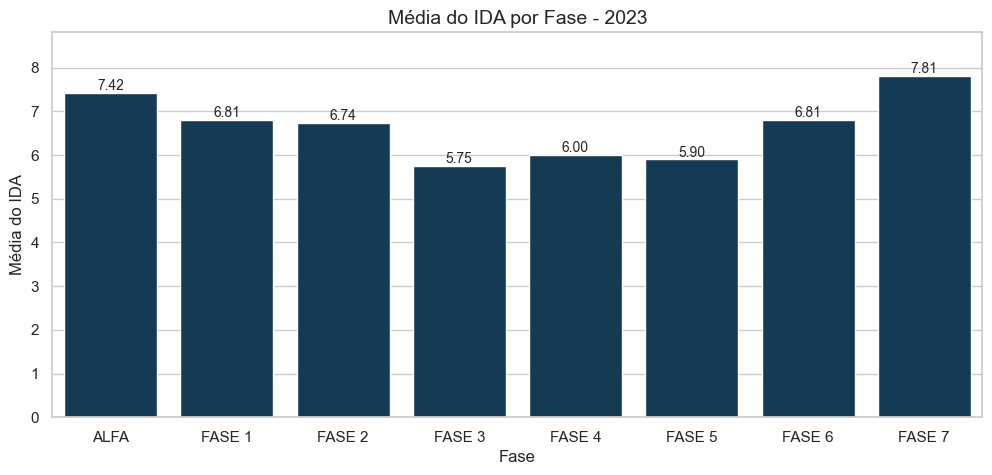

In [87]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IDA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IDA por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v, f'{v:.2f}', 
            ha='center', 
            va='bottom', 
            fontsize=10)
plt.show()

In [88]:
#Média do IEG 2023
df_2023['IEG'].mean().round(2)

8.7

In [89]:
#Média do IGE por fase
media_por_fase = df_2023.groupby('Fase')['IEG'].mean().round(2)
print(media_por_fase)

Fase
ALFA      8.94
FASE 1    8.74
FASE 2    8.80
FASE 3    8.44
FASE 4    8.35
FASE 5    8.45
FASE 6    8.50
FASE 7    9.17
Name: IEG, dtype: float64


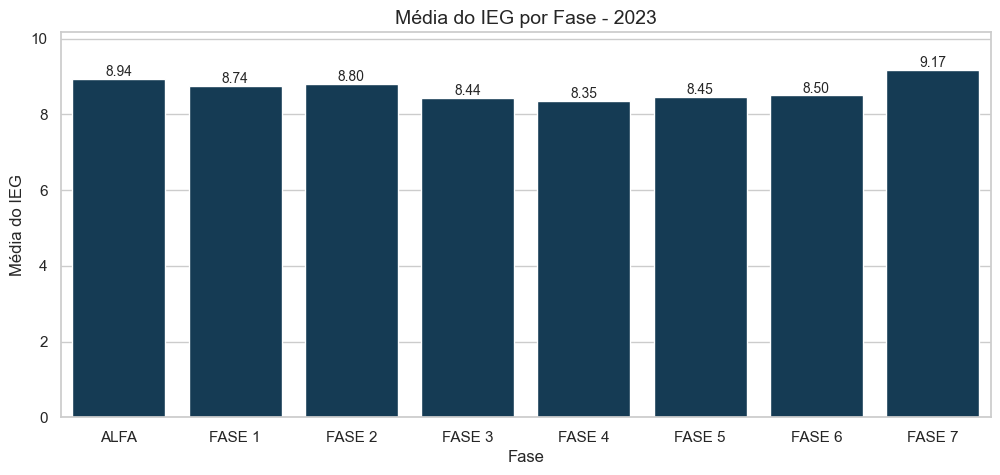

In [90]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IEG'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IEG por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IEG', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v, f'{v:.2f}', 
            ha='center', 
            va='bottom', 
            fontsize=10)

plt.show()

In [91]:
#Média do IPV 2023
df_2023['IPV'].mean().round(2)

8.03

In [92]:
#Média do IPV por fase
media_por_fase = df_2023.groupby('Fase')['IPV'].mean().round(2)
print(media_por_fase)

Fase
ALFA      8.32
FASE 1    8.10
FASE 2    8.21
FASE 3    7.58
FASE 4    7.95
FASE 5    7.45
FASE 6    7.73
FASE 7    7.88
Name: IPV, dtype: float64


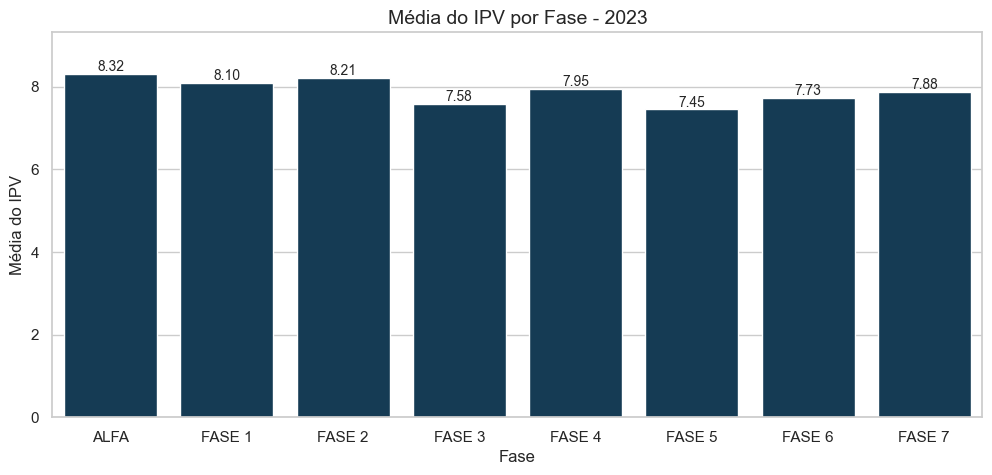

In [93]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IPV'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPV por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPV', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v, f'{v:.2f}', 
            ha='center', 
            va='bottom', 
            fontsize=10)
plt.show()

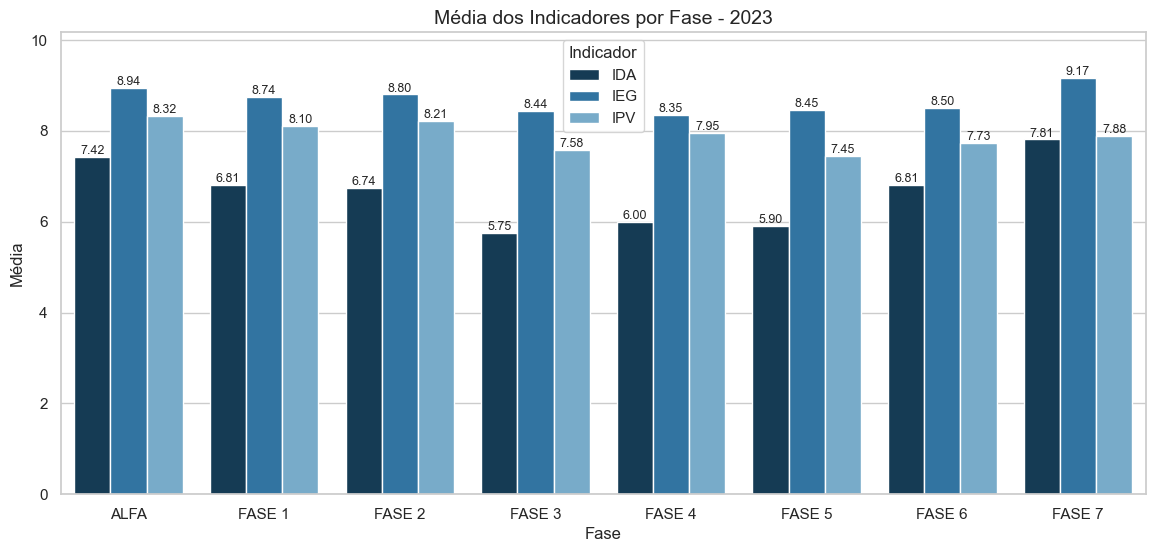

In [94]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2023
    .groupby('Fase')[['IDA', 'IEG', 'IPV']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IEG', 'IPV'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2023", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

In [95]:
df_2023[['IEG', 'IDA', 'IPV']].describe()

,IEG,IDA,IPV
count,938.000000,937.000000,938.000000
mean,8.699041,6.663394,8.027897
std,1.084001,1.595277,0.945427
min,3.700000,0.000000,3.320000
25%,8.100000,5.700000,7.462500
50%,9.000000,6.800000,8.045000
75%,9.500000,7.900000,8.668750
max,10.000000,10.000000,10.010000


In [96]:
#Correlação 
df_2023[['IEG', 'IDA', 'IPV']].corr()

,IEG,IDA,IPV
IEG,1.000000,0.461028,0.448722
IDA,0.461028,1.000000,0.544204
IPV,0.448722,0.544204,1.000000


In [97]:
df_2023[['IEG', 'IDA', 'IPV']].isna().sum()

IEG    13
IDA    14
IPV    13
dtype: int64

In [98]:
from scipy.stats import pearsonr

# IEG x IDA
df_ida = df_2023[['IEG', 'IDA']].dropna()
r_ida, p_ida = pearsonr(df_ida['IEG'], df_ida['IDA'])

# IEG x IPV
df_ipv = df_2023[['IEG', 'IPV']].dropna()
r_ipv, p_ipv = pearsonr(df_ipv['IEG'], df_ipv['IPV'])

print("IEG x IDA -> r:", r_ida, "p:", p_ida)
print("IEG x IPV -> r:", r_ipv, "p:", p_ipv)

IEG x IDA -> r: 0.4610283111421547 p: 1.72180248134492e-50
IEG x IPV -> r: 0.44872163312607183 p: 1.161317035315466e-47


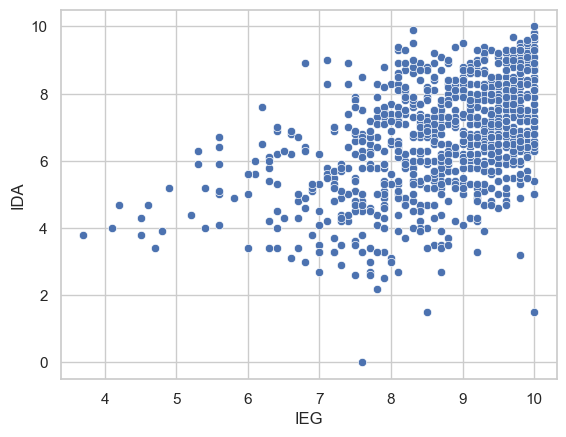

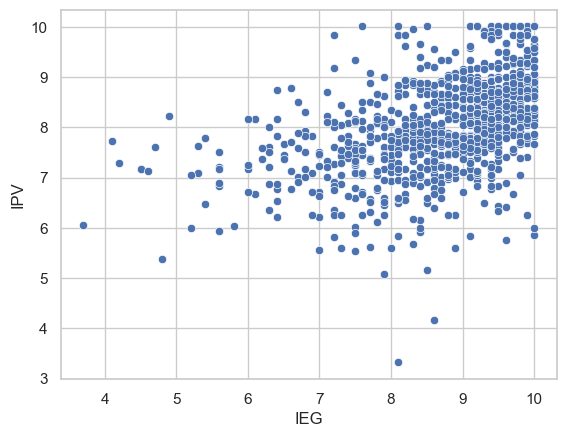

In [99]:
#Gráfico de dispersão

sns.scatterplot(x='IEG', y='IDA', data=df_2023)
plt.show()

sns.scatterplot(x='IEG', y='IPV', data=df_2023)
plt.show()

In [100]:
#Média do IAA 2023
df_2023['IAA'].mean().round(2)

6.9

In [101]:
#Média do IAA por fase
media_por_fase = df_2023.groupby('Fase')['IAA'].mean().round(2)
print(media_por_fase)


Fase
ALFA      7.46
FASE 1    7.20
FASE 2    6.62
FASE 3    6.38
FASE 4    6.95
FASE 5    6.44
FASE 6    6.38
FASE 7    6.51
Name: IAA, dtype: float64


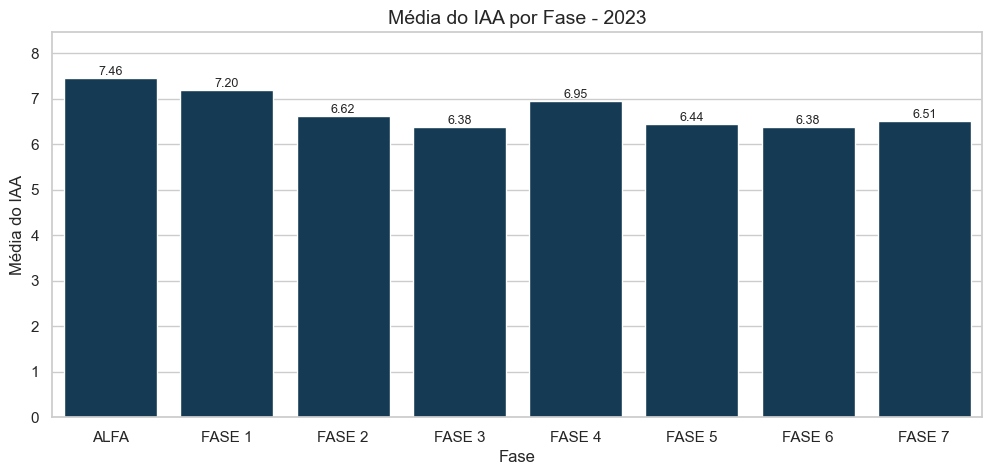

In [102]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IAA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IAA por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IAA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)
    
plt.show()

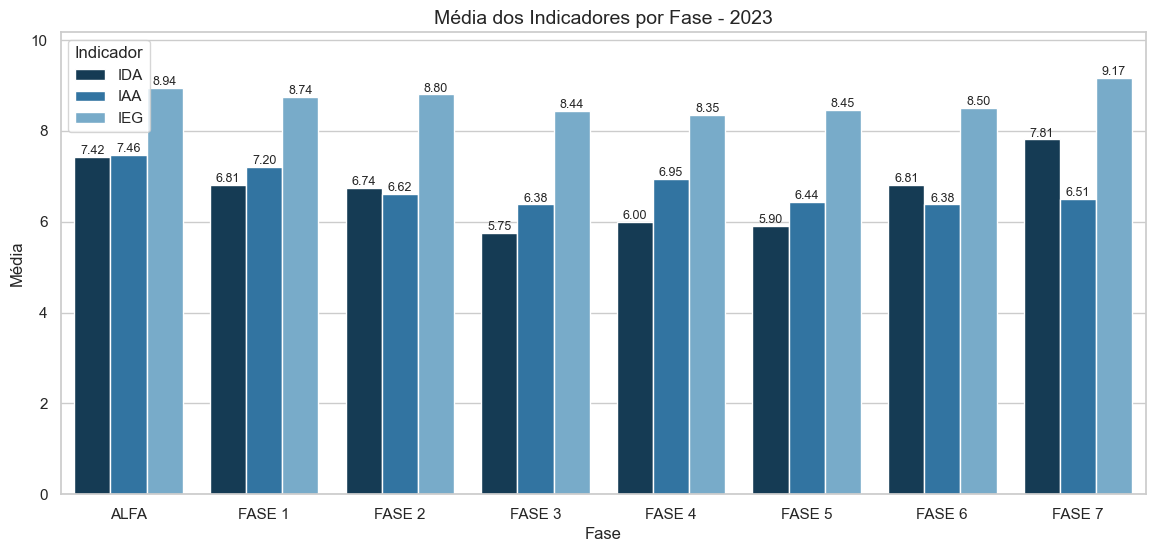

In [103]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2023
    .groupby('Fase')[['IDA', 'IAA', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IAA', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2023", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

In [104]:
df_2023[['IAA', 'IDA', 'IEG']].describe()

,IAA,IDA,IEG
count,951.000000,937.000000,938.000000
mean,6.903049,6.663394,8.699041
std,3.590414,1.595277,1.084001
min,0.000000,0.000000,3.700000
25%,6.700000,5.700000,8.100000
50%,8.500000,6.800000,9.000000
75%,9.200000,7.900000,9.500000
max,10.000000,10.000000,10.000000


In [105]:
#Correlação 
df_2023[['IAA', 'IDA', 'IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,0.104696,0.170271
IDA,0.104696,1.000000,0.461028
IEG,0.170271,0.461028,1.000000


In [106]:
df_2023[['IAA', 'IDA', 'IEG']].isna().sum()

IAA     0
IDA    14
IEG    13
dtype: int64

In [107]:
# IAA x IDA
df_ida = df_2023[['IAA', 'IDA']].dropna()
r_ida, p_ida = pearsonr(df_ida['IAA'], df_ida['IDA'])

# IAA x IPV
df_ieg = df_2023[['IAA', 'IEG']].dropna()
r_ieg, p_ieg = pearsonr(df_ieg['IAA'], df_ieg['IEG'])

print("IAA x IDA -> r:", r_ida, "p:", p_ida)
print("IAA x IEG -> r:", r_ieg, "p:", p_ieg)

IAA x IDA -> r: 0.10469555197121283 p: 0.001330473988183163
IAA x IEG -> r: 0.17027093543665053 p: 1.552238049480967e-07


In [108]:
corr = df_2023[['IEG', 'IDA', 'IAA']].corr()

r_iaa_ida = corr.loc['IAA', 'IDA']
r_iaa_ieg = corr.loc['IAA', 'IEG']

print("IAA x IDA - R²:", r_iaa_ida**2 *100)
print("IAA x IEG - R²:", r_iaa_ieg**2 *100)

IAA x IDA - R²: 1.0961158602556924
IAA x IEG - R²: 2.899219145447227


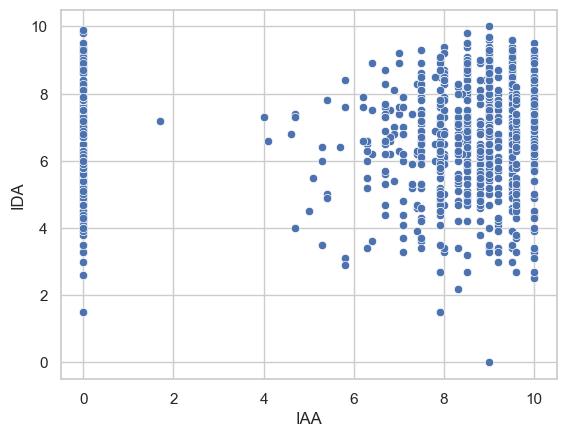

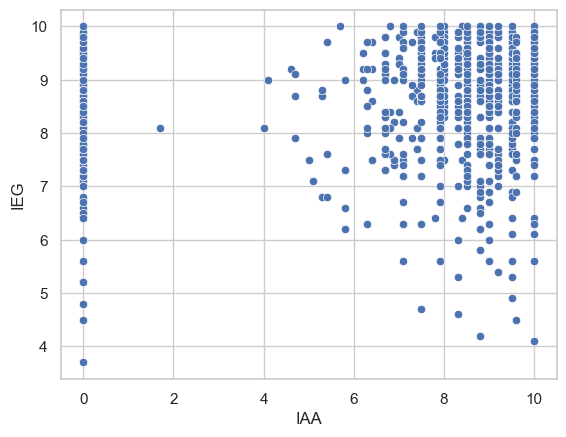

In [109]:
#Gráfico de dispersão

sns.scatterplot(x='IAA', y='IDA', data=df_2023)
plt.show()

sns.scatterplot(x='IAA', y='IEG', data=df_2023)
plt.show()


In [110]:
#Média do IPS 2023
df_2023['IPS'].mean().round(2)

5.12

In [111]:
#Média do IPS por fase
media_por_fase = df_2023.groupby('Fase')['IPS'].mean().round(2)
print(media_por_fase)


Fase
ALFA      5.78
FASE 1    6.12
FASE 2    4.53
FASE 3    4.67
FASE 4    3.79
FASE 5    4.35
FASE 6    5.80
FASE 7    4.96
Name: IPS, dtype: float64


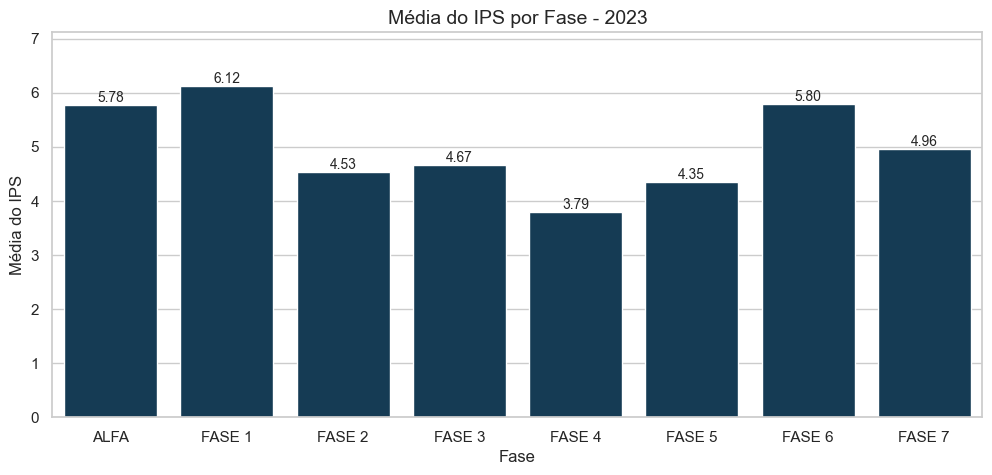

In [112]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IPS'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPS por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPS', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()


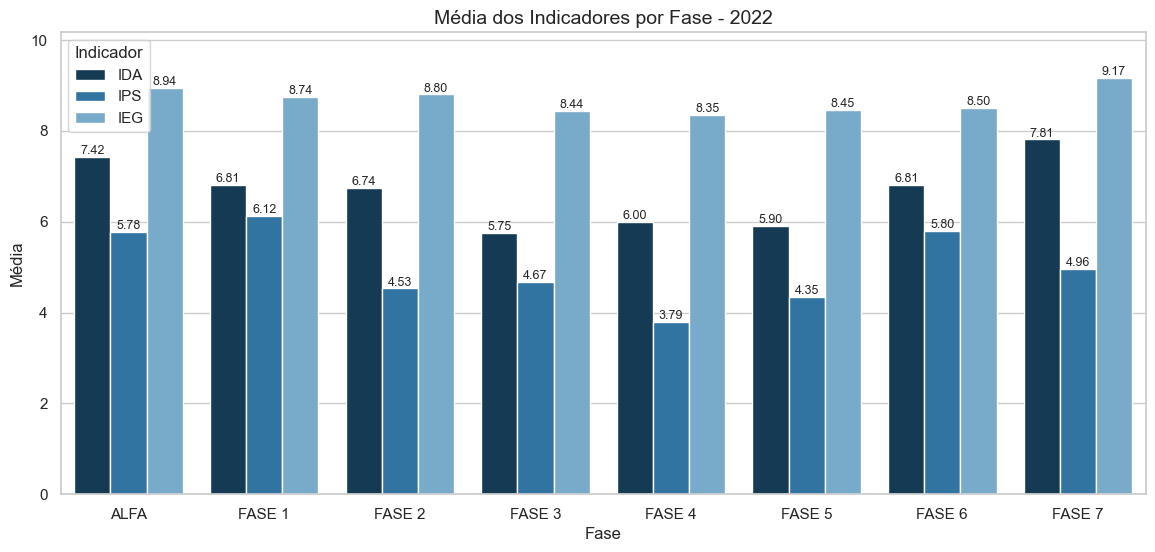

In [113]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2023
    .groupby('Fase')[['IDA', 'IPS', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IPS', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [114]:
df_2023[['IAA', 'IPS', 'IEG']].describe()

,IAA,IPS,IEG
count,951.000000,945.000000,938.000000
mean,6.903049,5.119714,8.699041
std,3.590414,2.090297,1.084001
min,0.000000,2.520000,3.700000
25%,6.700000,2.520000,8.100000
50%,8.500000,5.000000,9.000000
75%,9.200000,7.520000,9.500000
max,10.000000,10.000000,10.000000


In [115]:
#Correlação 
df_2023[['IAA', 'IPS', 'IEG']].corr()
#Correlação de Pearson

,IAA,IPS,IEG
IAA,1.000000,0.034146,0.170271
IPS,0.034146,1.000000,0.044934
IEG,0.170271,0.044934,1.000000


In [116]:
#IPS x IDA
df_ida = df_2023[['IPS', 'IDA']].dropna()
r_ida, p_ida = pearsonr(df_ida['IPS'], df_ida['IDA'])

#IPS x IEG
df_ieg = df_2023[['IPS', 'IEG']].dropna()
r_ieg, p_ieg = pearsonr(df_ieg['IPS'], df_ieg['IEG'])

print("IPS x IDA -> r:", r_ida, "p:", p_ida)
print("IPS x IEG -> r:", r_ieg, "p:", p_ieg)

IPS x IDA -> r: 0.13214560446011478 p: 5.245795689403106e-05
IPS x IEG -> r: 0.04493433305575005 p: 0.17048814103417


In [117]:
corr = df_2023[['IEG', 'IDA', 'IPS']].corr()

r_ips_ida = corr.loc['IPS', 'IDA']
r_ips_ieg = corr.loc['IPS', 'IEG']

print("IPS x IDA - R²:", r_ips_ida**2 *100)
print("IPS x IEG - R²:", r_ips_ieg**2 *100)


IPS x IDA - R²: 1.7462460778129056
IPS x IEG - R²: 0.20190942871652243


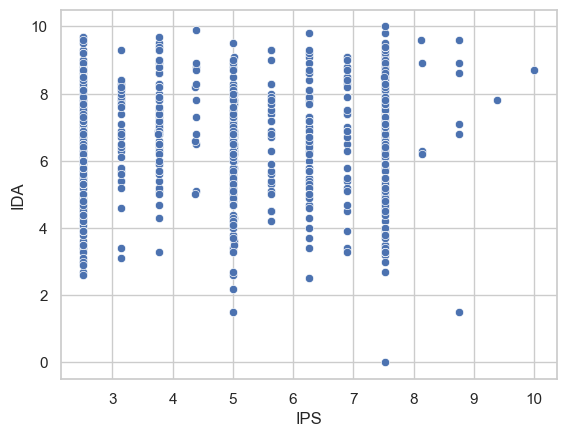

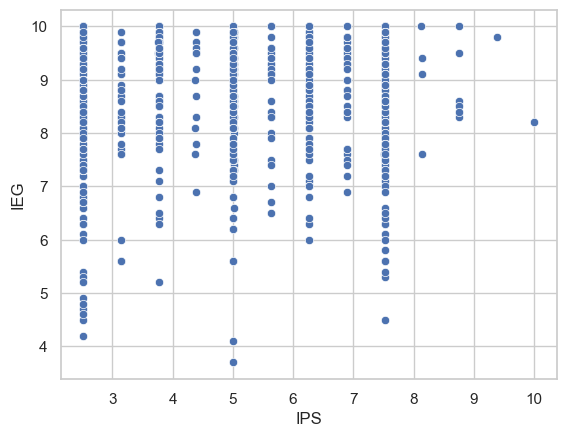

In [118]:
#Gráfico de dispersão

sns.scatterplot(x='IPS', y='IDA', data=df_2023)
plt.show()

sns.scatterplot(x='IPS', y='IEG', data=df_2023)
plt.show()

In [119]:
df_2023 = df_2023.dropna(subset=['IDA'])

In [120]:
df_2023['grupo_ips_bin'] = np.where(df_2023['IPS'] < 7.5, 1, 0)
# 1 = grupo de atenção
# 0 = grupo regular

In [121]:
import statsmodels.api as sm

X = sm.add_constant(df_2023['grupo_ips_bin'])
y = df_2023['IDA']

modelo_ida = sm.OLS(y, X).fit()

print(modelo_ida.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     15.85
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           7.38e-05
Time:                        21:31:40   Log-Likelihood:                -1758.8
No. Observations:                 937   AIC:                             3522.
Df Residuals:                     935   BIC:                             3531.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.9583      0.090     77.029

In [122]:
X = sm.add_constant(df_2023['grupo_ips_bin'])
y = df_2023['IEG']

modelo_ieg = sm.OLS(y, X).fit()

print(modelo_ieg.summary())

                            OLS Regression Results                            
Dep. Variable:                    IEG   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.897
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0891
Time:                        21:31:40   Log-Likelihood:                -1398.4
No. Observations:                 937   AIC:                             2801.
Df Residuals:                     935   BIC:                             2811.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.7886      0.061    142.922

In [123]:
#Não foi necessário criar a IPP

In [124]:
#Média do IPP 2023
df_2023['IPP'].mean().round(2)

7.56

In [125]:
#Média do IPP por fase
media_por_fase = df_2023.groupby('Fase')['IPP'].mean().round(2)
print(media_por_fase)

Fase
ALFA      6.78
FASE 1    7.77
FASE 2    8.15
FASE 3    7.53
FASE 4    7.79
FASE 5    7.56
FASE 6    7.81
FASE 7    7.84
Name: IPP, dtype: float64


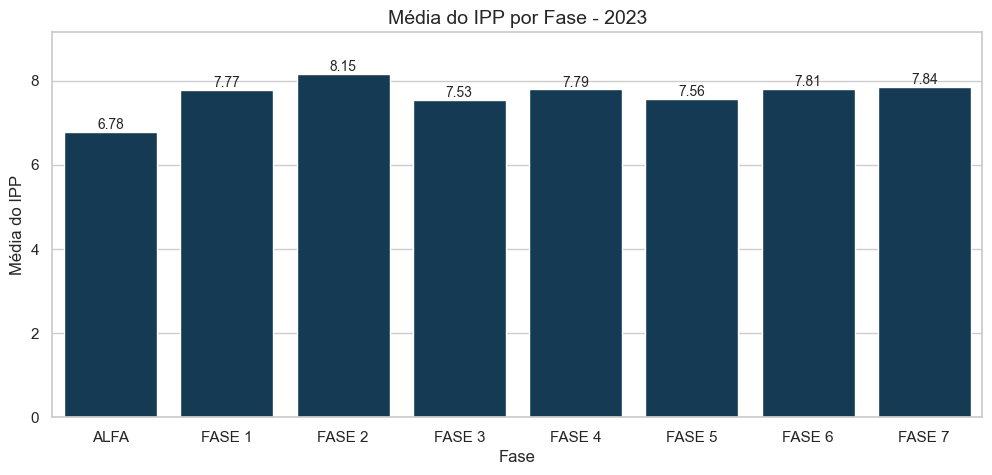

In [126]:

# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\559876399.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(


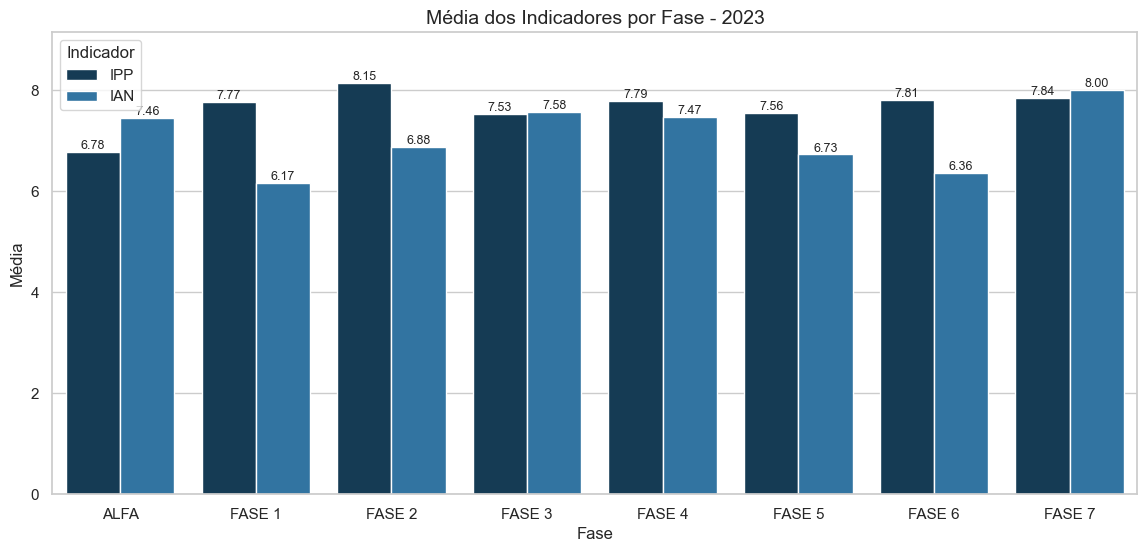

In [127]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2023
    .groupby('Fase')[['IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2023", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [128]:
df_2023[['IPP', 'IAN']].describe()

,IPP,IAN
count,937.000000,937.000000
mean,7.563245,7.033084
std,0.984725,2.513739
min,3.750000,2.500000
25%,7.083333,5.000000
50%,7.656250,5.000000
75%,8.125000,10.000000
max,9.791667,10.000000


In [129]:
#Correlação 
df_2023[['IPP', 'IAN']].corr()


#Correlação de Pearson
r_ian2, p_ian2 = pearsonr(df_2023['IPP'], df_2023['IAN'])

print("IPP x IAN -> r:", r_ian2, "p:", p_ian2)


IPP x IAN -> r: 0.09452111818705544 p: 0.003780028589878826


In [130]:
corr = df_2023[['IPP', 'IAN']].corr()

r_ipp_ian = corr.loc['IPP', 'IAN']

print("IAA x IDA - R²:", r_ipp_ian**2 *100)

IAA x IDA - R²: 0.893424178333151


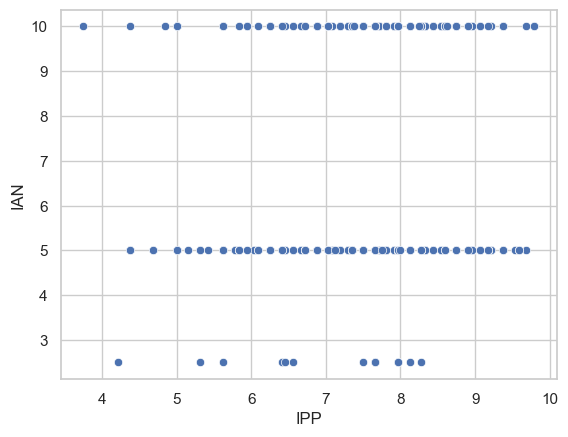

In [131]:
#Gráfico de dispersão

sns.scatterplot(x='IPP', y='IAN', data=df_2023)
plt.show()


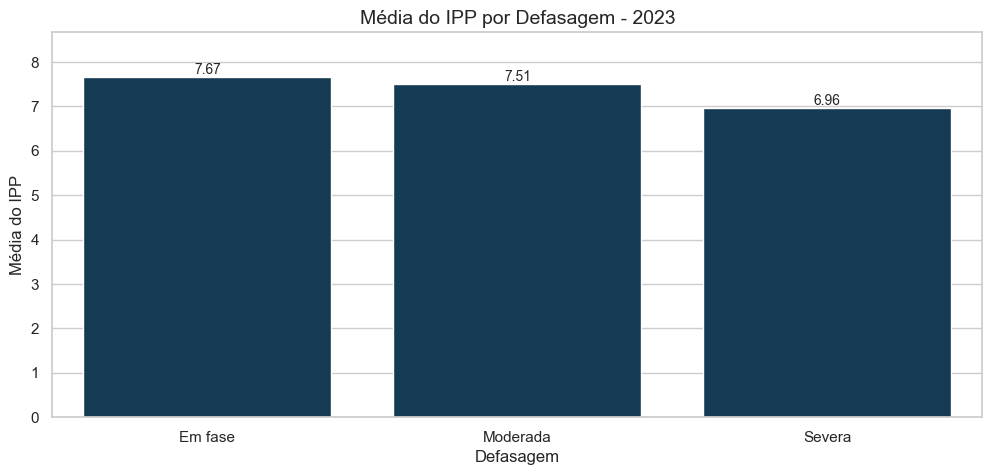

In [132]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Defasagem_Nome')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Defasagem - 2023", fontsize=14)
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [133]:
#Correlação
df_2023[['IDA', 'IEG', 'IAA', 'IPV']].corr()

,IDA,IEG,IAA,IPV
IDA,1.000000,0.461028,0.104696,0.544204
IEG,0.461028,1.000000,0.164878,0.447941
IAA,0.104696,0.164878,1.000000,0.136339
IPV,0.544204,0.447941,0.136339,1.000000


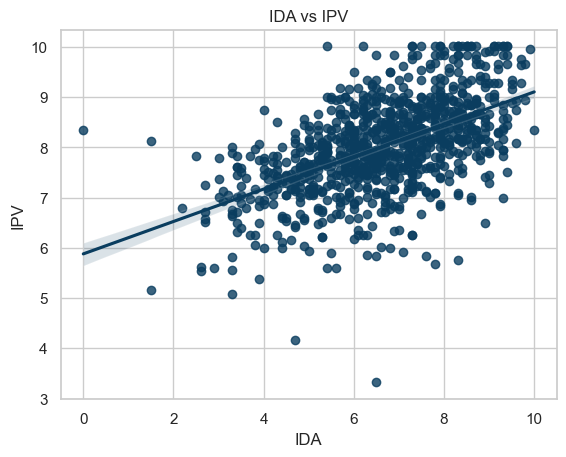

In [134]:
plt.figure()
sns.regplot(x='IDA', y='IPV', data=df_2023)
plt.title("IDA vs IPV")
plt.show()

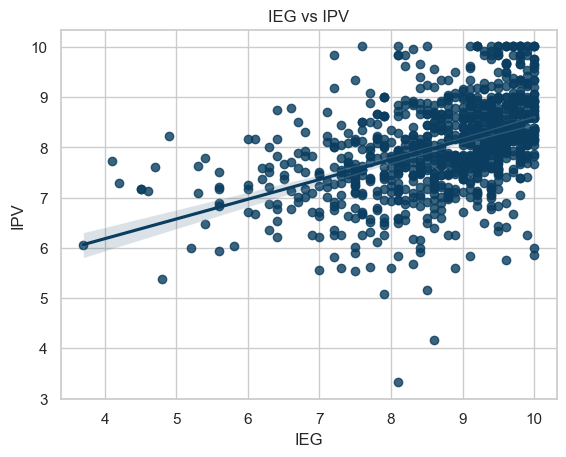

In [135]:
plt.figure()
sns.regplot(x='IEG', y='IPV', data=df_2023)
plt.title("IEG vs IPV")
plt.show()

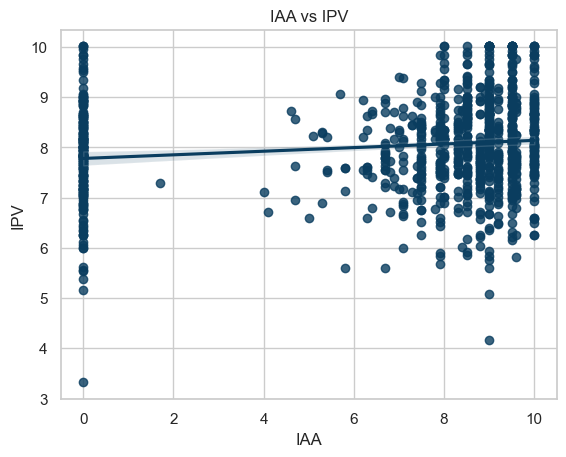

In [136]:
plt.figure()
sns.regplot(x='IAA', y='IPV', data=df_2023)
plt.title("IAA vs IPV")
plt.show()

In [137]:

X = df_2023[['IDA', 'IEG', 'IAA']]
y = df_2023['IPV']

X = sm.add_constant(X)  # adiciona intercepto

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IPV   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     166.0
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           3.07e-86
Time:                        21:31:42   Log-Likelihood:                -1076.0
No. Observations:                 937   AIC:                             2160.
Df Residuals:                     933   BIC:                             2179.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3981      0.204     21.545      0.0

In [138]:
# supondo que df já tem as colunas
df_2023["contrib_IDA"] = 0.2 * df_2023["IDA"]
df_2023["contrib_IEG"] = 0.2 * df_2023["IEG"]
df_2023["contrib_IPS"] = 0.1 * df_2023["IPS"]
df_2023["contrib_IPP"] = 0.1 * df_2023["IPP"]

# soma da combinação analisada
df_2023["contrib_combinacao"] = (
    df_2023["contrib_IDA"] +
    df_2023["contrib_IEG"] +
    df_2023["contrib_IPS"] +
    df_2023["contrib_IPP"]

)

In [139]:
df_2023[["contrib_combinacao", "INDE 2023"]].corr()

,contrib_combinacao,INDE 2023
contrib_combinacao,1.000000,0.849833
INDE 2023,0.849833,1.000000


In [140]:
#Isso mostra o quanto essa combinação explica o INDE.

#Conceitualmente:

#IDA e IEG têm peso 0.2 → maior impacto estrutural

#IPS e IPP têm peso 0.1 → impacto moderado

#Então combinações com IDA e IEG altos naturalmente elevam mais o INDE.

In [141]:
df_2023["IDA_IEG"] = df_2023["IDA"] * df_2023["IEG"]
df_2023["IDA_IPS"] = df_2023["IDA"] * df_2023["IPS"]

In [142]:
print(df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]].isna().sum())
print(df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]].isin([np.inf, -np.inf]).sum())

IDA        0
IEG        0
IPS        6
IPP        0
IDA_IEG    0
IDA_IPS    6
dtype: int64
IDA        0
IEG        0
IPS        0
IPP        0
IDA_IEG    0
IDA_IPS    0
dtype: int64


In [143]:
X = df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]]
y = df_2023["INDE 2023"]

# Remove linhas onde X ou y tenham NaN
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

X_clean = sm.add_constant(X_clean)
modelo = sm.OLS(y_clean, X_clean).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              INDE 2023   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     429.5
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          3.09e-263
Time:                        21:31:42   Log-Likelihood:                -604.17
No. Observations:                 931   AIC:                             1222.
Df Residuals:                     924   BIC:                             1256.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4264      0.506      4.792      0.0

In [144]:
#Média do INDE 2023
df_2023['INDE 2023'].mean().round(2)

7.34

In [145]:
#Média do INDE por fase
media_por_fase = df_2023.groupby('Fase')['INDE 2023'].mean().round(2)
print(media_por_fase)

Fase
ALFA      7.68
FASE 1    7.45
FASE 2    7.37
FASE 3    6.97
FASE 4    7.07
FASE 5    6.87
FASE 6    7.24
FASE 7    7.83
Name: INDE 2023, dtype: float64


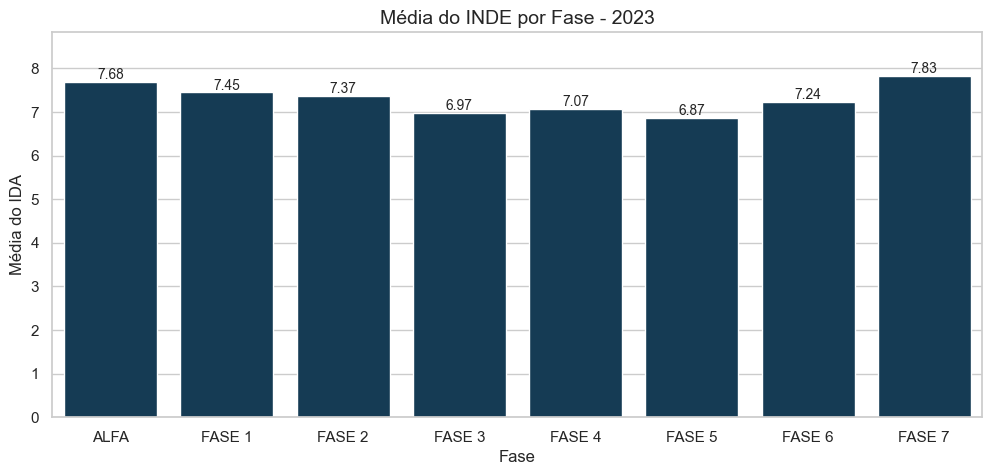

In [146]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2023.groupby('Fase')['INDE 2023'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do INDE por Fase - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\2682146056.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores


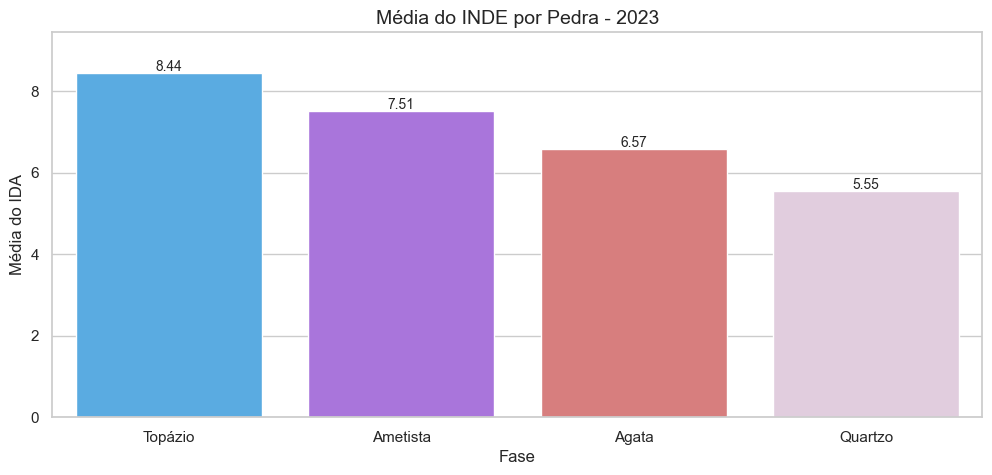

In [147]:
# Configurações de estilo
sns.set(style="whitegrid")

# Calcula a média por fase
media_por_fase = df_2023.groupby('Pedra 2023')['INDE 2023'].mean().round(2).sort_values(ascending=False)

cores_pedras = {
    "Ametista": "#AA64EC",   # roxo pastel
    "Quartzo": "#E4CAE0",    # rosa pastel
    "Topázio": "#43B0F8",    # azul pastel
    "Agata": "#E66F6F"       # vermelho pastel
}   

cores = [cores_pedras[pedra] for pedra in media_por_fase.index]

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores
)

# Título e labels
plt.title("Média do INDE por Pedra - 2023", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v + 0.05, f'{v:.2f}', 
            ha='center', fontsize=10)

plt.show()

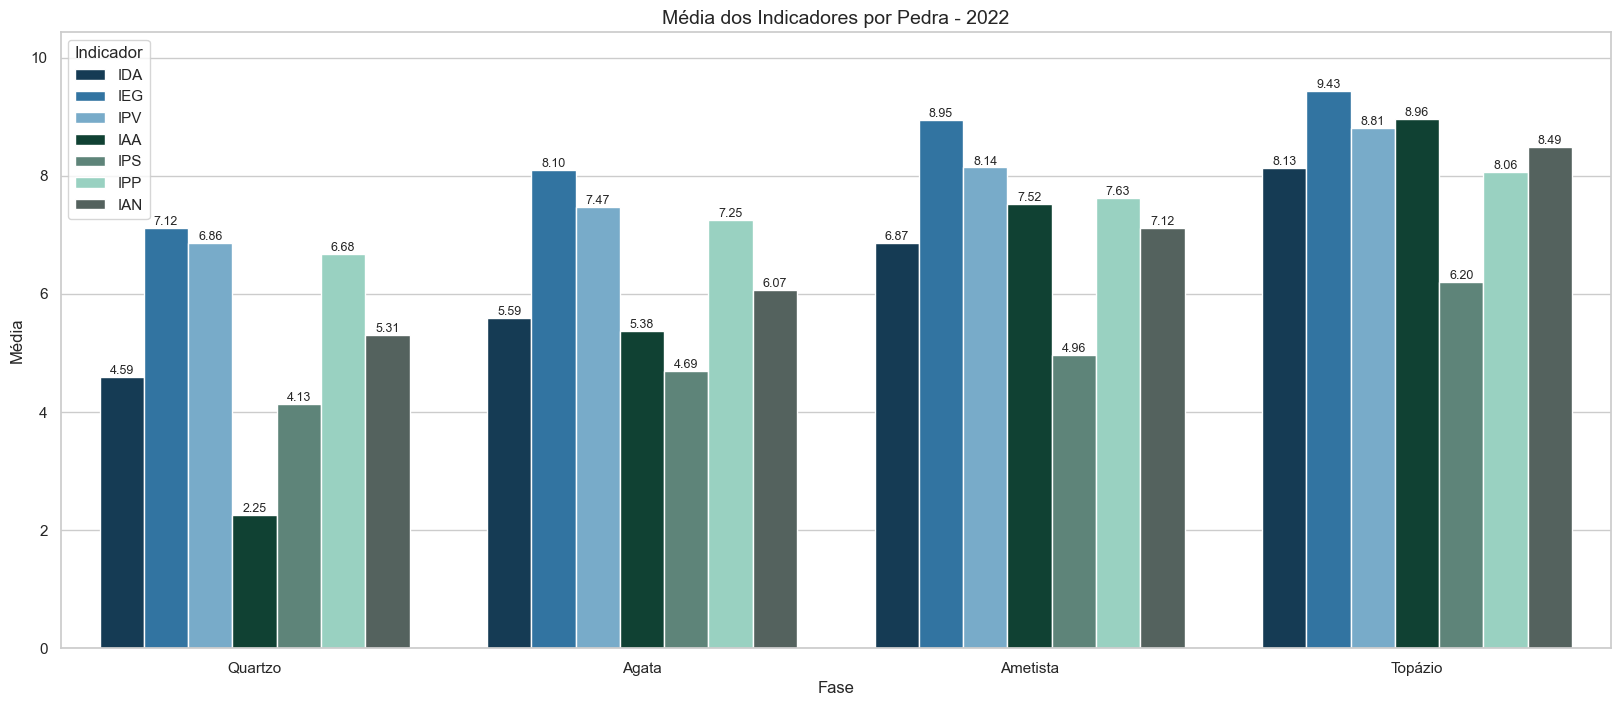

In [148]:
# Configuração de estilo

#ordem personalizada das pedras
ordem_pedras = ["Quartzo", "Agata", "Ametista", "Topázio"]

# Calcula média por pedra
media_por_fase = (
    df_2023
    .groupby('Pedra 2023')[['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

#Transforma em categórica com ordem definida
media_por_fase['Pedra 2023'] = pd.Categorical(
    media_por_fase['Pedra 2023'],
    categories=ordem_pedras,
    ordered=True
)

#Ordena pela ordem que você definiu
media_por_fase = media_por_fase.sort_values('Pedra 2023')

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Pedra 2023',
    value_vars=['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(20,8))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6", "#084936", "#578B7C", "#90DAC5", "#52645F"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Pedra 2023',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Pedra - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

DF 2024

In [149]:
df_2024.shape

(1156, 50)

In [150]:
#Quantos alunos ingressaram nesse ano 
df_2024_ingressantes = df_2024.loc[df_2024['Ano ingresso'] == 2024]
df_2024_ingressantes.shape

(349, 50)

In [151]:
df_2024['Gênero'].value_counts()

Gênero
Feminino     623
Masculino    533
Name: count, dtype: int64

In [152]:
df_2024['Instituição de ensino'].value_counts()

Instituição de ensino
Pública                                      913
Privada - Programa de Apadrinhamento          96
Privada                                       76
Privada *Parcerias com Bolsa 100%             41
Bolsista Universitário *Formado (a)           13
Privada - Pagamento por *Empresa Parceira      9
Concluiu o 3º EM                               7
Name: count, dtype: int64

In [153]:
df_2024['Fase'].unique()

array(['ALFA', '1A', '1B', '1C', '1D', '1E', '1G', '1H', '1J', '1K', '1L',
       '1M', '1N', '1P', '1R', '2A', '2B', '2C', '2D', '2G', '2H', '2I',
       '2K', '2L', '2M', '2N', '2P', '2R', '2U', '3A', '3B', '3C', '3D',
       '3F', '3G', '3H', '3I', '3K', '3L', '3M', '3N', '3P', '3R', '3U',
       '4A', '4B', '4C', '4F', '4H', '4L', '4M', '4N', '4R', '5A', '5B',
       '5C', '5D', '5F', '5G', '5L', '5M', '5N', '6A', '6L', '7A', '7E',
       '8A', '8B', '8D', '8E', '8F', 9], dtype=object)

In [154]:
#Filtra o DataFrame mantendo apenas o que NÃO é vazio
df_2024 = df_2024[df_2024['Fase'] != 9]

In [155]:
#Definimos a função de limpeza
def limpar_fase(v):
    #Se for ALFA, transformamos em '0'
    if v == 'ALFA':
        return '0'
    
    # Para os demais (ex: '1A', '2B'), remove as letras e sobra o número
    return re.sub(r'\D', '', str(v))

#Aplicamos a função na coluna e SOBRESCREVEMOS a coluna original
df_2024['Fase'] = df_2024['Fase'].apply(limpar_fase)


#Agora, se você der o unique, verá os valores limpos
print(df_2024['Fase'].unique())

['0' '1' '2' '3' '4' '5' '6' '7' '8']


In [172]:
#Filtra o DataFrame mantendo apenas o que NÃO é vazio
df_2024 = df_2024[df_2024['Fase'] != 8]

In [157]:
#mudar a coluna fase de object para int 
df_2024['Fase'] = df_2024['Fase'].astype(int)

In [158]:
#alunos por fase
df_2024['Fase'].value_counts().sort_index()

Fase
0    196
1    185
2    185
3    211
4    115
5    100
6     25
7     37
8     64
Name: count, dtype: int64

In [159]:
#Contagem dos valores de defasagem
mapa = {
    2.5: 'Severa',
    5: 'Moderada',
    10: 'Em fase'
   
}

df_2024['Defasagem_Nome'] = (
    df_2024['IAN'].replace(mapa)
)

df_2024['Defasagem_Nome'].value_counts()

Defasagem_Nome
Em fase     584
Moderada    531
Severa        3
Name: count, dtype: int64

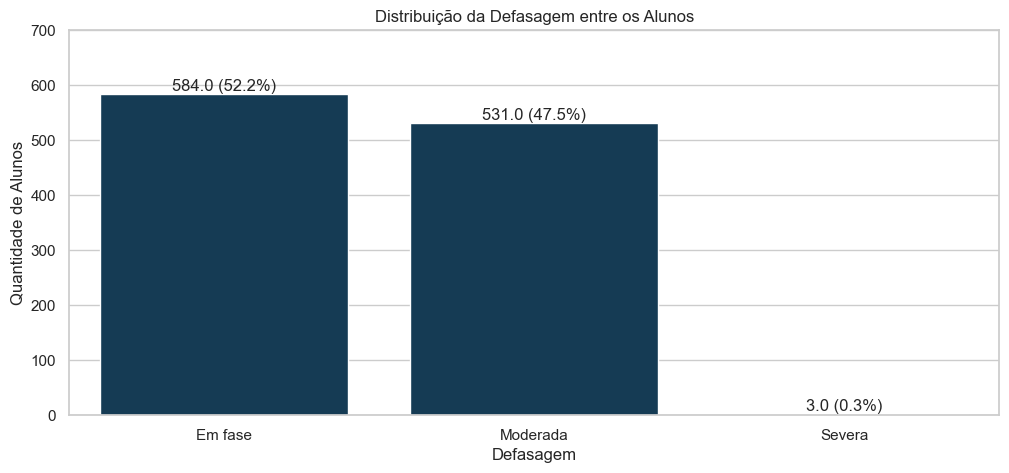

In [160]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(12,5)) 

ax = sns.countplot(x='Defasagem_Nome', data=df_2024) 

plt.title("Distribuição da Defasagem entre os Alunos") 
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)

ax.set_ylim(0,700)
total = len(df_2024) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()

In [161]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1118 entries, 0 to 1117
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1118 non-null   object        
 1   Fase                   1118 non-null   int32         
 2   INDE 2024              1054 non-null   object        
 3   Pedra 2024             1054 non-null   object        
 4   Turma                  1118 non-null   object        
 5   Nome Anonimizado       1118 non-null   object        
 6   Data de Nasc           1118 non-null   datetime64[ns]
 7   Idade                  1118 non-null   int64         
 8   Gênero                 1118 non-null   object        
 9   Ano ingresso           1118 non-null   int64         
 10  Instituição de ensino  1117 non-null   object        
 11  Pedra 20               191 non-null    object        
 12  Pedra 21               264 non-null    object        
 13  Pedra 22

In [162]:
df_2024.describe()

,Fase,Data de Nasc,Idade,Ano ingresso,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,...,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV
count,1118.000000,1118,1118.000000,1118.000000,472.000000,690.000000,0.0,0.0,0.0,1118.000000,...,1050.000000,474.000000,0.0,0.0,1054.000000,1118.000000,1118.000000,0.0,0.0,0.0
mean,2.745081,2011-08-28 04:28:45.939176960,12.687835,2022.570662,7.368276,7.455472,NaN,NaN,NaN,3.051878,...,6.175762,6.595886,NaN,NaN,7.354268,7.605098,-0.457066,NaN,NaN,NaN
min,0.000000,1996-12-08 02:00:00,7.000000,2021.000000,3.031806,4.406458,NaN,NaN,NaN,0.000000,...,0.000000,0.000000,NaN,NaN,2.943333,2.500000,-3.000000,NaN,NaN,NaN
25%,1.000000,2009-06-11 06:00:00,10.000000,2021.000000,6.890881,6.862402,NaN,NaN,NaN,2.000000,...,5.000000,5.000000,NaN,NaN,6.790625,5.000000,-1.000000,NaN,NaN,NaN
50%,2.000000,2012-02-21 00:00:00,12.000000,2023.000000,7.475431,7.559046,NaN,NaN,NaN,3.000000,...,6.500000,7.000000,NaN,NaN,7.500000,10.000000,0.000000,NaN,NaN,NaN
75%,4.000000,2014-03-02 06:00:00,15.000000,2024.000000,7.981160,8.048758,NaN,NaN,NaN,4.000000,...,8.000000,9.000000,NaN,NaN,8.085000,10.000000,0.000000,NaN,NaN,NaN
max,8.000000,2017-06-02 00:00:00,27.000000,2024.000000,9.441522,9.371200,NaN,NaN,NaN,6.000000,...,10.000000,10.000000,NaN,NaN,9.760000,10.000000,3.000000,NaN,NaN,NaN
std,2.228719,NaN,3.240309,1.192305,0.861821,0.850390,NaN,NaN,NaN,1.309353,...,2.379552,2.876249,NaN,NaN,1.048541,2.508964,0.823469,NaN,NaN,NaN


In [163]:
#Média do IDA 2024
df_2024['IDA'].mean().round(2)

6.35

In [164]:
#Média do IDA por fase
media_por_fase = df_2024.groupby('Fase')['IDA'].mean().round(2)
print(media_por_fase)

Fase
0    7.32
1    6.79
2    6.25
3    5.35
4    5.88
5    6.45
6    7.23
7    5.81
8    8.00
Name: IDA, dtype: float64


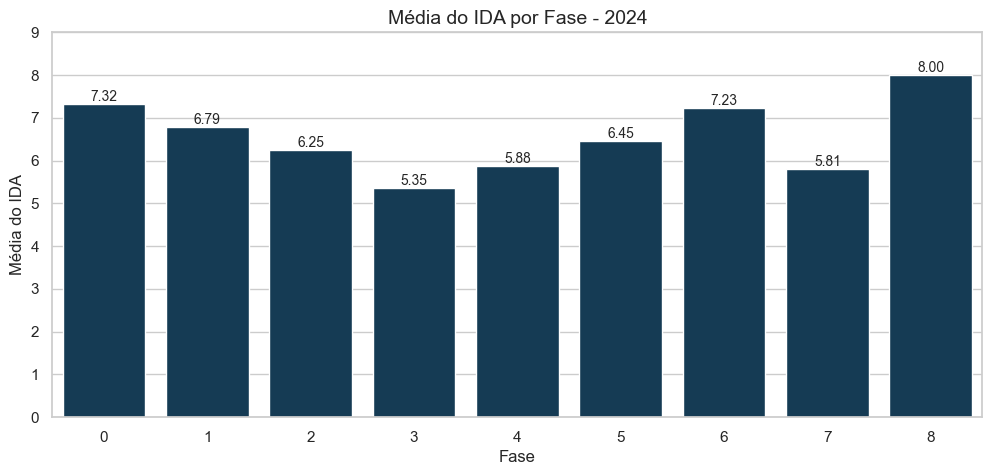

In [165]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IDA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IDA por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [166]:
#Média do IEG 2024
df_2024['IEG'].mean().round(2)

7.63

In [167]:
#Média do IGE por fase
media_por_fase = df_2024.groupby('Fase')['IEG'].mean().round(2)
print(media_por_fase)

Fase
0    8.50
1    8.49
2    7.96
3    7.39
4    7.95
5    8.47
6    8.80
7    7.44
8    0.00
Name: IEG, dtype: float64


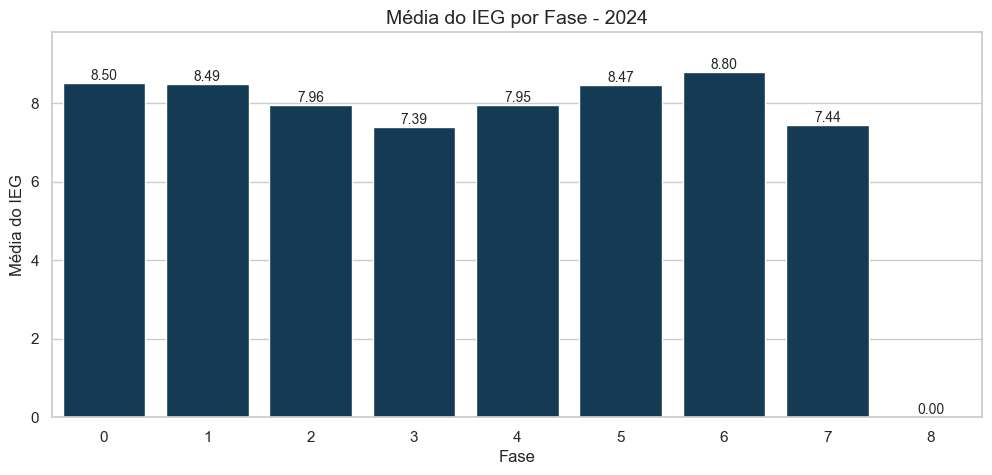

In [168]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IEG'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IEG por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IEG', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [169]:
#Média do IPV 2024
df_2024['IPV'].mean().round(2)

7.35

In [170]:
#Média do IPV por fase
media_por_fase = df_2024.groupby('Fase')['IPV'].mean().round(2)
print(media_por_fase)

Fase
0    7.28
1    7.50
2    7.21
3    6.95
4    7.84
5    7.56
6    7.76
7    7.64
8     NaN
Name: IPV, dtype: float64


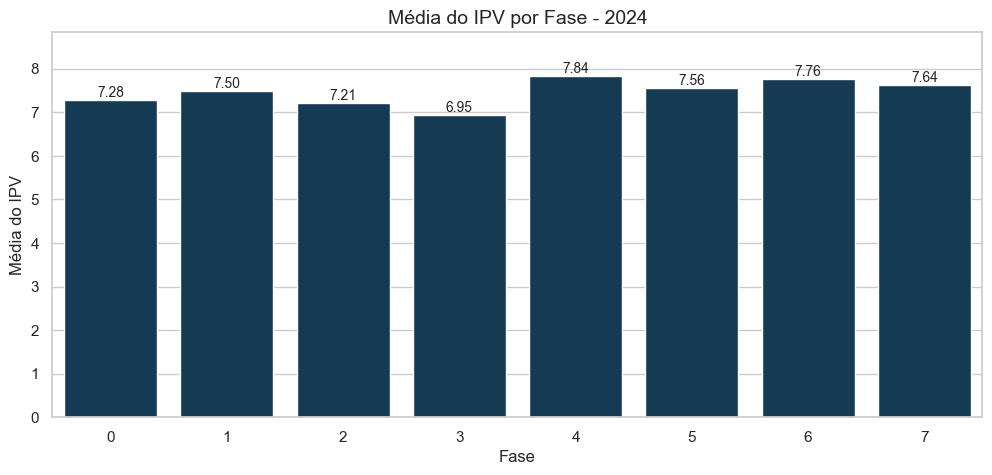

In [173]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IPV'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPV por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPV', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

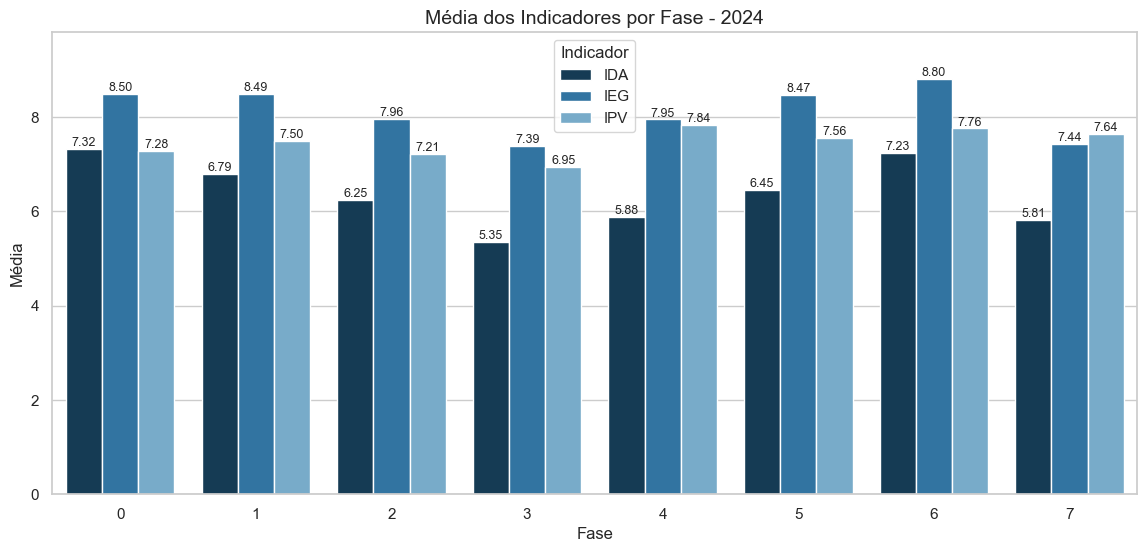

In [174]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2024
    .groupby('Fase')[['IDA', 'IEG', 'IPV']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IEG', 'IPV'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2024", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

In [175]:
df_2024[['IEG', 'IDA', 'IPV']].describe()

,IEG,IDA,IPV
count,1054.000000,1054.000000,1054.000000
mean,8.088696,6.349858,7.354268
std,1.763934,2.132045,1.048541
min,0.000000,0.000000,2.943333
25%,7.145337,4.875000,6.790625
50%,8.592202,6.750000,7.500000
75%,9.500000,8.000000,8.085000
max,10.000000,10.000000,9.760000


In [176]:
#Correlação 
df_2024[['IEG', 'IDA', 'IPV']].corr()

,IEG,IDA,IPV
IEG,1.000000,0.547277,0.535287
IDA,0.547277,1.000000,0.513745
IPV,0.535287,0.513745,1.000000


In [177]:
#Correlação de Pearson

r_ida, p_ida = pearsonr(df_2024['IEG'], df_2024['IDA'])
r_ipv, p_ipv = pearsonr(df_2024['IEG'], df_2024['IPV'])

print("IEG x IDA -> r:", r_ida, "p:", p_ida)
print("IEG x IPV -> r:", r_ipv, "p:", p_ipv)

IEG x IDA -> r: 0.5472774723122529 p: 2.1489441045928838e-83
IEG x IPV -> r: 0.5352867733926087 p: 3.437411437580175e-79


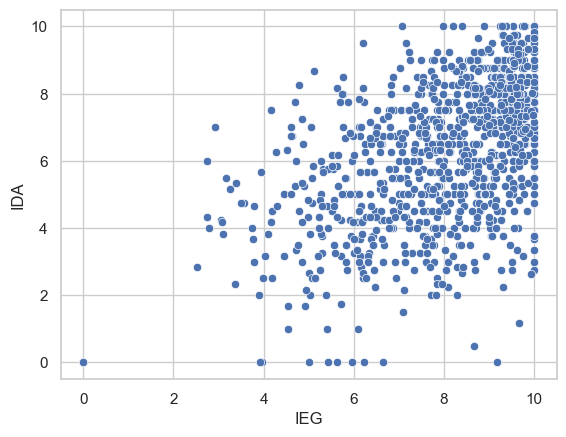

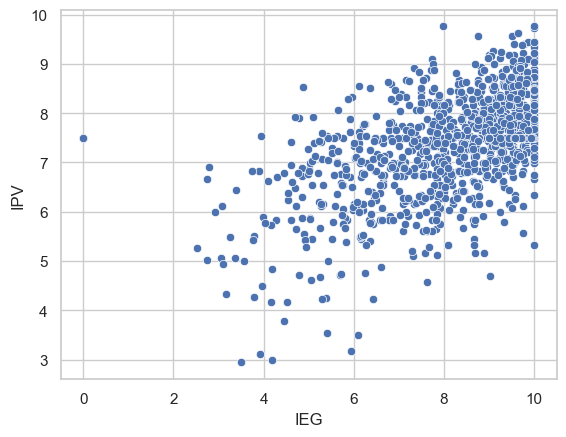

In [178]:
#Gráfico de dispersão

sns.scatterplot(x='IEG', y='IDA', data=df_2024)
plt.show()

sns.scatterplot(x='IEG', y='IPV', data=df_2024)
plt.show()

In [179]:
#Média do IAA 2024
df_2024['IAA'].mean().round(2)

8.54

In [180]:
#Média do IAA por fase
media_por_fase = df_2024.groupby('Fase')['IAA'].mean().round(2)
print(media_por_fase)

Fase
0    8.99
1    8.81
2    8.20
3    8.48
4    8.11
5    8.30
6    8.65
7    8.86
Name: IAA, dtype: float64


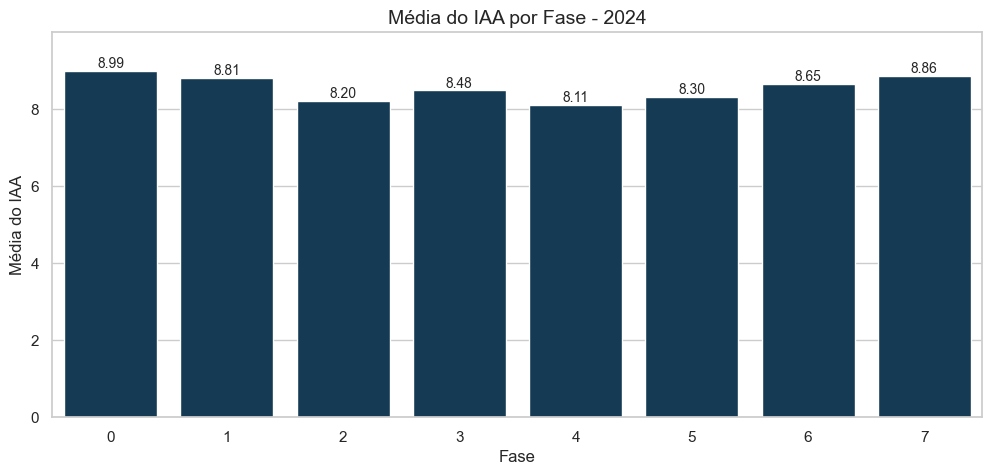

In [181]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IAA'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IAA por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IAA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

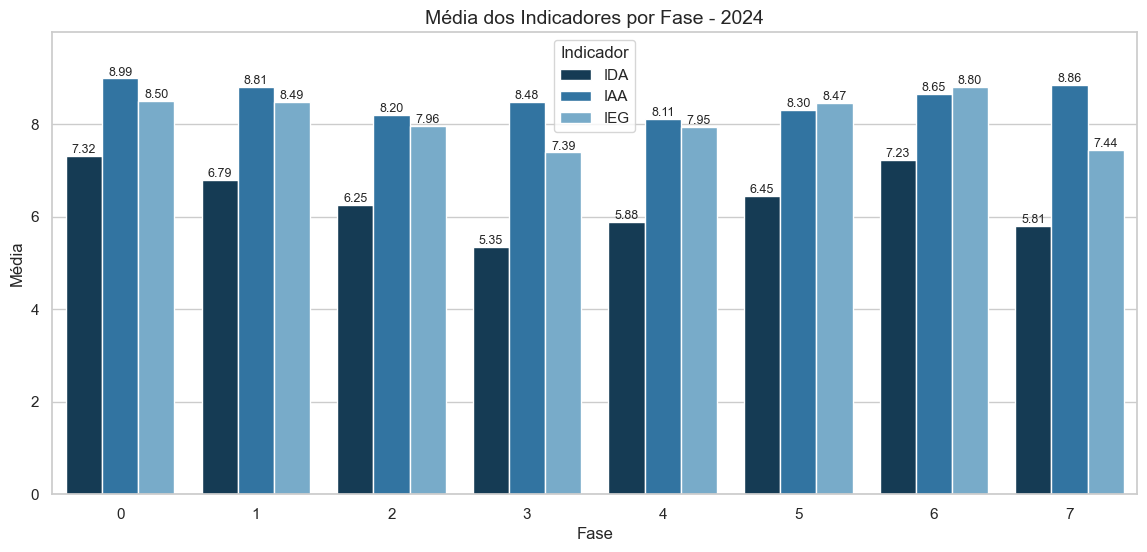

In [182]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2024
    .groupby('Fase')[['IDA', 'IAA', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IAA', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2024", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [183]:
df_2024[['IAA', 'IDA', 'IEG']].describe()

,IAA,IDA,IEG
count,1054.000000,1054.000000,1054.000000
mean,8.543563,6.349858,8.088696
std,1.491450,2.132045,1.763934
min,0.000000,0.000000,0.000000
25%,8.002000,4.875000,7.145337
50%,8.751000,6.750000,8.592202
75%,9.502000,8.000000,9.500000
max,10.002000,10.000000,10.000000


In [184]:
#Correlação 
df_2024[['IAA', 'IDA', 'IEG']].corr()

,IAA,IDA,IEG
IAA,1.000000,0.219653,0.230092
IDA,0.219653,1.000000,0.547277
IEG,0.230092,0.547277,1.000000


In [185]:
#Correlação de Pearson

r_ida, p_ida = pearsonr(df_2024['IAA'], df_2024['IDA'])
r_ieg, p_ieg = pearsonr(df_2024['IAA'], df_2024['IEG'])

print("IAA x IDA -> r:", r_ida, "p:", p_ida)
print("IAA x IEG -> r:", r_ieg, "p:", p_ieg)


IAA x IDA -> r: 0.2196528962808858 p: 5.558728418991353e-13
IAA x IEG -> r: 0.23009239725141795 p: 3.942764384272643e-14


In [186]:
corr = df_2024[['IEG', 'IDA', 'IAA']].corr()

r_iaa_ida = corr.loc['IAA', 'IDA']
r_iaa_ieg = corr.loc['IAA', 'IEG']

print("IAA x IDA - R²:", r_iaa_ida**2 *100)
print("IAA x IEG - R²:", r_iaa_ieg**2 *100)

IAA x IDA - R²: 4.824739484458206
IAA x IEG - R²: 5.294251127290424


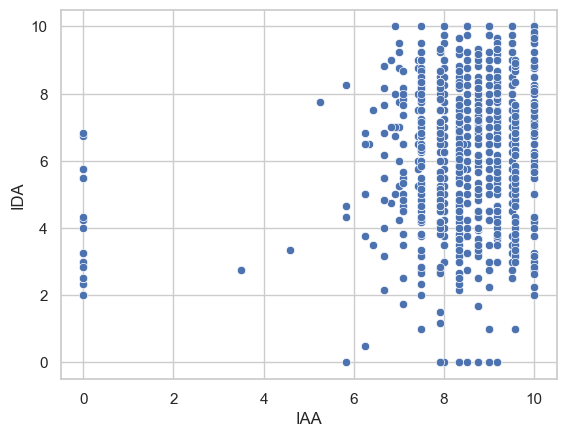

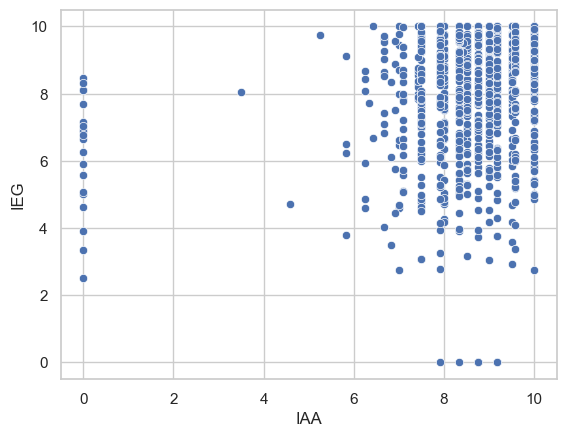

In [187]:
#Gráfico de dispersão

sns.scatterplot(x='IAA', y='IDA', data=df_2024)
plt.show()

sns.scatterplot(x='IAA', y='IEG', data=df_2024)
plt.show()

In [188]:
#Média do IPS 2024
df_2024['IPS'].mean().round(2)

6.83

In [189]:
#Média do IPS por fase
media_por_fase = df_2024.groupby('Fase')['IPS'].mean().round(2)
print(media_por_fase)

Fase
0    6.26
1    6.97
2    6.96
3    7.17
4    6.66
5    6.74
6    6.86
7    7.30
Name: IPS, dtype: float64


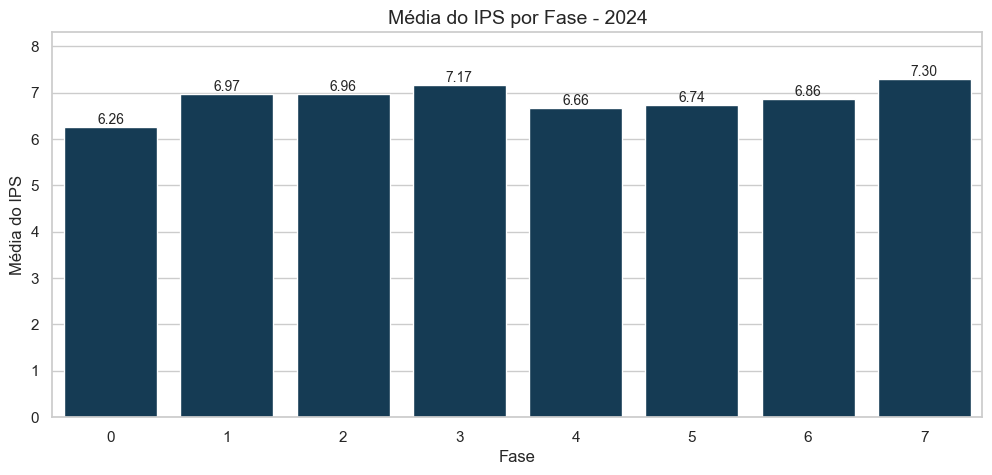

In [190]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IPS'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPS por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPS', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

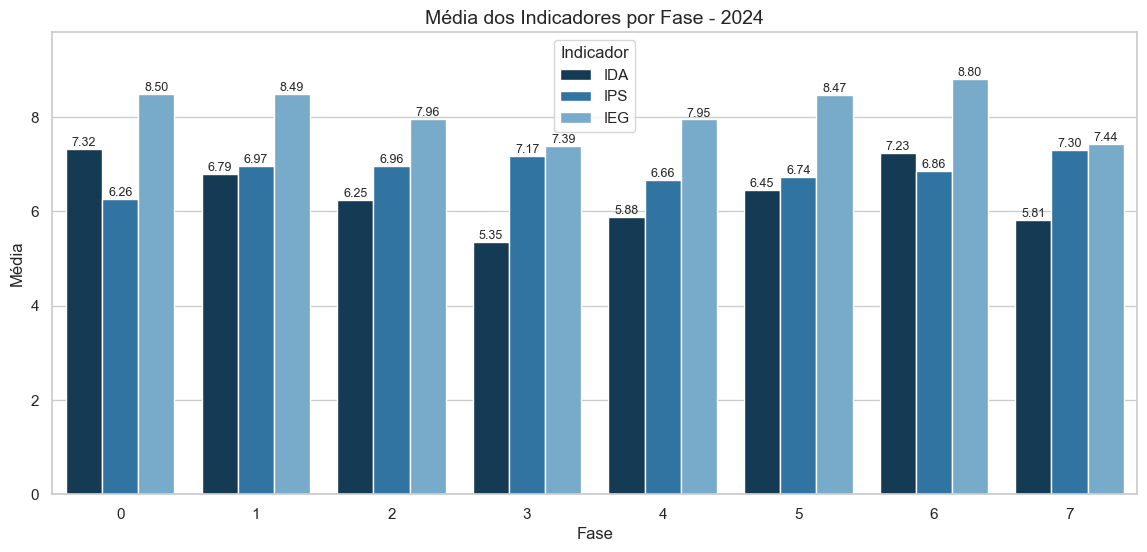

In [191]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2024
    .groupby('Fase')[['IDA', 'IPS', 'IEG']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IDA', 'IPS', 'IEG'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 2024", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [192]:
df_2024[['IAA', 'IPS', 'IEG']].describe()

,IAA,IPS,IEG
count,1054.000000,1054.000000,1054.000000
mean,8.543563,6.829670,8.088696
std,1.491450,1.427893,1.763934
min,0.000000,2.510000,0.000000
25%,8.002000,6.260000,7.145337
50%,8.751000,7.510000,8.592202
75%,9.502000,7.510000,9.500000
max,10.002000,10.000000,10.000000


In [193]:
#Correlação 
df_2024[['IAA', 'IPS', 'IEG']].corr()
#Correlação de Pearson

,IAA,IPS,IEG
IAA,1.000000,-0.005994,0.230092
IPS,-0.005994,1.000000,0.060655
IEG,0.230092,0.060655,1.000000


In [194]:
r_ida, p_ida = pearsonr(df_2024['IPS'], df_2024['IDA'])
r_ieg, p_ieg = pearsonr(df_2024['IPS'], df_2024['IEG'])

print("IPS x IDA -> r:", r_ida, "p:", p_ida)
print("IPS x IEG -> r:", r_ieg, "p:", p_ieg)


IPS x IDA -> r: 0.014493561763738214 p: 0.6383513512013788
IPS x IEG -> r: 0.06065525741249898 p: 0.04899085039358868


In [195]:
corr = df_2024[['IEG', 'IDA', 'IPS']].corr()

r_ips_ida = corr.loc['IPS', 'IDA']
r_ips_ieg = corr.loc['IPS', 'IEG']

print("IPS x IDA - R²:", r_ips_ida**2 *100)
print("IPS x IEG - R²:", r_ips_ieg**2 *100)


IPS x IDA - R²: 0.02100633325992735
IPS x IEG - R²: 0.3679060251776582


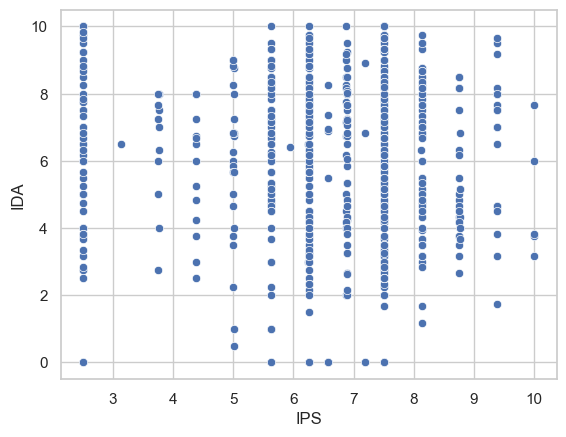

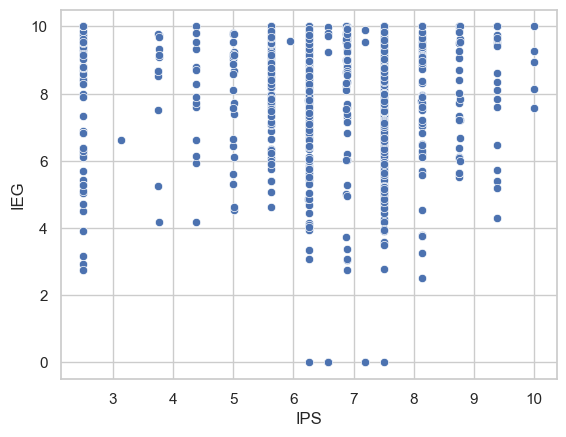

In [196]:
#Gráfico de dispersão

sns.scatterplot(x='IPS', y='IDA', data=df_2024)
plt.show()

sns.scatterplot(x='IPS', y='IEG', data=df_2024)
plt.show()


In [197]:
df_2024['grupo_ips_bin'] = np.where(df_2024['IPS'] < 7.5, 1, 0)
# 1 = grupo de atenção
# 0 = grupo regular

In [198]:
import statsmodels.api as sm

X = sm.add_constant(df_2024['grupo_ips_bin'])
y = df_2024['IDA']

modelo_ida = sm.OLS(y, X).fit()

print(modelo_ida.summary())

                            OLS Regression Results                            
Dep. Variable:                    IDA   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.583
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.108
Time:                        21:32:11   Log-Likelihood:                -2291.7
No. Observations:                1054   AIC:                             4587.
Df Residuals:                    1052   BIC:                             4597.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             6.4352      0.084     76.236

In [199]:
X = sm.add_constant(df_2024['grupo_ips_bin'])
y = df_2024['IEG']

modelo_ieg = sm.OLS(y, X).fit()

print(modelo_ieg.summary())

                            OLS Regression Results                            
Dep. Variable:                    IEG   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     4.092
Date:                Fri, 06 Mar 2026   Prob (F-statistic):             0.0433
Time:                        21:32:11   Log-Likelihood:                -2091.2
No. Observations:                1054   AIC:                             4186.
Df Residuals:                    1052   BIC:                             4196.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.1775      0.070    117.178

In [200]:
#Não foi necessário criar o IPP

In [201]:
#Média do IPP 2024
df_2024['IPP'].mean().round(2)

7.55

In [202]:
#Média do IPP por fase
media_por_fase = df_2024.groupby('Fase')['IPP'].mean().round(2)
print(media_por_fase)

Fase
0    7.32
1    7.84
2    7.57
3    7.36
4    7.66
5    7.54
6    7.76
7    7.84
Name: IPP, dtype: float64


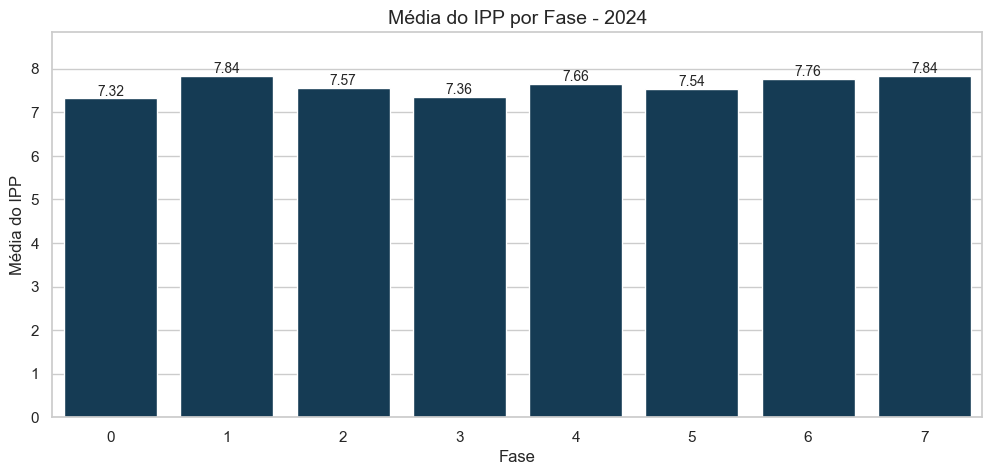

In [203]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\3194822360.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(


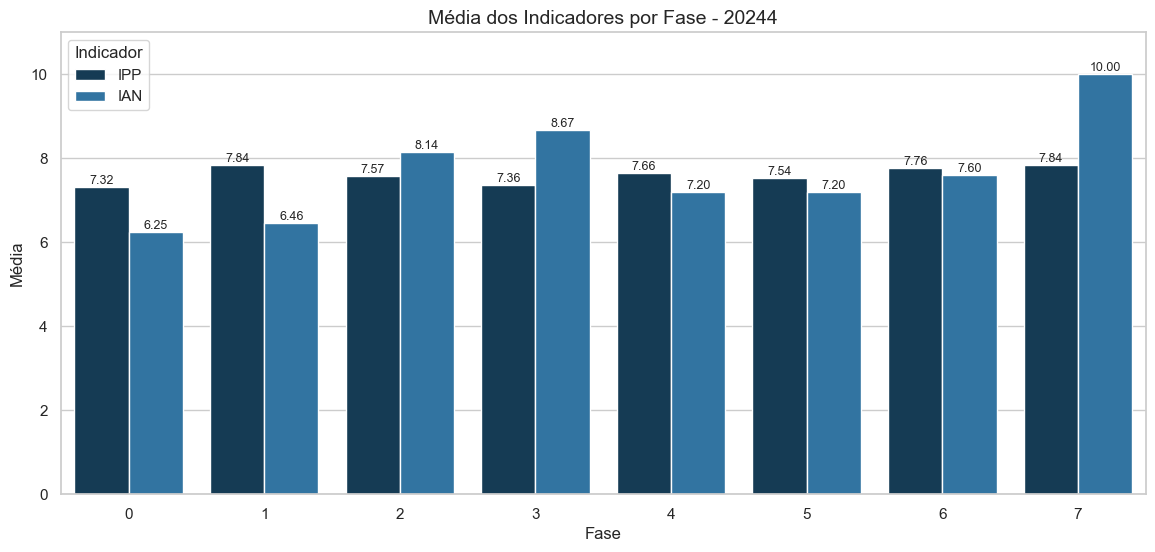

In [204]:
# Configuração de estilo
sns.set(style="whitegrid")

# Calcula média por fase
media_por_fase = (
    df_2024
    .groupby('Fase')[['IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Fase',
    value_vars=['IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(14,6))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Fase',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Fase - 20244", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()


In [205]:
df_2024[['IPP', 'IAN']].describe()

,IPP,IAN
count,1054.000000,1054.000000
mean,7.548303,7.459677
std,0.897219,2.511519
min,2.500000,2.500000
25%,7.187500,5.000000
50%,7.500000,5.000000
75%,8.125000,10.000000
max,10.000000,10.000000


In [206]:
#Correlação 
df_2024[['IPP', 'IAN']].corr()


#Correlação de Pearson
r_ian2, p_ian2 = pearsonr(df_2024['IPP'], df_2024['IAN'])

print("IPP x IAN -> r:", r_ian2, "p:", p_ian2)

IPP x IAN -> r: 0.15387343534851194 p: 5.179215507743388e-07


In [207]:
corr = df_2024[['IPP', 'IAN']].corr()

r_ipp_ian = corr.loc['IPP', 'IAN']

print("IAA x IDA - R²:", r_ipp_ian**2 *100)


IAA x IDA - R²: 2.3677034105952512


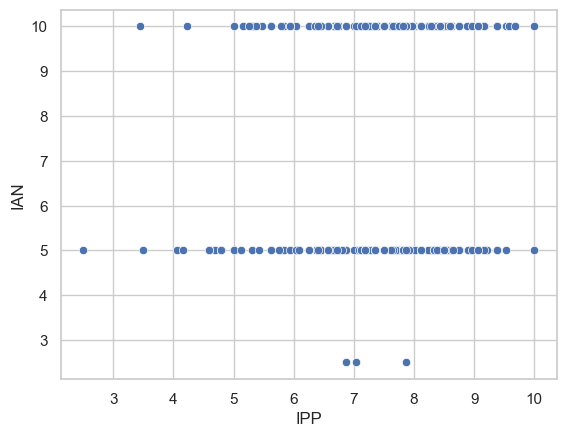

In [208]:
#Gráfico de dispersão

sns.scatterplot(x='IPP', y='IAN', data=df_2024)
plt.show()


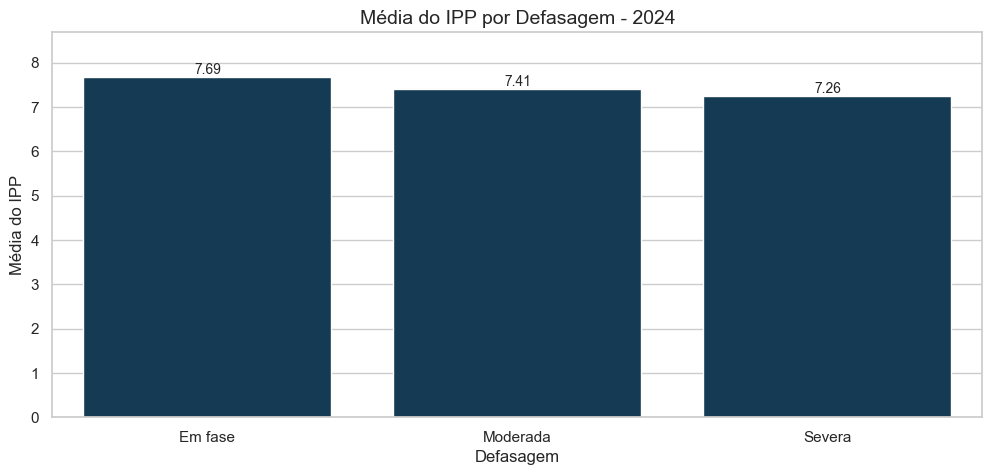

In [209]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Defasagem_Nome')['IPP'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do IPP por Defasagem - 2024", fontsize=14)
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Média do IPP', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

In [210]:
#Correlação
df_2024[['IDA', 'IEG', 'IAA', 'IPV']].corr()

,IDA,IEG,IAA,IPV
IDA,1.000000,0.547277,0.219653,0.513745
IEG,0.547277,1.000000,0.230092,0.535287
IAA,0.219653,0.230092,1.000000,0.148351
IPV,0.513745,0.535287,0.148351,1.000000


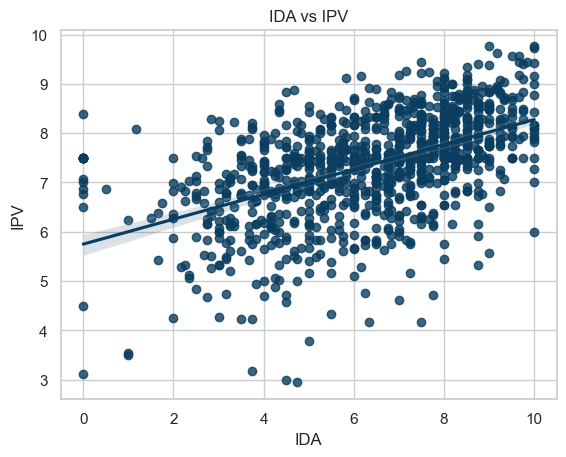

In [211]:
plt.figure()
sns.regplot(x='IDA', y='IPV', data=df_2024)
plt.title("IDA vs IPV")
plt.show()

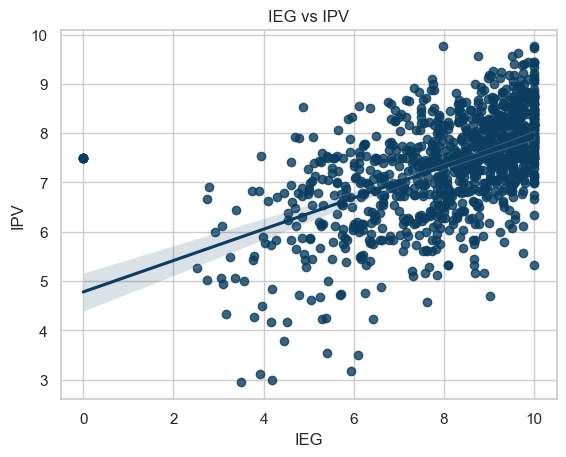

In [212]:
plt.figure()
sns.regplot(x='IEG', y='IPV', data=df_2024)
plt.title("IEG vs IPV")
plt.show()

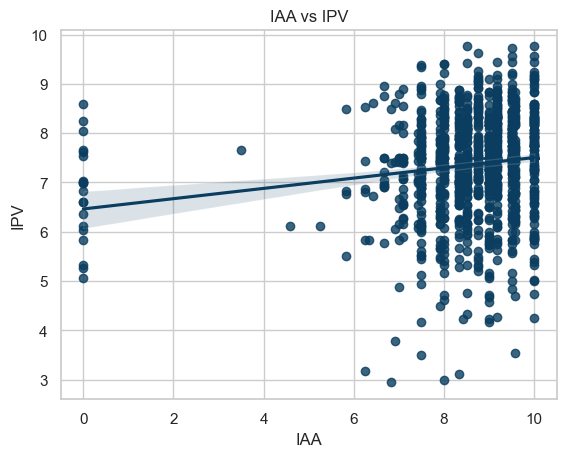

In [213]:
plt.figure()
sns.regplot(x='IAA', y='IPV', data=df_2024)
plt.title("IAA vs IPV")
plt.show()

In [214]:
df_2024 = df_2024.dropna(subset=['IPV'])

In [215]:
X = df_2024[['IDA', 'IEG', 'IAA']]
y = df_2024['IPV']

X = sm.add_constant(X)  # adiciona intercepto

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    IPV   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     193.6
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          6.34e-100
Time:                        21:32:14   Log-Likelihood:                -1313.0
No. Observations:                1054   AIC:                             2634.
Df Residuals:                    1050   BIC:                             2654.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6481      0.174     26.661      0.0

In [216]:
# supondo que df já tem as colunas
df_2024["contrib_IDA"] = 0.2 * df_2024["IDA"]
df_2024["contrib_IEG"] = 0.2 * df_2024["IEG"]
df_2024["contrib_IPS"] = 0.1 * df_2024["IPS"]
df_2024["contrib_IPP"] = 0.1 * df_2024["IPP"]

# soma da combinação analisada
df_2024["contrib_combinacao"] = (
    df_2024["contrib_IDA"] +
    df_2024["contrib_IEG"] +
    df_2024["contrib_IPS"] +
    df_2024["contrib_IPP"]

)

In [217]:
df_2024[["contrib_combinacao", "INDE 2024"]].corr()

,contrib_combinacao,INDE 2024
contrib_combinacao,1.000000,0.939797
INDE 2024,0.939797,1.000000


In [218]:
#Isso mostra o quanto essa combinação explica o INDE.

#Conceitualmente:

#IDA e IEG têm peso 0.2 → maior impacto estrutural

#IPS e IPP têm peso 0.1 → impacto moderado

#Então combinações com IDA e IEG altos naturalmente elevam mais o INDE.

In [219]:
df_2024["IDA_IEG"] = df_2024["IDA"] * df_2024["IEG"]
df_2024["IDA_IPS"] = df_2024["IDA"] * df_2024["IPS"]

In [220]:
df_2024[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]].describe()

,IDA,IEG,IPS,IPP,IDA_IEG,IDA_IPS
count,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000
mean,6.349858,8.088696,6.829670,7.548303,53.418311,43.411516
std,2.132045,1.763934,1.427893,0.897219,23.416164,17.212955
min,0.000000,0.000000,2.510000,2.500000,0.000000,0.000000
25%,4.875000,7.145337,6.260000,7.187500,34.814087,31.291667
50%,6.750000,8.592202,7.510000,7.500000,54.413095,45.060000
75%,8.000000,9.500000,7.510000,8.125000,72.046784,56.325000
max,10.000000,10.000000,10.000000,10.000000,100.000000,90.673333


In [221]:
print(df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]].isna().sum())
print(df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]].isin([np.inf, -np.inf]).sum())

IDA        0
IEG        0
IPS        6
IPP        0
IDA_IEG    0
IDA_IPS    6
dtype: int64
IDA        0
IEG        0
IPS        0
IPP        0
IDA_IEG    0
IDA_IPS    0
dtype: int64


In [222]:
X = df_2023[["IDA","IEG","IPS","IPP","IDA_IEG","IDA_IPS"]]
y = df_2023["INDE 2023"]

# Remove linhas onde X ou y tenham NaN
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask]
y_clean = y[mask]

X_clean = sm.add_constant(X_clean)
modelo = sm.OLS(y_clean, X_clean).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:              INDE 2023   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     429.5
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          3.09e-263
Time:                        21:32:15   Log-Likelihood:                -604.17
No. Observations:                 931   AIC:                             1222.
Df Residuals:                     924   BIC:                             1256.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4264      0.506      4.792      0.0

In [223]:
#Média do INDE 2024
df_2024['INDE 2024'].mean().round(2)

7.4

In [224]:
df_2024 = df_2024[df_2024['Fase'] != 8]

In [225]:
#Média do INDE por fase
media_por_fase = df_2024.groupby('Fase')['INDE 2024'].mean().round(2)
print(media_por_fase)

Fase
0     7.50212
1    7.564359
2    7.371663
3    7.106355
4     7.29642
5    7.474831
6     7.84337
7    7.579202
Name: INDE 2024, dtype: object


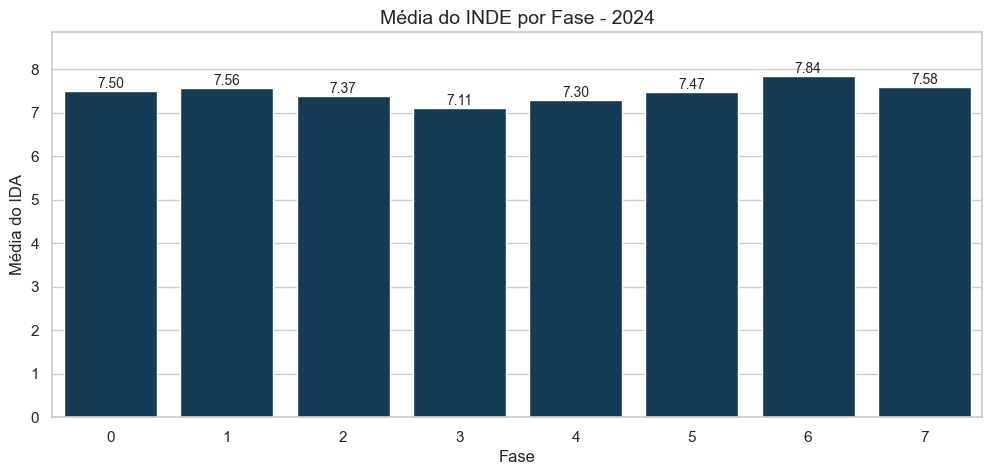

In [226]:
# Configurações de estilo
sns.set(style="whitegrid")
sns.set_palette(["#0A3D5F"])

# Calcula a média por fase
media_por_fase = df_2024.groupby('Fase')['INDE 2024'].mean().round(2)

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values)

# Título e labels
plt.title("Média do INDE por Fase - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
labels = [f'{v:.2f}' for v in media_por_fase.values]
ax.bar_label(ax.containers[0], labels=labels, fontsize=10)

plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\506042188.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores


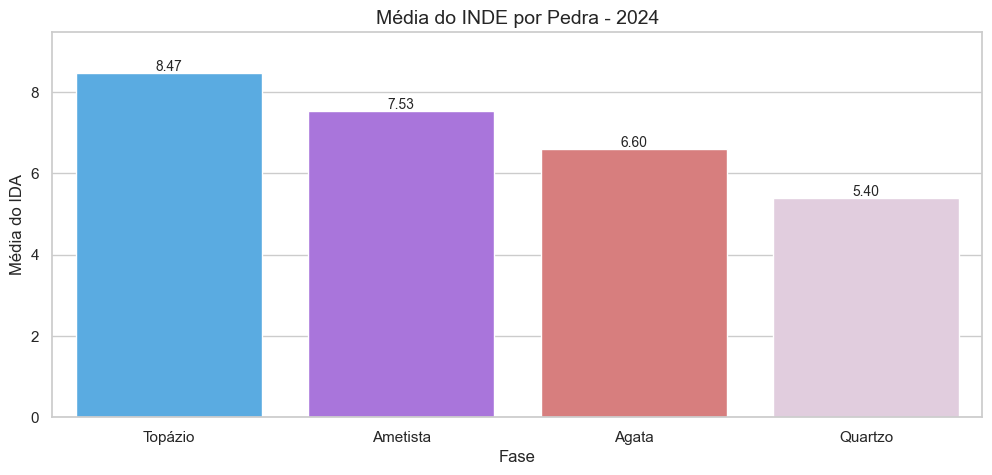

In [227]:
# Configurações de estilo
sns.set(style="whitegrid")

# Calcula a média por fase
media_por_fase = df_2024.groupby('Pedra 2024')['INDE 2024'].mean().round(2).sort_values(ascending=False)

cores_pedras = {
    "Ametista": "#AA64EC",   # roxo pastel
    "Quartzo": "#E4CAE0",    # rosa pastel
    "Topázio": "#43B0F8",    # azul pastel
    "Agata": "#E66F6F"       # vermelho pastel
}   

cores = [cores_pedras[pedra] for pedra in media_por_fase.index]

plt.figure(figsize=(12,5))

# Cria o gráfico com Seaborn
ax = sns.barplot(x=media_por_fase.index, y=media_por_fase.values, palette=cores
)

# Título e labels
plt.title("Média do INDE por Pedra - 2024", fontsize=14)
plt.xlabel('Fase', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)

# Ajusta limite do eixo y
ax.set_ylim(0, max(media_por_fase.values) + 1)

# Adiciona os valores no topo das barras
for i, v in enumerate(media_por_fase.values):
    ax.text(i, v + 0.05, f'{v:.2f}', 
            ha='center', fontsize=10)

plt.show()

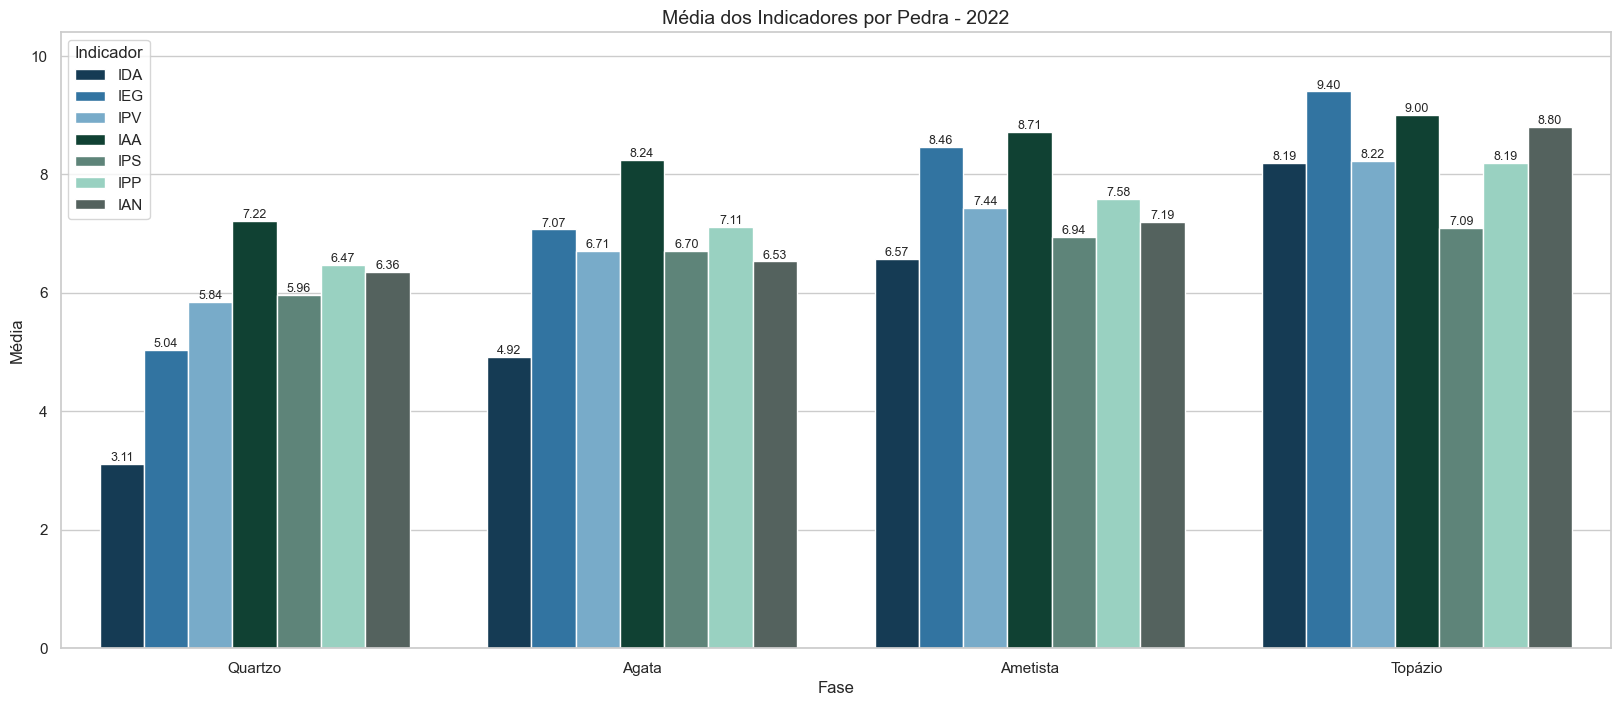

In [228]:
# Configuração de estilo


#ordem personalizada das pedras
ordem_pedras = ["Quartzo", "Agata", "Ametista", "Topázio"]

# Calcula média por pedra
media_por_fase = (
    df_2024
    .groupby('Pedra 2024')[['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN']]
    .mean()
    .round(2)
    .reset_index()
)

#Transforma em categórica com ordem definida
media_por_fase['Pedra 2024'] = pd.Categorical(
    media_por_fase['Pedra 2024'],
    categories=ordem_pedras,
    ordered=True
)

#Ordena pela ordem que você definiu
media_por_fase = media_por_fase.sort_values('Pedra 2024')

# Formato longo
media_long = media_por_fase.melt(
    id_vars='Pedra 2024',
    value_vars=['IDA', 'IEG', 'IPV', 'IAA', 'IPS', 'IPP', 'IAN'],
    var_name='Indicador',
    value_name='Média'
)

plt.figure(figsize=(20,8))

# Paleta em tons de azul
palette = ["#0A3D5F", "#1F77B4", "#6BAED6", "#084936", "#578B7C", "#90DAC5", "#52645F"]  # azul escuro → médio → claro

ax = sns.barplot(
    data=media_long,
    x='Pedra 2024',
    y='Média',
    hue='Indicador',
    palette=palette
)

plt.title("Média dos Indicadores por Pedra - 2022", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média")

plt.ylim(0, media_long['Média'].max() + 1)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title='Indicador')
plt.show()

Compilado

In [229]:
#Aqui comprova que as colunas mudam de nome ou só existem em um único ano
print(df_2022.columns)
print(df_2023.columns)
print(df_2024.columns)

Index(['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade',
       'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20',
       'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av',
       'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3',
       'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS',
       'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV',
       'IPV', 'IAN', 'Fase ideal', 'Defasagem', 'Destaque IEG', 'Destaque IDA',
       'Destaque IPV', 'Defasagem_Nome', 'grupo_ips_bin', 'IPP', 'contrib_IDA',
       'contrib_IEG', 'contrib_IPS', 'contrib_IPP', 'contrib_combinacao',
       'IDA_IEG', 'IDA_IPS'],
      dtype='object')
Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
     

In [230]:
print("Quantidade de Aluno por ano:")

qtd_22 = len(df_2022)
qtd_23 = len(df_2023)
qtd_24 = len(df_2024)

print(f"2022: {qtd_22} alunos")
print(f"2023: {qtd_23} alunos")
print(f"2024: {qtd_24} alunos")

# Crescimento absoluto
print("\nCrescimento absoluto:")
print(f"2022 → 2023: {qtd_23 - qtd_22} alunos")
print(f"2023 → 2024: {qtd_24 - qtd_23} alunos")

# Crescimento percentual
print("\nCrescimento percentual:")
print(f"2022 → 2023: {(qtd_23 - qtd_22)/qtd_22*100:.2f}%")
print(f"2023 → 2024: {(qtd_24 - qtd_23)/qtd_23*100:.2f}%")

Quantidade de Aluno por ano:
2022: 860 alunos
2023: 937 alunos
2024: 1054 alunos

Crescimento absoluto:
2022 → 2023: 77 alunos
2023 → 2024: 117 alunos

Crescimento percentual:
2022 → 2023: 8.95%
2023 → 2024: 12.49%


<span style="font-size:30px;">
Perguntas PDF
</span>

1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)


In [231]:
#Em 2022, tivemos 860 alunos no total, sendo a defasagem, 573 (66,6%) alunos em moderada, 259(30,1%) em fase e 28(3,3%) em severa 

2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos? 

In [232]:
#2022
#COLOCAR GRÁFICO DE LINHA
#2022 - já temos a resposta ao longo das fases 

3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [233]:
#2022
#A análise de correlação de Pearson indicou relação positiva moderada entre o grau de engajamento (IEG) e o indicador de desempenho (IDA) (r = 0,564; p < 0,001), bem como entre IEG e o indicador de ponto de virada (IPV) (r = 0,589; p < 0,001).
#Os valores de p inferiores a 0,001 indicam que as associações observadas são estatisticamente significativas, ou seja, a probabilidade de esses resultados ocorrerem ao acaso é extremamente baixa.
#Os resultados demonstram que maiores níveis de engajamento estão associados a melhores indicadores acadêmicos.

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)? 

In [234]:
#2022
#A autoavaliação (IAA) apresentou correlação positiva, porém fraca, com o engajamento (IEG) (r = 0,323; p < 0,001) e com o desempenho acadêmico (IDA) (r = 0,209; p < 0,001).
#Entretanto, a relação com o engajamento é mais forte do que com o desempenho. 
#Enquanto IAA e IEG compartilham aproximadamente 10% da variação (r² ≈ 0,10), IAA e IDA compartilham cerca de 4% (r² ≈ 0,04).
#Os resultados indicam que a percepção dos alunos sobre si mesmos está mais associada ao seu nível de envolvimento nas atividades do que ao seu desempenho acadêmico efetivo.

5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento? 

In [235]:
#2022
#A regressão linear indicou que estudantes classificados no grupo de atenção psicossocial 
# (IPS < 7,5) apresentam desempenho acadêmico significativamente inferior ao grupo regular (β = -0,394; p = 0,007). 
# Em média, o grupo de atenção apresenta aproximadamente 0,39 pontos a menos no IDA. Contudo, o modelo apresentou baixo poder explicativo (R² = 0,009), 
# indicando impacto prático reduzido.
#A regressão linear indicou que estudantes classificados no grupo de atenção psicossocial 
# (IPS < 7,5) apresentam nível de engajamento significativamente inferior ao grupo regular (β = -0,236; p = 0,043). 
# Em média, o grupo de atenção apresenta aproximadamente 0,24 pontos a menos no IEG. Contudo, o modelo apresentou baixo poder explicativo (R² = 0,005), 
# indicando impacto prático reduzido.
#A regressão linear indicou que estudantes classificados no grupo de atenção psicossocial 
# (IPS < 7,5) apresentam menor desempenho acadêmico (IDA) e menor engajamento (IEG) em comparação ao grupo regular. 
# A diferença foi de aproximadamente 0,39 pontos no IDA (p = 0,007; R² = 0,009) e 0,24 pontos no IEG (p = 0,043; R² = 0,005). 
# Embora estatisticamente significativas, as associações apresentam baixo poder explicativo, sugerindo impacto prático reduzido.

6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN? 

In [236]:
#2022
#Ao analisar as médias do IPP por nível de defasagem, observa-se que os valores são bastante próximos entre si: 6,50 para o grupo “Em fase”, 6,18 para “Moderada” e 6,47 para “Severa”.
#Não há um padrão progressivo que indique redução consistente do IPP à medida que a defasagem aumenta. 
#Esperar-se-ia que os grupos classificados com maior defasagem pelo IAN apresentassem médias significativamente inferiores no IPP, caso houvesse convergência entre os instrumentos.
#Entretanto, o grupo com defasagem severa apresenta média (6,47) semelhante à do grupo em fase (6,50), e superior à do grupo com defasagem moderada (6,18).
#Dessa forma, os resultados do IPP não confirmam de maneira consistente a defasagem identificada pelo IAN, 
# sugerindo possível divergência entre os instrumentos de avaliação ou a necessidade de análise complementar 
# (como testes estatísticos de significância) para verificar se as diferenças observadas são estatisticamente relevantes.

7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo? 

In [237]:
#2022
#A regressão linear múltipla indicou que IDA, IEG e IAA são preditores positivos e estatisticamente significativos do IPV (R² = 0,469; p < 0,001).
#Os coeficientes estimados mostram que aumentos em IDA (β = 0,221) e IEG (β = 0,224) estão associados a aumentos relevantes no IPV. 
# O IAA também apresentou efeito positivo e significativo (β = 0,032), porém com menor magnitude.
#Assim, os resultados confirmam que quanto maiores os níveis acadêmicos, de engajamento e emocionais, maior tende a ser o IPV, sendo IDA e IEG os principais fatores associados.

8. ⁠Multidimensionalidade dos indicadores - Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)? 

In [238]:
#2022
#Análise dos Indicadores e Impacto no INDE
#Foi estimado um modelo de regressão linear múltipla para avaliar o impacto conjunto de IDA, IEG, IPS e IPP sobre o INDE, incluindo termos de interação para testar possíveis efeitos combinados.
#O modelo apresentou R² = 0,886, indicando alto poder explicativo.
#Os coeficientes estimados mostram que:
#IEG (β = 0,2891) e IDA (β = 0,2882) possuem os maiores impactos sobre o INDE;
#IPS (β = 0,1841) e IPP (β = 0,1370) também apresentam efeito positivo e significativo, porém de menor magnitude.
#As interações testadas (IDA × IEG e IDA × IPS) não foram estatisticamente significativas (p > 0,05), indicando ausência de efeito sinérgico relevante.
#Assim, a elevação do INDE ocorre de forma linear e aditiva, sendo a combinação com maiores valores de IDA e IEG a que mais contribui para o aumento da nota global.

10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [239]:
#2022
#Sim, só preciso explicar isso no texto

[PENSAR EM ALGO] 11. Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos. 

[MODELO] 9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho 
ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem. ]


<span style="font-size:30px;">
Criação da Base Consolidada e Tratada para o Modelo
</span>

In [240]:
#Padronização

#2022
df_2022['PEDE_ANO'] = 2022
df_2022['INDE_ATUAL'] = df_2022['INDE 22']
df_2022['PEDRA_ATUAL'] = df_2022['Pedra 22']
df_2022 = df_2022.rename(columns={'Fase ideal': 'Fase Ideal'})
df_2022['Gênero'] = df_2022['Gênero'].replace({'Menina': 'Feminino', 'Menino': 'Masculino'})

#2023
df_2023['PEDE_ANO'] = 2023
df_2023['INDE_ATUAL'] = df_2023['INDE 2023']
df_2023 = df_2023.rename(columns={'Data de Nasc': 'Ano nasc'})
df_2023['PEDRA_ATUAL'] = df_2023['Pedra 2023']
df_2023['Ano nasc'] = pd.to_datetime(df_2023['Ano nasc'], errors='coerce').dt.year

#2024
df_2024['PEDE_ANO'] = 2024
df_2024['INDE_ATUAL'] = df_2024['INDE 2024']
df_2024 = df_2024.rename(columns={'Data de Nasc': 'Ano nasc'})
df_2024['PEDRA_ATUAL'] = df_2024['Pedra 2024']
df_2024['Ano nasc'] = pd.to_datetime(df_2024['Ano nasc'], errors='coerce').dt.year



#Junta tudo em uma tabela só
df_unificada = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

#Garante que INDE é número (corrige textos 'INCLUIR' que dão erro)
df_unificada['INDE_ATUAL'] = pd.to_numeric(df_unificada['INDE_ATUAL'], errors='coerce')

#Ordenação
if 'RA' in df_unificada.columns:
    df_unificada = df_unificada.sort_values(by=['RA', 'PEDE_ANO'])

In [241]:
pd.set_option('display.max_columns', None)

In [242]:
df_unificada.head(10)

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Defasagem_Nome,grupo_ips_bin,IPP,contrib_IDA,contrib_IEG,contrib_IPS,contrib_IPP,contrib_combinacao,IDA_IEG,IDA_IPS,PEDE_ANO,INDE_ATUAL,PEDRA_ATUAL,INDE 2023,Pedra 2023,Pedra 23,INDE 23,Destaque IPV.1,INDE 2024,Pedra 2024,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,753.0,18.0,10.0,4.0,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.300,4.100000,5.60,Requer avaliação,4.00,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Moderada,1,8.174000,0.80,0.820000,0.560,0.817400,2.997400,16.400000,22.4000,2022,5.783000,Quartzo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,RA-10,7,A,Aluno-10,2004,18,Feminino,2021,Escola Pública,NaN,Ágata,Quartzo,5.784,752.0,17.0,9.0,4.0,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.300,5.200000,5.00,Requer avaliação,4.10,3.3,2.6,6.4,Não,Não,7.056,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,Moderada,1,6.828000,0.82,1.040000,0.500,0.682800,3.042800,21.320000,20.5000,2022,5.784000,Quartzo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,RA-100,4,A,Aluno-100,2009,13,Feminino,2019,Rede Decisão,Ametista,Topázio,Ametista,7.618,268.0,22.0,7.0,4.0,Avaliador-6,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-30,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.800,7.800000,5.00,Não indicado,7.60,7.0,7.8,8.1,Não,Não,7.250,10.0,Fase 3 (7º e 8º ano),1,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Melhorar: Integrar-se mais aos Princípios Pass...,Em fase,1,7.080000,1.52,1.560000,0.500,0.708000,4.288000,59.280000,38.0000,2022,7.618000,Ametista,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1072,RA-1000,ALFA,ALFA U - G2/G3,Aluno-1000,2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-13,NaN,Avaliador-3,NaN,NaN,NaN,NaN,NaN,8.500,9.400000,3.77,NaN,7.00,7.0,7.0,NaN,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,Em fase,1,6.250000,1.40,1.880000,0.377,0.625000,4.282000,65.800000,26.3900,2023,7.916200,Ametista,7.9162,Ametista,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2148,RA-1000,1,1N,Aluno-1000,2015,9,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-15,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.002,9.545455,6.26,NaN,7.75,7.5,8.0,NaN,NaN,NaN,7.835,10.0,Fase 1 (3° e 4° ano),0,NaN,NaN,NaN,Em fase,1,8.125000,1.55,1.909091,0.626,0.812500,4.897591,73.977273,48.5150,2024,8.364791,Topázio,NaN,NaN,Ametista,7.9162,NaN,8.364791,Topázio,NaN,NaN,EE Helio Luiz Dobrochinski Prof,Cursando,Cursando
1074,RA-1001,ALFA,ALFA U - G2/G3,Aluno-1001,2014,9,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-13,NaN,Avaliador-3,NaN,NaN,NaN,NaN,NaN,9.000,9.100000,7.52,NaN,7.80,8.3,7.3,NaN,NaN,NaN,9.170,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,Moderada,0,7.500000,1.56,1.820000,0.752,0.750000,4.882000,70.980000,58.6560,2023,8.116200,Topázio,8.1162,Topázio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2150,RA-1001,1,1N,Aluno-1001,2014,10,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,Avaliador-15,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,7.502,9.347826,7.51,NaN,7.75,6.5,9.0,NaN,NaN,NaN,7.920,5.0,Fase 2 (5° e 6° ano),-1,NaN,NaN,N

In [243]:
df_unificada.shape

(2851, 67)

In [244]:
df_unificada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2851 entries, 0 to 1068
Data columns (total 67 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     2851 non-null   object 
 1   Fase                   2851 non-null   object 
 2   Turma                  2851 non-null   object 
 3   Nome Anonimizado       2851 non-null   object 
 4   Ano nasc               2851 non-null   int64  
 5   Idade                  2851 non-null   object 
 6   Gênero                 2851 non-null   object 
 7   Ano ingresso           2851 non-null   int64  
 8   Instituição de ensino  2850 non-null   object 
 9   Pedra 20               726 non-null    object 
 10  Pedra 21               1024 non-null   object 
 11  Pedra 22               1879 non-null   object 
 12  INDE 22                1879 non-null   float64
 13  Cg                     860 non-null    float64
 14  Cf                     860 non-null    float64
 15  Ct       

In [245]:
pd.set_option('display.max_rows', None)

In [246]:
#Ver quantos vazios tem em cada coluna
df_unificada.isna().sum()

RA                          0
Fase                        0
Turma                       0
Nome Anonimizado            0
Ano nasc                    0
Idade                       0
Gênero                      0
Ano ingresso                0
Instituição de ensino       1
Pedra 20                 2125
Pedra 21                 1827
Pedra 22                  972
INDE 22                   972
Cg                       1991
Cf                       1991
Ct                       1991
Nº Av                       0
Avaliador1                 25
Rec Av1                  1991
Avaliador2                 25
Rec Av2                  1991
Avaliador3                818
Rec Av3                  1991
Avaliador4               1800
Rec Av4                  2555
IAA                         0
IEG                         0
IPS                         6
Rec Psicologia           1991
IDA                         0
Mat                         6
Por                         7
Ing                      1761
Indicado  

In [247]:
#Montar um df exclusivo para realizar as analises, escolhendo apenas colunas que vou utilizar 

colunas = ['RA', 'Fase', 'Turma', 'Nome Anonimizado', 'Ano nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'IAA',
            'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', 'Defasagem_Nome', 'grupo_ips_bin', 'IPP', 'IDA_IEG',  'IDA_IPS', 'PEDE_ANO',
             'INDE_ATUAL', 'PEDRA_ATUAL' ]

df = df_unificada[colunas]

In [248]:
df.shape

(2851, 25)

In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2851 entries, 0 to 1068
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     2851 non-null   object 
 1   Fase                   2851 non-null   object 
 2   Turma                  2851 non-null   object 
 3   Nome Anonimizado       2851 non-null   object 
 4   Ano nasc               2851 non-null   int64  
 5   Idade                  2851 non-null   object 
 6   Gênero                 2851 non-null   object 
 7   Ano ingresso           2851 non-null   int64  
 8   Instituição de ensino  2850 non-null   object 
 9   IAA                    2851 non-null   float64
 10  IEG                    2851 non-null   float64
 11  IPS                    2845 non-null   float64
 12  IDA                    2851 non-null   float64
 13  IPV                    2851 non-null   float64
 14  IAN                    2851 non-null   float64
 15  Fase Idea

In [250]:
df.isna().sum()

RA                       0
Fase                     0
Turma                    0
Nome Anonimizado         0
Ano nasc                 0
Idade                    0
Gênero                   0
Ano ingresso             0
Instituição de ensino    1
IAA                      0
IEG                      0
IPS                      6
IDA                      0
IPV                      0
IAN                      0
Fase Ideal               0
Defasagem                0
Defasagem_Nome           0
grupo_ips_bin            0
IPP                      0
IDA_IEG                  0
IDA_IPS                  6
PEDE_ANO                 0
INDE_ATUAL               6
PEDRA_ATUAL              6
dtype: int64

In [251]:
#remover os casos que tenham vazios
df = df.dropna()

In [252]:
#Excluindo as linhas duplicando considerando como critério de ano, ou seja, considera a linha mais atual
df = df.sort_values('PEDE_ANO')
df = df.drop_duplicates(subset='RA', keep='last')

In [253]:
df.head(10)

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,IAA,IEG,IPS,IDA,IPV,IAN,Fase Ideal,Defasagem,Defasagem_Nome,grupo_ips_bin,IPP,IDA_IEG,IDA_IPS,PEDE_ANO,INDE_ATUAL,PEDRA_ATUAL
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,8.3,4.1,5.6,4.0,7.278,5.0,Fase 8 (Universitários),-1,Moderada,1,8.174,16.40,22.40,2022,5.783,Quartzo
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,8.8,4.5,5.6,5.0,5.278,10.0,Fase 7 (3º EM),0,Em fase,1,5.554,22.50,28.00,2022,5.951,Quartzo
395,RA-396,2,J,Aluno-396,2010,12,Masculino,2022,Escola Pública,9.0,8.0,6.3,5.6,6.556,5.0,Fase 3 (7º e 8º ano),-1,Moderada,1,4.948,44.80,35.28,2022,6.556,Ágata
393,RA-394,2,J,Aluno-394,2011,11,Feminino,2022,Escola Pública,9.5,8.6,7.5,5.9,8.444,10.0,Fase 2 (5º e 6º ano),0,Em fase,0,6.082,50.74,44.25,2022,7.897,Ametista
392,RA-393,2,J,Aluno-393,2006,16,Feminino,2018,Escola Pública,10.0,5.4,5.0,4.6,6.778,2.5,Fase 6 (2º EM),-4,Severa,1,4.124,24.84,23.00,2022,5.518,Quartzo
384,RA-385,2,I,Aluno-385,2010,12,Feminino,2022,Escola Pública,7.4,7.5,5.0,4.9,6.500,5.0,Fase 3 (7º e 8º ano),-1,Moderada,1,5.630,36.75,24.50,2022,6.083,Ágata
40,RA-41,5,A,Aluno-41,2005,17,Masculino,2018,Escola Pública,9.2,6.1,5.0,5.6,4.375,5.0,Fase 7 (3º EM),-2,Moderada,1,4.460,34.16,28.00,2022,5.581,Quartzo
405,RA-406,2,K,Aluno-406,2009,13,Feminino,2019,Escola Pública,9.5,9.5,7.5,6.6,7.333,5.0,Fase 3 (7º e 8º ano),-1,Moderada,0,6.094,62.70,49.50,2022,7.496,Ametista
404,RA-405,2,K,Aluno-405,2009,13,Masculino,2016,Escola Pública,9.5,6.2,5.0,3.3,6.000,5.0,Fase 3 (7º e 8º ano),-1,Moderada,1,6.110,20.46,16.50,2022,5.661,Quartzo
354,RA-355,2,D,Aluno-355,2010,12,Feminino,2018,Escola Pública,5.8,5.0,7.5,4.5,6.056,5.0,Fase 3 (7º e 8º ano),-1,Moderada,0,4.378,22.50,33.75,2022,5.379,Quartzo


In [254]:
df['Defasagem'].unique()

array([-1,  0, -4, -2, -3, -5,  1,  2,  3], dtype=int64)

In [255]:
#Analise Estatística
df.describe()

,Ano nasc,Ano ingresso,IAA,IEG,IPS,IDA,IPV,IAN,Defasagem,grupo_ips_bin,IPP,IDA_IEG,IDA_IPS,PEDE_ANO,INDE_ATUAL
count,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000,1585.000000
mean,2010.902839,2022.134385,8.126202,7.928407,6.573399,6.144869,7.345318,7.110410,-0.648580,0.435962,7.320221,50.812638,40.495502,2023.488328,7.196247
std,3.070616,1.603810,2.271631,1.748320,1.631216,2.120063,1.097065,2.536436,0.879501,0.496039,1.067074,23.031229,17.701940,0.776076,1.067314
min,2001.000000,2016.000000,0.000000,0.000000,2.510000,0.000000,2.500000,2.500000,-5.000000,0.000000,-0.074000,0.000000,0.000000,2022.000000,3.633000
25%,2009.000000,2021.000000,7.917000,6.900000,6.255000,4.666667,6.773333,5.000000,-1.000000,0.000000,6.875000,32.640000,27.144000,2023.000000,6.575000
50%,2011.000000,2022.000000,8.751000,8.361426,7.500000,6.400000,7.500000,5.000000,-1.000000,0.000000,7.500000,50.851229,40.690000,2024.000000,7.335500
75%,2013.000000,2023.000000,9.500000,9.306418,7.510000,7.800000,8.085000,10.000000,0.000000,1.000000,8.000000,69.399586,54.447500,2024.000000,7.982891
max,2017.000000,2024.000000,10.002000,10.000000,10.000000,10.000000,10.010000,10.000000,3.000000,1.000000,10.000000,100.000000,90.673333,2024.000000,9.531325


In [256]:
#Padronizar a fase
df['Fase'].unique()

array([7, 2, 5, 6, 1, 3, 4, 0, 'FASE 1', 'FASE 6', 'FASE 5', 'ALFA',
       'FASE 2', 'FASE 3', 'FASE 7', 'FASE 4'], dtype=object)

In [257]:
df['Fase'] = (
    df['Fase']
    .astype(str)              # garante que tudo vira string
    .str.upper()              # padroniza
    .str.replace('FASE ', '') # remove "FASE "
    .replace('ALFA', '0')     # ALFA vira 0
)

df['Fase'] = df['Fase'].astype(int)

In [258]:
#mudar o formato para trazer apenas um número
df['INDE_ATUAL'] = df['INDE_ATUAL'].map('{:.1f}'.format)

In [259]:
#Tipos de instituição de ensino
df['Instituição de ensino'].unique()

array(['Escola Pública', 'Rede Decisão', 'Escola JP II', 'Pública',
       'Privada', 'Privada - Programa de Apadrinhamento',
       'Concluiu o 3º EM', 'Nenhuma das opções acima',
       'Privada *Parcerias com Bolsa 100%'], dtype=object)

In [260]:
mapa = {
    'Pública': 'Pública',
    'Escola Pública': 'Pública',
    'Privada - Programa de Apadrinhamento': 'Privada',
    'Privada *Parcerias com Bolsa 100%': 'Privada',
    'Privada': 'Privada',
    'Rede Decisão': 'Privada',
    'Concluiu o 3º EM':'Sem Classificação',
    'Nenhuma das opções acima': 'Sem Classificação',
    'Escola JP II': 'Sem Classificação'
}

df['Instituição de ensino_padronizada'] = (
    df['Instituição de ensino'].replace(mapa)
)

df['Instituição de ensino_padronizada'].value_counts()


Instituição de ensino_padronizada
Pública              1396
Privada               177
Sem Classificação      12
Name: count, dtype: int64

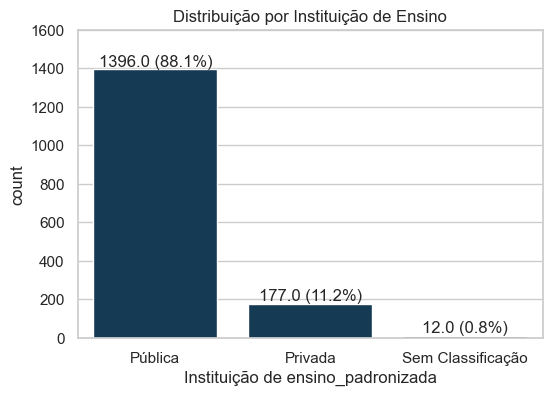

In [261]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(6,4)) 
ax = sns.countplot(x='Instituição de ensino_padronizada', data=df) 
plt.title("Distribuição por Instituição de Ensino") 
ax.set_ylim(0, 1600)
total = len(df) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()


<span style="font-size:30px;">
INDE - Indice do Desenvolvimento Educacional – Metrica de Processo Avaliativo Geral do Aluno
</span>




Dado pela Ponderaçao dos indicadores: IAN, IDA, IEG, IAA, IPS, IPP e IPV

In [262]:
#IAA - Indicador de Autoavaliação – Media das Notas de Auto Avaliação do Aluno 
#IEG - Indicador de Engajamento – Media das Notas de Engajamento do Aluno
#IPS - Indicador Psicossocial – Media das Notas Psicossociais do Aluno
#IDA - Indicador de Aprendizagem - Media das Notas do Indicador de Aprendizagem
#IPP - Indicador Psicopedagógico – Media das Notas Psico Pedagógicas do Aluno 
#IPV - Indicador de Ponto de Virada – Media das Notas de Ponto de Virada do Aluno 
#IAN - Indicador de Adequação ao Nível – Media das Notas de Adequação do Aluno ao nível atual 

<span style="font-size:30px;">
Classificaçao do Aluno baseado no numero do INDE, o conceito de classificação e dado por:
</span>

In [263]:
#Quartzo – 2,405 a 5,506 - #FFC0CB (rosa claro)
#Agata – 5,506 a 6,868 - #A52A2A (marrom, uma das cores comuns)
#Ametista – 6,868 a 8,230 - #9966CC (roxo)
#Topazio – 8,230 a 9,294 - #007FFF (azul)

In [264]:
df['PEDRA_ATUAL'].unique()

array(['Quartzo', 'Ágata', 'Ametista', 'Topázio', 'Agata'], dtype=object)

In [265]:
mapa = {
    'Ametista': 'Ametista',
    'Agata': 'Ágata',
    'Topázio': 'Topázio',
    'Ágata': 'Ágata',
    'Quartzo': 'Quartzo'
}

df['Pedra_Atual_Padronizada'] = (
    df['PEDRA_ATUAL'].replace(mapa)
)

df['Pedra_Atual_Padronizada'].value_counts()

Pedra_Atual_Padronizada
Ametista    562
Ágata       408
Topázio     390
Quartzo     225
Name: count, dtype: int64

In [266]:
df['Pedra_Atual_Padronizada'].unique()

array(['Quartzo', 'Ágata', 'Ametista', 'Topázio'], dtype=object)

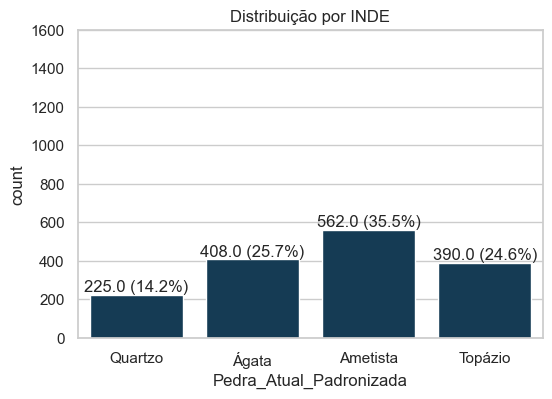

In [267]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(6,4)) 
ax = sns.countplot(x='Pedra_Atual_Padronizada', data=df) 
plt.title("Distribuição por INDE") 
ax.set_ylim(0, 1600)
total = len(df) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()

In [268]:
df['Gênero'].value_counts()

Gênero
Feminino     854
Masculino    731
Name: count, dtype: int64

In [269]:
#alunos por fase
df['Fase'].value_counts()

Fase
3    312
0    294
2    273
1    270
4    165
5    146
7     67
6     58
Name: count, dtype: int64

In [270]:
#Contagem dos valores de defasagem
mapa = {
    2.5: 'Severa',
    5: 'Moderada',
    10: 'Em fase'
   
}

df['Defasagem_Nome'] = (
    df['IAN'].replace(mapa)
)

df['Defasagem_Nome'].value_counts()

Defasagem_Nome
Moderada    874
Em fase     683
Severa       28
Name: count, dtype: int64

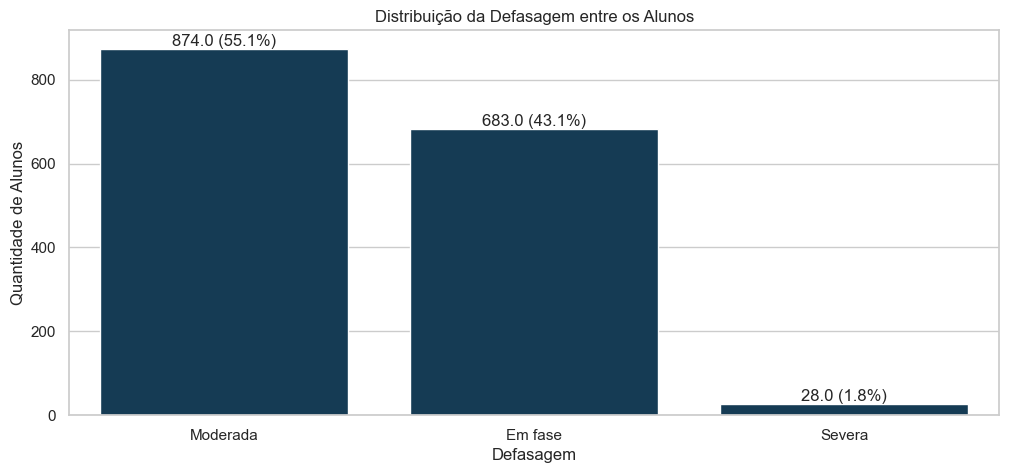

In [271]:
sns.set(style="whitegrid") 
sns.set_palette(["#0A3D5F"]) 

plt.figure(figsize=(12,5)) 

ax = sns.countplot(x='Defasagem_Nome', data=df) 

plt.title("Distribuição da Defasagem entre os Alunos") 
plt.xlabel('Defasagem', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)

total = len(df) 
labels = [ f'{p.get_height()} ({(p.get_height()/total)*100:.1f}%)' for p in ax.patches ] 
ax.bar_label(ax.containers[0], labels=labels) 
plt.show()

In [272]:
#Média do IDA 
df['IDA'].mean().round(2)

6.14

In [273]:
#Média do IEG
df['IEG'].mean().round(2)

7.93

In [274]:
#Média do IPV
df['IPV'].mean().round(2)

7.35

In [275]:
df.head()

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,IAA,IEG,IPS,IDA,IPV,IAN,Fase Ideal,Defasagem,Defasagem_Nome,grupo_ips_bin,IPP,IDA_IEG,IDA_IPS,PEDE_ANO,INDE_ATUAL,PEDRA_ATUAL,Instituição de ensino_padronizada,Pedra_Atual_Padronizada
0,RA-1,7,A,Aluno-1,2003,19,Feminino,2016,Escola Pública,8.3,4.1,5.6,4.0,7.278,5.0,Fase 8 (Universitários),-1,Moderada,1,8.174,16.40,22.40,2022,5.8,Quartzo,Pública,Quartzo
3,RA-4,7,A,Aluno-4,2005,17,Masculino,2017,Rede Decisão,8.8,4.5,5.6,5.0,5.278,10.0,Fase 7 (3º EM),0,Em fase,1,5.554,22.50,28.00,2022,6.0,Quartzo,Privada,Quartzo
395,RA-396,2,J,Aluno-396,2010,12,Masculino,2022,Escola Pública,9.0,8.0,6.3,5.6,6.556,5.0,Fase 3 (7º e 8º ano),-1,Moderada,1,4.948,44.80,35.28,2022,6.6,Ágata,Pública,Ágata
393,RA-394,2,J,Aluno-394,2011,11,Feminino,2022,Escola Pública,9.5,8.6,7.5,5.9,8.444,10.0,Fase 2 (5º e 6º ano),0,Em fase,0,6.082,50.74,44.25,2022,7.9,Ametista,Pública,Ametista
392,RA-393,2,J,Aluno-393,2006,16,Feminino,2018,Escola Pública,10.0,5.4,5.0,4.6,6.778,2.5,Fase 6 (2º EM),-4,Severa,1,4.124,24.84,23.00,2022,5.5,Quartzo,Pública,Quartzo


In [276]:
df["Instituicao_bin"] = df["Instituição de ensino_padronizada"].map({
    "Pública": 0,
    "Privada": 1,
    "Sem Classificação": 2
})

In [277]:
df["Genero_bin"] = df["Gênero"].map({
    "Feminino": 0,
    "Masculino": 1
})

In [278]:
df['INDE_ATUAL'] = df['INDE_ATUAL'].astype(float)

In [279]:
df["risco"] = ((df["IAN"] < 7) | (df["INDE_ATUAL"] < 7)).astype(int)

In [280]:
df["risco"].value_counts()

risco
1    1048
0     537
Name: count, dtype: int64

In [281]:
features = [
    "IAA",
    "IEG",
    "IPS",
    "IDA",
    "IPV",
    "IPP",
    "Idade",
    "Instituicao_bin",
    "Ano ingresso",
    "Genero_bin"
    
]

In [282]:
X = df[features]
y = df["risco"]

In [283]:
#ajuste para deixar tudo como dia

import datetime

def corrigir_idade(x):
    if isinstance(x, datetime.datetime):
        return x.day
    return x

X["Idade"] = X["Idade"].apply(corrigir_idade)
X["Idade"] = pd.to_numeric(X["Idade"])

C:\Users\camil\AppData\Local\Temp\ipykernel_7852\2215786187.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Idade"] = X["Idade"].apply(corrigir_idade)
C:\Users\camil\AppData\Local\Temp\ipykernel_7852\2215786187.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Idade"] = pd.to_numeric(X["Idade"])


In [284]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [285]:
X_train.dtypes

IAA                float64
IEG                float64
IPS                float64
IDA                float64
IPV                float64
IPP                float64
Idade                int64
Instituicao_bin      int64
Ano ingresso         int64
Genero_bin           int64
dtype: object

In [286]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [287]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Acurácia Random Forest: 0.7584033613445378
              precision    recall  f1-score   support

           0       0.73      0.46      0.56       161
           1       0.77      0.91      0.83       315

    accuracy                           0.76       476
   macro avg       0.75      0.69      0.70       476
weighted avg       0.75      0.76      0.74       476



In [288]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Acurácia XGBoost:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Acurácia XGBoost: 0.7773109243697479
              precision    recall  f1-score   support

           0       0.74      0.53      0.62       161
           1       0.79      0.90      0.84       315

    accuracy                           0.78       476
   macro avg       0.76      0.72      0.73       476
weighted avg       0.77      0.78      0.77       476



In [289]:
import pandas as pd

importances = xgb_model.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print(feat_importance)

Instituicao_bin    0.201899
IEG                0.150247
Ano ingresso       0.112689
Idade              0.108575
IDA                0.090080
IPS                0.083838
IPV                0.081771
IPP                0.081364
IAA                0.063888
Genero_bin         0.025649
dtype: float32


In [290]:
proba_risco = xgb_model.predict_proba(X_test)

In [291]:
proba_risco = xgb_model.predict_proba(X_test)[:,1]

In [292]:
resultado = X_test.copy()
resultado["risco_real"] = y_test
resultado["prob_risco"] = proba_risco

resultado.sort_values("prob_risco", ascending=False).head(10)

,IAA,IEG,IPS,IDA,IPV,IPP,Idade,Instituicao_bin,Ano ingresso,Genero_bin,risco_real,prob_risco
1682,0.000,4.800000,2.52,3.900000,5.3750,4.21875,18,0,2022,0,1,0.999970
213,0.000,6.100000,7.50,4.300000,5.1250,5.15000,15,0,2022,1,1,0.999878
76,7.100,2.700000,5.00,0.700000,4.6250,5.31000,16,0,2019,1,1,0.999878
231,0.000,4.900000,7.50,0.000000,4.5420,6.06600,12,0,2022,1,1,0.999873
1721,0.000,7.700000,2.52,2.600000,5.6275,5.62500,19,0,2022,1,1,0.999858
262,5.800,5.600000,7.50,3.700000,4.4170,7.45600,15,0,2019,0,1,0.999848
208,0.000,4.800000,5.60,6.000000,3.7500,5.29000,14,0,2019,1,1,0.999826
1706,5.800,7.300000,2.52,2.900000,5.5900,4.37500,17,2,2019,0,1,0.999811
287,0.000,5.600000,6.30,0.000000,6.8330,7.30400,16,0,2022,0,1,0.999751
2533,4.584,4.707018,2.51,3.333333,6.1175,6.87500,13,0,2021,0,1,0.999714


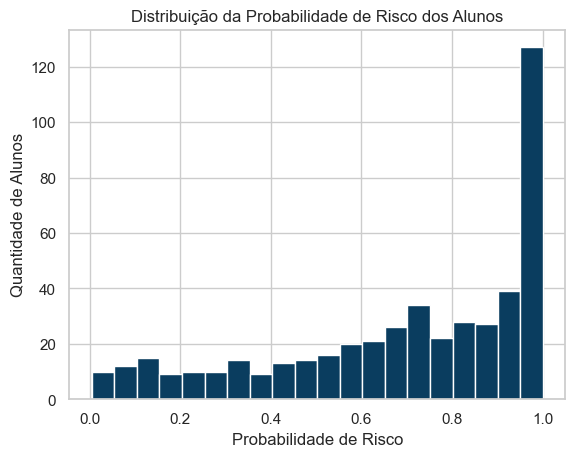

In [293]:
import matplotlib.pyplot as plt

plt.hist(proba_risco, bins=20)
plt.xlabel("Probabilidade de Risco")
plt.ylabel("Quantidade de Alunos")
plt.title("Distribuição da Probabilidade de Risco dos Alunos")

plt.show()

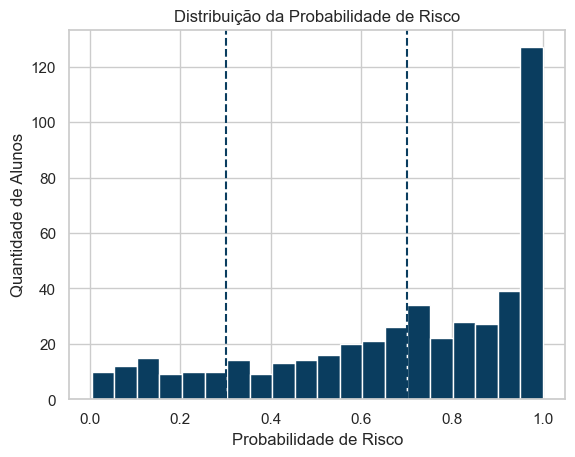

In [294]:
plt.hist(proba_risco, bins=20)

plt.axvline(0.3, linestyle="--")
plt.axvline(0.7, linestyle="--")

plt.xlabel("Probabilidade de Risco")
plt.ylabel("Quantidade de Alunos")
plt.title("Distribuição da Probabilidade de Risco")

plt.show()

In [295]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [297]:
fpr, tpr, thresholds = roc_curve(y_test, proba_risco)
auc = roc_auc_score(y_test, proba_risco)

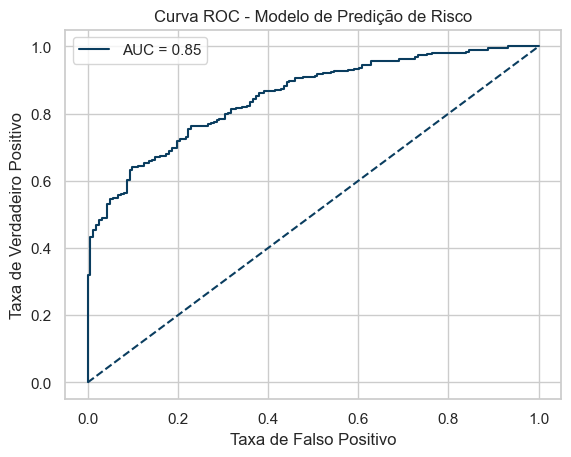

In [298]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.title("Curva ROC - Modelo de Predição de Risco")

plt.legend()
plt.show()

In [299]:
pd.Series(y_pred_xgb).value_counts()

1    361
0    115
Name: count, dtype: int64

In [300]:
pd.Series(y_pred_rf).value_counts()

1    374
0    102
Name: count, dtype: int64

In [301]:
pd.Series(y_test).value_counts()

risco
1    315
0    161
Name: count, dtype: int64

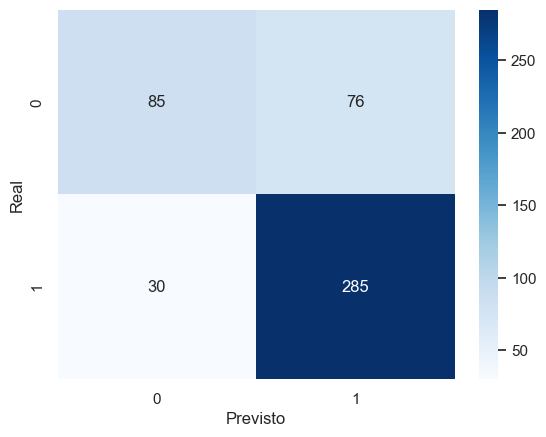

In [307]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [311]:
import joblib
import os

# 1. Este é o caminho que você já criou no seu computador
caminho_local = r"C:\Users\camil\OneDrive\Área de Trabalho\Pessoal\Pós Graduação\Fase 5\github\model\modelo_risco.pkl"

# 2. Salvando o modelo no seu computador
joblib.dump(xgb_model, caminho_local)

print(f"Modelo salvo com sucesso em: {caminho_local}")

Modelo salvo com sucesso em: C:\Users\camil\OneDrive\Área de Trabalho\Pessoal\Pós Graduação\Fase 5\github\model\modelo_risco.pkl
